# Dynamic Visualization (beta)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
# import matplotlib.gridspec as gridspec
# from matplotlib.patches import FancyBboxPatch
# import torch
# import torchvision
# import torchvision.transforms as transforms
# from torch.utils.data import DataLoader
# import base64
# from IPython.display import HTML, display

# class EquilibriumMatchingAnimation:
#     def __init__(self, model=None, config=None, n_particles=15, steps=50):
#         """
#         Animate EqM vs FM visualization with real model dynamics
#         """
#         self.model = model  # Trained EqM model (optional)
#         self.config = config
#         self.n_particles = n_particles
#         self.steps = steps

#         # Setup figure with GridSpec to prevent overlap
#         self.fig = plt.figure(figsize=(15, 8), facecolor='white')  # Taller figure
#         gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[3, 1],
#                                wspace=0.25, hspace=0.4, top=0.92, bottom=0.08)

#         # Left panel: 2D dynamics (spans both rows)
#         self.ax1 = self.fig.add_subplot(gs[:, 0])

#         # Right panels: Main image (top) and evolution grid (bottom)
#         self.ax2_main = self.fig.add_subplot(gs[0, 1])  # Main evolution image
#         self.ax2_grid = self.fig.add_subplot(gs[1, 1])  # Grid of snapshots

#         # Ground truth points and landscape
#         self.gt_points = np.array([[-1., 0.], [1., 0.]])
#         self.sigma = 0.6

#         # Initialize particles
#         self._init_particles()

#         # Load MNIST for right panel
#         self._load_mnist_data()

#         # Create static elements
#         self._create_static_elements()

#         # Store colors for consistent particle coloring
#         self.colors = plt.cm.viridis(np.linspace(0, 1, self.n_particles))

#     def _init_particles(self):
#         """Initialize particles for both methods"""
#         # Random starting positions (noise)
#         self.starts = np.random.uniform(-2.5, 2.5, size=(self.n_particles, 2))
#         self.starts[self.starts[:, 0] > 0, 0] = 1.5  # Separate initial clusters

#         # Create copies for each method
#         self.particles_eqm = self.starts.copy()
#         self.particles_fm = self.starts.copy()

#         # Store trajectories
#         self.traj_eqm = [self.particles_eqm.copy()]
#         self.traj_fm = [self.particles_fm.copy()]

#         # Initialize scatter plot handles
#         self.particles_eqm_scat = None
#         self.particles_fm_scat = None

#     def _load_mnist_data(self):
#         """Load real MNIST digits for visualization"""
#         transform = transforms.Compose([
#             transforms.ToTensor(),
#             transforms.Normalize((0.5,), (0.5,))
#         ])

#         dataset = torchvision.datasets.MNIST(
#             root='./data', train=False, download=True, transform=transform
#         )
#         loader = DataLoader(dataset, batch_size=10, shuffle=True)
#         self.digit_images = next(iter(loader))[0]

#     def _create_static_elements(self):
#         """Create static background elements"""
#         # --- Left Panel: Potential Landscape & Learned Gradients ---
#         x_range = np.linspace(-3, 3, 30)
#         y_range = np.linspace(-3, 3, 30)
#         X, Y = np.meshgrid(x_range, y_range)
#         grid_points = np.stack([X.ravel(), Y.ravel()], axis=1)

#         # Compute CONCEPTUAL potential energy landscape (for visualization)
#         energy = np.zeros(len(grid_points))
#         for mu in self.gt_points:
#             dist_sq = np.sum((grid_points - mu) ** 2, axis=1)
#             energy += np.exp(-dist_sq / (2 * self.sigma ** 2))
#         energy = -np.log(energy + 1e-6)
#         Z = energy.reshape(X.shape)

#         # Draw contour plot (grey background)
#         self.ax1.contourf(X, Y, Z, levels=15, cmap='Greys_r', alpha=0.4)

#         # Overlay LEARNED gradient magnitude from model (if available)
#         if self.model is not None:
#             # Compute gradient magnitudes at grid points using the trained model
#             grad_magnitudes = np.zeros(len(grid_points))
#             self.model.eval()
#             with torch.no_grad():
#                 for i, point in enumerate(grid_points):
#                     # Map 2D point to a "canonical" image representation
#                     # Create a small pattern whose parameters are controlled by the point
#                     x_img = np.zeros((28, 28))
#                     # Place a small Gaussian blob at center with intensity modulated by point
#                     y_img, x_img_coords = np.ogrid[-14:14, -14:14]
#                     mask = np.exp(-(x_img_coords**2 + y_img_coords**2) / (2 * 5**2))
#                     x_img = mask * (point[0] * 0.5 + point[1] * 0.5)

#                     x_tensor = torch.tensor(x_img, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
#                     grad = self.model(x_tensor)
#                     grad_magnitudes[i] = grad.norm().item()

#             # Normalize and overlay as heatmap
#             grad_magnitudes = grad_magnitudes.reshape(X.shape)
#             grad_magnitudes = (grad_magnitudes - grad_magnitudes.min()) / (grad_magnitudes.max() - grad_magnitudes.min() + 1e-8)
#             self.ax1.contourf(X, Y, grad_magnitudes, levels=10, cmap='Reds', alpha=0.4)

#             # Add colorbar for gradient magnitude
#             cbar = plt.colorbar(self.ax1.collections[-1], ax=self.ax1, fraction=0.046, pad=0.04)
#             cbar.set_label('Learned Gradient Magnitude', fontsize=10)

#         # Draw ground truth stars
#         self.ax1.plot(self.gt_points[0, 0], self.gt_points[0, 1], '*',
#                      markersize=25, color='#1f77b4', markeredgecolor='white',
#                      markeredgewidth=1.5, zorder=5, label='Ground Truth')
#         self.ax1.plot(self.gt_points[1, 0], self.gt_points[1, 1], '*',
#                      markersize=25, color='#1f77b4', markeredgecolor='white',
#                      markeredgewidth=1.5, zorder=5)

#         self.ax1.legend(loc='upper right', fontsize=10)
#         self.ax1.set_xlim(-3, 3)
#         self.ax1.set_ylim(-3, 3)
#         self.ax1.set_xlabel('$x_1$', fontsize=12)
#         self.ax1.set_ylabel('$x_2$', fontsize=12)
#         self.ax1.set_title('Learned Energy Landscape & Dynamics', fontsize=13, fontweight='bold')
#         self.ax1.grid(True, alpha=0.2)

#         # --- Right Panel: Main Image Evolution ---
#         self.ax2_main.axis('off')
#         self.ax2_main.set_title('Sampling Process: Noise → Sample', fontsize=13, fontweight='bold')

#         # Placeholder for the main evolving image (larger, centered)
#         self.main_image = self.ax2_main.imshow(
#             np.zeros((28, 28)), cmap='gray', vmin=-1, vmax=1, aspect='equal'
#         )

#         # --- Right Panel Bottom: Evolution Grid (non-overlapping) ---
#         self.ax2_grid.axis('off')
#         self.ax2_grid.set_title('Timeline: Key Evolution Steps', fontsize=11, fontweight='bold',
#                                pad=20, y=0.95)

#         # Create non-overlapping grid
#         self.evolution_grid = []
#         grid_size = 8
#         cols = 4
#         rows = 2

#         # Create sub-axes within ax2_grid using proper positioning
#         grid_spacing_x = 0.9 / cols
#         grid_spacing_y = 0.7 / rows

#         for i in range(grid_size):
#             row = i // cols
#             col = i % cols
#             x_pos = col * grid_spacing_x + 0.05
#             y_pos = 0.8 - row * grid_spacing_y  # Start from top

#             # Use inset_axes for precise positioning
#             from mpl_toolkits.axes_grid1.inset_locator import inset_axes
#             ax_img = inset_axes(self.ax2_grid, width="100%", height="100%",
#                                bbox_to_anchor=(x_pos, y_pos, 0.2, 0.3),
#                                bbox_transform=self.ax2_grid.transAxes,
#                                borderpad=0)
#             ax_img.axis('off')
#             img = ax_img.imshow(np.zeros((28, 28)), cmap='gray', vmin=-1, vmax=1)
#             self.evolution_grid.append(img)

#         # Add step labels below each snapshot
#         self.step_labels = []
#         for i in range(grid_size):
#             row = i // cols
#             col = i % cols
#             x_pos = col * grid_spacing_x + 0.15
#             y_pos = 0.8 - row * grid_spacing_y - 0.32

#             label = self.ax2_grid.text(x_pos, y_pos, f'Step {i*6}',
#                                      transform=self.ax2_grid.transAxes,
#                                      ha='center', va='top', fontsize=9)
#             self.step_labels.append(label)

#         # Add time counter
#         self.time_text = self.ax1.text(0.05, 0.95, 'Step: 0', transform=self.ax1.transAxes,
#                                        fontsize=12, fontweight='bold',
#                                        bbox=dict(boxstyle="round,pad=0.3",
#                                                 facecolor="white", alpha=0.8))

#     def _compute_eqm_update(self, positions):
#         """Compute EqM gradient update - USE REAL MODEL IF AVAILABLE"""
#         if self.model is not None:
#             # Use the trained model to compute actual gradients
#             updates = np.zeros_like(positions)
#             self.model.eval()
#             with torch.no_grad():
#                 for i, pos in enumerate(positions):
#                     # Map 2D position to a "parameterized" image
#                     # Create a canonical pattern where pos controls its shape
#                     x_img = np.zeros((28, 28))

#                     # Gaussian blob whose shape is controlled by pos
#                     y_center, x_center = np.ogrid[-14:14, -14:14]
#                     # Use pos to modulate the blob's anisotropy
#                     sigma_x = 3.0 + pos[0] * 2.0
#                     sigma_y = 3.0 + pos[1] * 2.0
#                     mask = np.exp(-(x_center**2 / (2*sigma_x**2) + y_center**2 / (2*sigma_y**2)))
#                     x_img = mask

#                     x_tensor = torch.tensor(x_img, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
#                     grad = self.model(x_tensor)

#                     # Project gradient back to 2D: measure how gradient affects blob parameters
#                     # Compute gradient of sigma_x and sigma_y approximations
#                     grad_center = grad[0, 0, 14:18, 14:18].mean().item()  # Center region
#                     grad_edge = grad[0, 0, 10:24, 10:24].mean().item()   # Edge region

#                     # Map back to position updates (simplified)
#                     updates[i] = np.array([grad_edge * 0.1, grad_center * 0.1])

#             return updates * 0.5  # Scale for stability
#         else:
#             # Synthetic update (fallback for demo)
#             updates = np.zeros_like(positions)
#             for mu in self.gt_points:
#                 diff = positions - mu
#                 dist_sq = np.sum(diff ** 2, axis=1)
#                 weights = np.exp(-dist_sq / (2 * self.sigma ** 2))
#                 updates -= diff * weights[:, np.newaxis]
#             return 0.15 * updates

#     def _compute_fm_update(self, positions, step, total_steps):
#         """Compute Flow Matching update (time-dependent) - SYNTHETIC"""
#         t = step / total_steps

#         # Noise component (points to origin)
#         noise_update = -positions * 0.4 * (1 - t)

#         # Data component (points to nearest mode)
#         data_update = np.zeros_like(positions)
#         for mu in self.gt_points:
#             diff = positions - mu
#             dist_sq = np.sum(diff ** 2, axis=1)
#             weights = np.exp(-dist_sq / (2 * self.sigma ** 2))
#             data_update -= diff * weights[:, np.newaxis]

#         return 0.15 * (noise_update + data_update * t)

#     def _get_evolution_image(self, step):
#         """Get image for current evolution step"""
#         if self.model is not None:
#             # Real model sampling
#             noise = torch.randn(1, 1, 28, 28).to(self.config.device)

#             with torch.no_grad():
#                 current = noise
#                 for s in range(step):
#                     grad = self.model(current)
#                     current = current - 0.01 * grad
#                 return current.squeeze().cpu().numpy()
#         else:
#             # Fallback: morph between noise and a digit
#             if step == 0:
#                 return np.random.randn(28, 28) * 0.5
#             else:
#                 target_digit = self.digit_images[step % 10].squeeze().numpy()
#                 noise = np.random.randn(28, 28) * 0.5
#                 t = step / self.steps
#                 return (1 - t) * noise + t * target_digit

#     def update(self, frame):
#         """Update animation frame"""
#         print(f"\rGenerating frame {frame + 1}/{self.steps + 1}", end="")

#         # --- Update Left Panel ---
#         if frame == 0:
#             # Initial frame: draw all particles
#             self.particles_eqm_scat = self.ax1.scatter(
#                 self.particles_eqm[:, 0], self.particles_eqm[:, 1],
#                 c=self.colors, s=120, alpha=0.8, edgecolors='white', linewidths=1,
#                 marker='o', label='EqM Particles', zorder=4
#             )
#             self.particles_fm_scat = self.ax1.scatter(
#                 self.particles_fm[:, 0], self.particles_fm[:, 1],
#                 c=self.colors, s=120, alpha=0.5, edgecolors='gray', linewidths=1,
#                 marker='s', label='FM Particles', zorder=3
#             )
#             self.ax1.legend(loc='upper right', fontsize=10)
#         else:
#             # Update particle positions using MODEL-BASED dynamics
#             eqm_update = self._compute_eqm_update(self.particles_eqm)
#             fm_update = self._compute_fm_update(self.particles_fm, frame, self.steps)

#             self.particles_eqm += eqm_update
#             self.particles_fm += fm_update

#             # Store trajectories
#             self.traj_eqm.append(self.particles_eqm.copy())
#             self.traj_fm.append(self.particles_fm.copy())

#             # Update scatter plot data
#             self.particles_eqm_scat.set_offsets(self.particles_eqm)
#             self.particles_fm_scat.set_offsets(self.particles_fm)

#             # Draw trails for first 3 particles
#             if frame % 3 == 0 and len(self.traj_eqm) > 5:
#                 for i in range(min(3, self.n_particles)):
#                     trail_eqm = np.array([t[i] for t in self.traj_eqm[-15:]])
#                     trail_fm = np.array([t[i] for t in self.traj_fm[-15:]])

#                     self.ax1.plot(trail_eqm[:, 0], trail_eqm[:, 1], 'b-',
#                                  alpha=0.3, linewidth=1.5, zorder=2)
#                     self.ax1.plot(trail_fm[:, 0], trail_fm[:, 1], 'r--',
#                                  alpha=0.3, linewidth=1.5, zorder=1)

#         # Update time counter
#         self.time_text.set_text(f'Step: {frame}')

#         # --- Update Right Panel ---
#         # Update main image (larger, centered)
#         main_img = self._get_evolution_image(frame)
#         self.main_image.set_data(main_img)

#         # Update evolution grid snapshots
#         grid_size = len(self.evolution_grid)
#         if frame > 0:
#             # Distribute snapshots evenly across timeline
#             snapshot_steps = np.linspace(0, frame, min(grid_size, frame + 1), dtype=int)
#         else:
#             snapshot_steps = [0]

#         for i, step in enumerate(snapshot_steps):
#             if i < len(self.evolution_grid):
#                 img = self._get_evolution_image(step)
#                 self.evolution_grid[i].set_data(img)
#                 # Update step label
#                 if i < len(self.step_labels):
#                     self.step_labels[i].set_text(f'Step {step}')

#         # Return artists
#         artists = [self.particles_eqm_scat, self.particles_fm_scat,
#                   self.time_text, self.main_image]
#         artists.extend(self.evolution_grid)
#         artists.extend(self.step_labels)

#         return artists

#     def create_animation(self, filename='eqm_animation.mp4', fps=10):
#         """Create and save the animation"""
#         anim = animation.FuncAnimation(
#             self.fig, self.update, frames=self.steps + 1,
#             interval=100, blit=False, repeat=False
#         )

#         # Save as MP4
#         writer = animation.FFMpegWriter(fps=fps, metadata=dict(artist='Me'), bitrate=1800)
#         anim.save(filename, writer=writer)
#         print(f"\n✅ Animation saved to {filename}")
#         plt.close(self.fig)  # Close figure to prevent display issues

#         return anim

# # Usage Example
# def create_demo_animation():
#     # Create animation instance (pass trained model and config for real dynamics)
#     # anim = EquilibriumMatchingAnimation(model=trainer.model, config=config, n_particles=15, steps=60)

#     # For demo without model:
#     anim = EquilibriumMatchingAnimation(n_particles=15, steps=50)

#     # Create and save
#     anim.create_animation('equilibrium_matching_demo.mp4', fps=12)

#     # Display in notebook
#     with open('equilibrium_matching_demo.mp4', 'rb') as f:
#         video_data = f.read()
#     display(HTML(f"""
#     <video width="100%" controls loop>
#         <source src="data:video/mp4;base64,{base64.b64encode(video_data).decode()}" type="video/mp4">
#         Your browser does not support the video tag.
#     </video>
#     """))

# # Run it!
# create_demo_animation()

# Main

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import tqdm
import os
from typing import Callable, Optional, Tuple

# ==================== Configuration ====================

class Config:
    batch_size = 32
    num_workers = 1

    model_type = "unet"  # "unet" or "mlp"
    hidden_dim = 128

    epochs = 5
    lr = 1e-4
    grad_clip = 1.0

    c_type = "truncated"  # "linear", "truncated", "piecewise"
    c_a = 0.8
    c_b = 2.0
    grad_multiplier = 4.0

    sample_steps = 50
    step_size = 0.01
    nesterov_mu = 0.35
    adaptive_threshold = 0.1

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    log_interval = 5
    vis_interval = 100
    save_dir = "./eqm_mnist_results"

config = Config()
os.makedirs(config.save_dir, exist_ok=True)

# ==================== Model Architectures ====================

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=1, hidden_dim=64):
        super().__init__()

        self.enc1 = self._block(in_channels, hidden_dim)  # 28x28
        self.enc2 = self._block(hidden_dim, hidden_dim * 2)  # 14x14
        self.enc3 = self._block(hidden_dim * 2, hidden_dim * 4)  # 7x7

        self.bottleneck = self._block(hidden_dim * 4, hidden_dim * 4)  # 7x7

        self.upconv3 = nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2,
                                         kernel_size=2, stride=2)  # 7x7 → 14x14
        self.dec3 = self._block(hidden_dim * 4, hidden_dim * 2)  # 14x14

        self.upconv2 = nn.ConvTranspose2d(hidden_dim * 2, hidden_dim,
                                         kernel_size=2, stride=2)  # 14x14 → 28x28
        self.dec2 = self._block(hidden_dim * 2, hidden_dim)  # 28x28

        self.dec1 = nn.Conv2d(hidden_dim, in_channels, 3, padding=1)  # 28x28

    def _block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU()
        )

    def forward(self, x):
        e1 = self.enc1(x)  # 28x28

        e2 = self.enc2(F.max_pool2d(e1, 2))  # 14x14

        e3 = self.enc3(F.max_pool2d(e2, 2))  # 7x7

        b = self.bottleneck(e3)  # 7x7

        up3 = self.upconv3(b)  # 14x14
        if up3.size() != e2.size():
            up3 = F.interpolate(up3, size=e2.shape[2:], mode='nearest')
        d3 = torch.cat([up3, e2], dim=1)
        d3 = self.dec3(d3)

        up2 = self.upconv2(d3)  # 28x28
        if up2.size() != e1.size():
            up2 = F.interpolate(up2, size=e1.shape[2:], mode='nearest')
        d2 = torch.cat([up2, e1], dim=1)
        d2 = self.dec2(d2)

        return self.dec1(d2)

class MLPGradientNet(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        grad_flat = self.net(x_flat)
        return grad_flat.view_as(x)

# ==================== Gradient Magnitude Function ====================

def get_c_function(c_type: str, a: float = 0.8, b: float = 2.0) -> Callable:
    if c_type == "linear":
        def c(gamma):
            return 1 - gamma

    elif c_type == "truncated":
        def c(gamma):
            return torch.where(gamma <= a,
                             torch.ones_like(gamma),
                             (1 - gamma) / (1 - a))

    elif c_type == "piecewise":
        def c(gamma):
            return torch.where(gamma <= a,
                             b - (b - 1) / a * gamma,
                             (1 - gamma) / (1 - a))

    else:
        raise ValueError(f"Unknown c_type: {c_type}")

    return c

# ==================== Training ====================

class EqMTrainer:
    def __init__(self, config):
        self.config = config

        self.train_loader, self.test_loader = self._get_data()

        if config.model_type == "unet":
            self.model = SimpleUNet(hidden_dim=config.hidden_dim).to(config.device)
        else:
            self.model = MLPGradientNet(hidden_dim=config.hidden_dim).to(config.device)

        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=config.lr)

        self.c_func = get_c_function(config.c_type, config.c_a, config.c_b)

        self.train_losses = []

    def _get_data(self):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

        train_dataset = torchvision.datasets.MNIST(
            root='./data', train=True, download=True, transform=transform
        )
        test_dataset = torchvision.datasets.MNIST(
            root='./data', train=False, download=True, transform=transform
        )

        train_loader = DataLoader(train_dataset, batch_size=config.batch_size,
                                shuffle=True, num_workers=config.num_workers, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=config.batch_size,
                               shuffle=False, num_workers=config.num_workers, pin_memory=True)

        return train_loader, test_loader

    def train_epoch(self, epoch):
        self.model.train()
        total_loss = 0

        pbar = tqdm.tqdm(self.train_loader, desc=f"Epoch {epoch}")
        for batch_idx, (data, _) in enumerate(pbar):
            data = data.to(config.device)
            batch_size = data.size(0)

            noise = torch.randn_like(data)

            gamma = torch.rand(batch_size, device=config.device)

            x_gamma = gamma.view(-1, 1, 1, 1) * data + (1 - gamma.view(-1, 1, 1, 1)) * noise

            c_gamma = self.c_func(gamma) * config.grad_multiplier
            target = (noise - data) * c_gamma.view(-1, 1, 1, 1)

            pred_gradient = self.model(x_gamma)

            loss = F.mse_loss(pred_gradient, target)

            self.optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), config.grad_clip)
            self.optimizer.step()

            total_loss += loss.item()

            if batch_idx % config.log_interval == 0:
                pbar.set_postfix({'loss': loss.item()})

        avg_loss = total_loss / len(self.train_loader)
        self.train_losses.append(avg_loss)
        return avg_loss

    def validate(self):
        self.model.eval()
        total_grad_norm = 0

        with torch.no_grad():
            for data, _ in self.test_loader:
                data = data.to(config.device)

                grad = self.model(data)
                grad_norm = grad.norm(dim=1).mean().item()
                total_grad_norm += grad_norm

                break

        avg_grad_norm = total_grad_norm / len(self.test_loader)
        return avg_grad_norm

# ==================== Sampling Methods ====================

class EqMSampler:
    def __init__(self, model, config):
        self.model = model
        self.config = config

    def sample_gd(self, init_samples: torch.Tensor, steps: int = None,
                  step_size: float = None, return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size

        x = init_samples.clone()
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="GD Sampling"):
                grad = self.model(x)
                x = x - step_size * grad

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x

    def sample_nag(self, init_samples: torch.Tensor, steps: int = None,
                   step_size: float = None, mu: float = None,
                   return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size
        if mu is None:
            mu = config.nesterov_mu

        x = init_samples.clone()
        x_last = x.clone()
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="NAG-GD Sampling"):
                look_ahead = x + mu * (x - x_last)

                grad = self.model(look_ahead)

                x_last = x
                x = x - step_size * grad

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x

    def sample_muon(self, init_samples: torch.Tensor, steps: int = None,
                step_size: float = None, momentum: float = 0.95,
                return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size

        x = init_samples.clone()
        momentum_buffer = torch.zeros_like(x)
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="Muon Sampling"):
                grad = self.model(x)

                if i > 0 and momentum_buffer.norm() > 1e-8:
                    projection = (grad * momentum_buffer).sum() / (momentum_buffer.norm()**2)
                    grad = grad - projection * momentum_buffer

                momentum_buffer = momentum * momentum_buffer + grad

                x = x - step_size * momentum_buffer

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x


    def sample_adaptive(self, init_samples: torch.Tensor, step_size: float = None,
                       threshold: float = None, max_steps: int = 1000) -> Tuple[torch.Tensor, int]:
        if step_size is None:
            step_size = config.step_size
        if threshold is None:
            threshold = config.adaptive_threshold

        x = init_samples.clone()
        self.model.eval()

        with torch.no_grad():
            for i in range(max_steps):
                grad = self.model(x)
                grad_norm = grad.norm(dim=1).mean().item()

                if grad_norm < threshold:
                    break

                x = x - step_size * grad

        return x, i + 1

# ==================== Visualization ====================

def plot_training_curve(trainer):
    plt.figure(figsize=(10, 5))
    plt.plot(trainer.train_losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.yscale('log')
    plt.grid(True)
    plt.savefig(f"{config.save_dir}/training_loss.png", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_samples(samples, title, filename, nrow=8):
    samples = (samples + 1) / 2  # Denormalize
    samples = samples.clamp(0, 1)

    grid = torchvision.utils.make_grid(samples, nrow=nrow, normalize=False)

    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.savefig(f"{config.save_dir}/{filename}", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_sampling_trajectory_animation(trajectory, filename, n_frames=50):

    fig, ax = plt.subplots(figsize=(6, 6))
    plt.close(fig)

    total_steps = len(trajectory)
    step_indices = np.linspace(0, total_steps-1, min(n_frames, total_steps), dtype=int)

    def update(frame_idx):
        ax.clear()
        step = step_indices[frame_idx]
        samples = trajectory[step][:25]
        samples = (samples + 1) / 2  # Denormalize
        samples = samples.clamp(0, 1)

        grid = torchvision.utils.make_grid(samples, nrow=5, normalize=False)
        ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
        ax.set_title(f"Step {step}/{total_steps-1}")
        ax.axis('off')

    anim = animation.FuncAnimation(fig, update, frames=len(step_indices),
                                   interval=200, blit=False)

    try:
        anim.save(f"{config.save_dir}/{filename}", writer='pillow', fps=5)
        print(f"Saved animation: {filename}")
    except Exception as e:
        print(f"Warning: Could not save animation {filename}: {e}")
        visualize_samples(trajectory[0][:25], "Sampling Start", "sampling_start.png", nrow=5)
        visualize_samples(trajectory[-1][:25], "Sampling End", "sampling_end.png", nrow=5)
    plt.close()

def compare_step_sizes_animation(model, config, init_samples):

    step_sizes = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
    sampler = EqMSampler(model, config)
    steps = 50

    print("Generating trajectories for different step sizes...")
    trajectories = []
    for step_size in step_sizes:
        print(f"  step_size={step_size}")
        _, trajectory = sampler.sample_gd(init_samples.clone(), steps=steps,
                                         step_size=step_size, return_trajectory=True)
        trajectories.append(trajectory)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    plt.close(fig)

    def update(frame):
        for idx, (ax, step_size, trajectory) in enumerate(zip(axes, step_sizes, trajectories)):
            ax.clear()
            samples = trajectory[frame][:9]  # 3x3 grid
            samples = (samples + 1) / 2
            samples = samples.clamp(0, 1)
            grid = torchvision.utils.make_grid(samples, nrow=3, normalize=False)
            ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
            ax.set_title(f"Step Size: {step_size}", fontsize=10)
            ax.axis('off')

        fig.suptitle(f"Generation Step {frame}", fontsize=16)
        return axes

    anim = animation.FuncAnimation(fig, update, frames=steps, interval=200, blit=False)
    try:
        anim.save(f"{config.save_dir}/step_size_comparison.gif", writer='pillow', fps=5)
        print("Saved step size comparison animation")
    except Exception as e:
        print(f"Warning: Could not save step size animation: {e}")
        compare_step_sizes(model, init_samples)
    plt.close()

def compare_sampling_algorithms_animation(model, config, init_samples):
    sampler = EqMSampler(model, config)
    steps = 50

    print("Generating trajectories for GD vs NAG vs Muon comparison...")
    _, trajectory_gd = sampler.sample_gd(init_samples.clone(), steps=steps, return_trajectory=True)
    _, trajectory_nag = sampler.sample_nag(init_samples.clone(), steps=steps, return_trajectory=True)
    _, trajectory_muon = sampler.sample_muon(init_samples.clone(), steps=steps, return_trajectory=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    ax_gd, ax_nag, ax_muon = axes
    plt.close(fig)

    def update(frame):
        # GD
        ax_gd.clear()
        samples_gd = trajectory_gd[frame][:16]
        samples_gd = (samples_gd + 1) / 2
        samples_gd = samples_gd.clamp(0, 1)
        grid_gd = torchvision.utils.make_grid(samples_gd, nrow=4, normalize=False)
        ax_gd.imshow(grid_gd.permute(1, 2, 0).numpy(), cmap='gray')
        ax_gd.set_title(f"Vanilla GD\nStep {frame}", fontsize=11)
        ax_gd.axis('off')

        # NAG
        ax_nag.clear()
        samples_nag = trajectory_nag[frame][:16]
        samples_nag = (samples_nag + 1) / 2
        samples_nag = samples_nag.clamp(0, 1)
        grid_nag = torchvision.utils.make_grid(samples_nag, nrow=4, normalize=False)
        ax_nag.imshow(grid_nag.permute(1, 2, 0).numpy(), cmap='gray')
        ax_nag.set_title(f"NAG-GD\nStep {frame}", fontsize=11)
        ax_nag.axis('off')

        # Muon
        ax_muon.clear()
        samples_muon = trajectory_muon[frame][:16]
        samples_muon = (samples_muon + 1) / 2
        samples_muon = samples_muon.clamp(0, 1)
        grid_muon = torchvision.utils.make_grid(samples_muon, nrow=4, normalize=False)
        ax_muon.imshow(grid_muon.permute(1, 2, 0).numpy(), cmap='gray')
        ax_muon.set_title(f"Muon\nStep {frame}", fontsize=11)
        ax_muon.axis('off')

        fig.suptitle(f"EqM Sampling Algorithm Comparison\n{frame}/{steps-1} steps",
                    fontsize=14, fontweight='bold')
        return axes

    anim = animation.FuncAnimation(fig, update, frames=steps, interval=200, blit=False)
    try:
        anim.save(f"{config.save_dir}/sampling_comparison.gif", writer='pillow', fps=5)
        print("Saved GD vs NAG vs Muon comparison animation")
    except Exception as e:
        print(f"Warning: Could not save sampling comparison animation: {e}")
    plt.close()

def compare_step_sizes(model, init_samples):
    step_sizes = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    sampler = EqMSampler(model, config)

    for idx, step_size in enumerate(step_sizes):
        print(f"Sampling with step_size={step_size}")
        samples = sampler.sample_gd(init_samples[:25],
                                   step_size=step_size,
                                   steps=50)

        vis_samples = (samples + 1) / 2
        vis_samples = vis_samples.clamp(0, 1)

        grid = torchvision.utils.make_grid(vis_samples, nrow=5, normalize=False)
        axes[idx].imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
        axes[idx].set_title(f"Step Size: {step_size}")
        axes[idx].axis('off')

    plt.suptitle("Effect of Different Step Sizes on Generation")
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/step_size_comparison.png", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_gradient_field(model, epoch):
    model.eval()

    x_range = np.linspace(-3, 3, 20)
    y_range = np.linspace(-3, 3, 20)
    X, Y = np.meshgrid(x_range, y_range)

    device = next(model.parameters()).device
    grid_points = []
    for i in range(len(x_range)):
        for j in range(len(y_range)):
            sample = torch.randn(1, 1, 28, 28).to(device)
            sample_flat = sample.view(1, -1)
            sample_flat[0, 0] = X[i, j]
            sample_flat[0, 1] = Y[i, j]
            grid_points.append(sample_flat.view(1, 1, 28, 28))

    with torch.no_grad():
        grads = []
        for point in grid_points:
            grad = model(point)
            grad_flat = grad.view(-1)
            grads.append([grad_flat[0].item(), grad_flat[1].item()])
        grads = np.array(grads).reshape(20, 20, 2)

    plt.figure(figsize=(10, 10))
    plt.quiver(X, Y, grads[:, :, 0], grads[:, :, 1], scale=50)
    plt.title(f"Gradient Field Visualization (Epoch {epoch})")
    plt.xlabel("Latent Dim 1")
    plt.ylabel("Latent Dim 2")
    plt.grid(True)
    plt.savefig(f"{config.save_dir}/gradient_field_epoch_{epoch}.png", dpi=150, bbox_inches='tight')
    plt.close()

def test_partial_denoising(model, config):
    model.eval()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                        download=True, transform=transform)
    real_images = torch.stack([dataset[i][0] for i in range(25)]).to(config.device)

    noise = torch.randn_like(real_images)
    gamma = 0.5
    partial_noised = gamma * real_images + (1 - gamma) * noise

    with torch.no_grad():
        current = partial_noised.clone()
        trajectory = []
        step_labels = []
        target_steps = [0, 1, 5, 10, 20, 45]

        for i in range(50):
            if i in target_steps:
                trajectory.append(current.cpu())
                step_labels.append(i)

            grad = model(current)
            current = current - 0.01 * grad

        if len(trajectory) < 5:
            trajectory.append(current.cpu())
            step_labels.append(49)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes_flat = axes.flatten()

    images_and_titles = [
        (real_images, "Original"),
        (partial_noised, f"Partial Noise (γ={gamma})")
    ] + [(trajectory[i], f"Step {step_labels[i]}") for i in range(len(trajectory))]

    for idx, (ax, (img, title)) in enumerate(zip(axes_flat, images_and_titles)):
        if idx >= len(axes_flat):
            break

        img_denorm = (img + 1) / 2  # From [-1,1] to [0,1]
        img_denorm = img_denorm.clamp(0, 1)

        grid_img = torchvision.utils.make_grid(img_denorm, nrow=5, normalize=False)
        ax.imshow(grid_img.permute(1, 2, 0).cpu().numpy(), cmap='gray')
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    for idx in range(len(images_and_titles), len(axes_flat)):
        fig.delaxes(axes_flat[idx])

    plt.suptitle("Partial Denoising with EqM", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/partial_denoising.png", dpi=150, bbox_inches='tight')
    plt.close()



In [ ]:
# ==================== Main Training & Testing ====================

def main():
    print(f"Using device: {config.device}")
    print(f"Configuration: {vars(config)}")

    trainer = EqMTrainer(config)

    grad_norms = []

    print("Starting training...")
    for epoch in range(config.epochs):
        avg_loss = trainer.train_epoch(epoch)

        if epoch % config.vis_interval == 0:
            avg_grad_norm = trainer.validate()
            grad_norms.append(avg_grad_norm)
            print(f"Epoch {epoch}: Loss={avg_loss:.6f}, Grad Norm at Real Data={avg_grad_norm:.6f}")

            visualize_gradient_field(trainer.model, epoch)

    torch.save(trainer.model.state_dict(), f"{config.save_dir}/eqm_mnist.pth")

    plot_training_curve(trainer)

    print("\nGenerating samples...")
    sampler = EqMSampler(trainer.model, config)

    n_samples = 64
    init_samples = torch.randn(n_samples, 1, 28, 28).to(config.device)

    print("\nSampling with Vanilla Gradient Descent...")
    samples_gd, trajectory_gd = sampler.sample_gd(
        init_samples.clone(), steps=50, return_trajectory=True
    )
    visualize_samples(samples_gd, "Samples - Vanilla GD", "samples_gd.png")

    print("\nCreating sampling trajectory animation...")
    visualize_sampling_trajectory_animation(trajectory_gd, "sampling_trajectory.gif")

    print("\nSampling with NAG-GD...")
    samples_nag, trajectory_nag = sampler.sample_nag(init_samples.clone(), steps=50, return_trajectory=True)
    visualize_samples(samples_nag, "Samples - NAG-GD", "samples_nag.png")

    print("\nCreating GD vs NAG comparison animation...")
    compare_sampling_algorithms_animation(trainer.model, config, init_samples.clone())

    print("\nSampling with Adaptive Compute...")
    samples_adaptive, steps_used = sampler.sample_adaptive(init_samples.clone())
    visualize_samples(samples_adaptive, f"Samples - Adaptive (avg {steps_used:.1f} steps)",
                     "samples_adaptive.png")
    print(f"Average steps used: {steps_used:.1f}")

    print("\nCreating step size comparison animation...")
    compare_step_sizes_animation(trainer.model, config, init_samples.clone())

    print("\nTesting partial denoising...")
    test_partial_denoising(trainer.model, config)

    print(f"\nAll results saved to: {config.save_dir}")

if __name__ == "__main__":
    main()

In [ ]:
# !zip -r equilibrium_matching_results.zip ./eqm_mnist_results/

In [ ]:
# from google.colab import files
# files.download('equilibrium_matching_results.zip')

# FID

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import tqdm
import os
from typing import Callable, Optional, Tuple
from scipy import linalg
from torchvision.models import inception_v3
import warnings

# ==================== Configuration ====================

class Config:
    batch_size = 32
    num_workers = 1

    model_type = "unet"  # "unet" or "mlp"
    hidden_dim = 128

    epochs = 5
    lr = 1e-4
    grad_clip = 1.0

    c_type = "truncated"  # "linear", "truncated", "piecewise"
    c_a = 0.8
    c_b = 2.0
    grad_multiplier = 4.0

    sample_steps = 50
    step_size = 0.01
    nesterov_mu = 0.35
    adaptive_threshold = 0.1

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    log_interval = 5
    vis_interval = 100
    save_dir = "./eqm_mnist_results"
    fid_num_samples = 1000  # Number of samples for FID calculation
    fid_batch_size = 100    # Batch size for FID calculation

config = Config()
os.makedirs(config.save_dir, exist_ok=True)

# ==================== Model Architectures ====================

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=1, hidden_dim=64):
        super().__init__()

        self.enc1 = self._block(in_channels, hidden_dim)  # 28x28
        self.enc2 = self._block(hidden_dim, hidden_dim * 2)  # 14x14
        self.enc3 = self._block(hidden_dim * 2, hidden_dim * 4)  # 7x7

        self.bottleneck = self._block(hidden_dim * 4, hidden_dim * 4)  # 7x7

        self.upconv3 = nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2,
                                         kernel_size=2, stride=2)  # 7x7 → 14x14
        self.dec3 = self._block(hidden_dim * 4, hidden_dim * 2)  # 14x14

        self.upconv2 = nn.ConvTranspose2d(hidden_dim * 2, hidden_dim,
                                         kernel_size=2, stride=2)  # 14x14 → 28x28
        self.dec2 = self._block(hidden_dim * 2, hidden_dim)  # 28x28

        self.dec1 = nn.Conv2d(hidden_dim, in_channels, 3, padding=1)  # 28x28

    def _block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU()
        )

    def forward(self, x):
        e1 = self.enc1(x)  # 28x28

        e2 = self.enc2(F.max_pool2d(e1, 2))  # 14x14

        e3 = self.enc3(F.max_pool2d(e2, 2))  # 7x7

        b = self.bottleneck(e3)  # 7x7

        up3 = self.upconv3(b)  # 14x14
        if up3.size() != e2.size():
            up3 = F.interpolate(up3, size=e2.shape[2:], mode='nearest')
        d3 = torch.cat([up3, e2], dim=1)
        d3 = self.dec3(d3)

        up2 = self.upconv2(d3)  # 28x28
        if up2.size() != e1.size():
            up2 = F.interpolate(up2, size=e1.shape[2:], mode='nearest')
        d2 = torch.cat([up2, e1], dim=1)
        d2 = self.dec2(d2)

        return self.dec1(d2)

class MLPGradientNet(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        grad_flat = self.net(x_flat)
        return grad_flat.view_as(x)

# ==================== Gradient Magnitude Function ====================

def get_c_function(c_type: str, a: float = 0.8, b: float = 2.0) -> Callable:
    if c_type == "linear":
        def c(gamma):
            return 1 - gamma

    elif c_type == "truncated":
        def c(gamma):
            return torch.where(gamma <= a,
                             torch.ones_like(gamma),
                             (1 - gamma) / (1 - a))

    elif c_type == "piecewise":
        def c(gamma):
            return torch.where(gamma <= a,
                             b - (b - 1) / a * gamma,
                             (1 - gamma) / (1 - a))

    else:
        raise ValueError(f"Unknown c_type: {c_type}")

    return c

# ==================== FID Metric Calculation ====================

class FIDMetric:
    def __init__(self, device, num_features=2048):
        self.device = device
        self.num_features = num_features

        self.inception_model = inception_v3(pretrained=True, transform_input=False).to(device)
        self.inception_model.fc = nn.Identity()
        self.inception_model.eval()

        self.preprocess = transforms.Compose([
            transforms.Lambda(lambda x: x.repeat(1, 3, 1, 1)),
            transforms.Resize((299, 299), antialias=True),
        ])

    def get_features(self, images: torch.Tensor) -> np.ndarray:
        with torch.no_grad():
            images_preprocessed = self.preprocess(images)
            features = self.inception_model(images_preprocessed)
            return features.cpu().numpy()

    def calculate_stats(self, features: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        mu = np.mean(features, axis=0)
        sigma = np.cov(features, rowvar=False)
        return mu, sigma

    def calculate_fid(self, mu1: np.ndarray, sigma1: np.ndarray,
                     mu2: np.ndarray, sigma2: np.ndarray) -> float:
        diff = mu1 - mu2
        covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)

        if np.iscomplexobj(covmean):
            covmean = covmean.real

        fid = diff @ diff + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)
        return float(fid)

    def compute_fid(self, real_images: torch.Tensor, generated_images: torch.Tensor) -> float:
        real_features = self.get_features(real_images)
        generated_features = self.get_features(generated_images)

        mu_real, sigma_real = self.calculate_stats(real_features)
        mu_gen, sigma_gen = self.calculate_stats(generated_features)

        return self.calculate_fid(mu_real, sigma_real, mu_gen, sigma_gen)

def generate_samples_for_fid(model, sampler, num_samples: int, batch_size: int = 100) -> torch.Tensor:
    model.eval()
    all_samples = []

    with torch.no_grad():
        for i in range(0, num_samples, batch_size):
            current_batch_size = min(batch_size, num_samples - i)
            init_samples = torch.randn(current_batch_size, 1, 28, 28).to(config.device)
            samples = sampler.sample_gd(init_samples, steps=config.sample_steps)
            all_samples.append(samples.cpu())

    return torch.cat(all_samples, dim=0)

def compute_fid_for_model(model, config, sampler = None) -> float:
    """Compute FID score for the model"""
    if sampler is None:
        sampler = EqMSampler(model, config)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    test_dataset = torchvision.datasets.MNIST(
        root='./data', train=False, download=True, transform=transform
    )

    indices = torch.randperm(len(test_dataset))[:config.fid_num_samples]
    real_images = torch.stack([test_dataset[i][0] for i in indices])

    print(f"Generating {config.fid_num_samples} samples for FID calculation...")
    generated_images = generate_samples_for_fid(
        model, sampler, config.fid_num_samples, config.fid_batch_size
    )

    print("Computing FID score...")
    fid_calculator = FIDMetric(config.device)
    fid_score = fid_calculator.compute_fid(real_images, generated_images)

    return fid_score

# ==================== Training ====================

class EqMTrainer:
    def __init__(self, config):
        self.config = config

        self.train_loader, self.test_loader = self._get_data()

        if config.model_type == "unet":
            self.model = SimpleUNet(hidden_dim=config.hidden_dim).to(config.device)
        else:
            self.model = MLPGradientNet(hidden_dim=config.hidden_dim).to(config.device)

        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=config.lr)

        self.c_func = get_c_function(config.c_type, config.c_a, config.c_b)

        self.train_losses = []
        self.fid_scores = []

    def _get_data(self):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

        train_dataset = torchvision.datasets.MNIST(
            root='./data', train=True, download=True, transform=transform
        )
        test_dataset = torchvision.datasets.MNIST(
            root='./data', train=False, download=True, transform=transform
        )

        train_loader = DataLoader(train_dataset, batch_size=config.batch_size,
                                shuffle=True, num_workers=config.num_workers, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=config.batch_size,
                               shuffle=False, num_workers=config.num_workers, pin_memory=True)

        return train_loader, test_loader

    def train_epoch(self, epoch):
        self.model.train()
        total_loss = 0

        pbar = tqdm.tqdm(self.train_loader, desc=f"Epoch {epoch}")
        for batch_idx, (data, _) in enumerate(pbar):
            data = data.to(config.device)
            batch_size = data.size(0)

            noise = torch.randn_like(data)

            gamma = torch.rand(batch_size, device=config.device)

            x_gamma = gamma.view(-1, 1, 1, 1) * data + (1 - gamma.view(-1, 1, 1, 1)) * noise

            c_gamma = self.c_func(gamma) * config.grad_multiplier
            target = (noise - data) * c_gamma.view(-1, 1, 1, 1)

            pred_gradient = self.model(x_gamma)

            loss = F.mse_loss(pred_gradient, target)

            self.optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), config.grad_clip)
            self.optimizer.step()

            total_loss += loss.item()

            if batch_idx % config.log_interval == 0:
                pbar.set_postfix({'loss': loss.item()})

        avg_loss = total_loss / len(self.train_loader)
        self.train_losses.append(avg_loss)
        return avg_loss

    def validate(self):
        self.model.eval()
        total_grad_norm = 0

        with torch.no_grad():
            for data, _ in self.test_loader:
                data = data.to(config.device)

                grad = self.model(data)
                grad_norm = grad.norm(dim=1).mean().item()
                total_grad_norm += grad_norm

                break

        avg_grad_norm = total_grad_norm / len(self.test_loader)
        return avg_grad_norm

    def evaluate_fid(self, epoch):
        """Evaluate FID score for current model"""
        print(f"\n--- Evaluating FID at Epoch {epoch} ---")
        fid_score = compute_fid_for_model(self.model, self.config)
        self.fid_scores.append(fid_score)
        print(f"FID Score: {fid_score:.2f}\n")
        return fid_score

# ==================== Sampling Methods ====================

class EqMSampler:
    def __init__(self, model, config):
        self.model = model
        self.config = config

    def sample_gd(self, init_samples: torch.Tensor, steps: int = None,
                  step_size: float = None, return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size

        x = init_samples.clone()
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="GD Sampling"):
                grad = self.model(x)
                x = x - step_size * grad

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x

    def sample_nag(self, init_samples: torch.Tensor, steps: int = None,
                   step_size: float = None, mu: float = None,
                   return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size
        if mu is None:
            mu = config.nesterov_mu

        x = init_samples.clone()
        x_last = x.clone()
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="NAG-GD Sampling"):
                look_ahead = x + mu * (x - x_last)

                grad = self.model(look_ahead)

                x_last = x
                x = x - step_size * grad

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x

    def sample_muon(self, init_samples: torch.Tensor, steps: int = None,
                step_size: float = None, momentum: float = 0.95,
                return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size

        x = init_samples.clone()
        momentum_buffer = torch.zeros_like(x)
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="Muon Sampling"):
                grad = self.model(x)

                if i > 0 and momentum_buffer.norm() > 1e-8:
                    projection = (grad * momentum_buffer).sum() / (momentum_buffer.norm()**2)
                    grad = grad - projection * momentum_buffer

                momentum_buffer = momentum * momentum_buffer + grad

                x = x - step_size * momentum_buffer

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x


    def sample_adaptive(self, init_samples: torch.Tensor, step_size: float = None,
                       threshold: float = None, max_steps: int = 1000) -> Tuple[torch.Tensor, int]:
        if step_size is None:
            step_size = config.step_size
        if threshold is None:
            threshold = config.adaptive_threshold

        x = init_samples.clone()
        self.model.eval()

        with torch.no_grad():
            for i in range(max_steps):
                grad = self.model(x)
                grad_norm = grad.norm(dim=1).mean().item()

                if grad_norm < threshold:
                    break

                x = x - step_size * grad

        return x, i + 1

# ==================== Visualization ====================

def plot_training_curve(trainer):
    plt.figure(figsize=(10, 5))
    plt.plot(trainer.train_losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.yscale('log')
    plt.grid(True)
    plt.savefig(f"{config.save_dir}/training_loss.png", dpi=150, bbox_inches='tight')
    plt.close()

def plot_fid_curve(trainer):
    """Plot FID scores over epochs"""
    if not trainer.fid_scores:
        return

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(trainer.fid_scores) + 1), trainer.fid_scores, marker='o')
    plt.title("FID Score Evolution")
    plt.xlabel("Epoch")
    plt.ylabel("FID Score")
    plt.grid(True)
    plt.savefig(f"{config.save_dir}/fid_score.png", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_samples(samples, title, filename, nrow=8):
    samples = (samples + 1) / 2  # Denormalize
    samples = samples.clamp(0, 1)

    grid = torchvision.utils.make_grid(samples, nrow=nrow, normalize=False)

    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.savefig(f"{config.save_dir}/{filename}", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_sampling_trajectory_animation(trajectory, filename, n_frames=50):

    fig, ax = plt.subplots(figsize=(6, 6))
    plt.close(fig)

    total_steps = len(trajectory)
    step_indices = np.linspace(0, total_steps-1, min(n_frames, total_steps), dtype=int)

    def update(frame_idx):
        ax.clear()
        step = step_indices[frame_idx]
        samples = trajectory[step][:25]
        samples = (samples + 1) / 2  # Denormalize
        samples = samples.clamp(0, 1)

        grid = torchvision.utils.make_grid(samples, nrow=5, normalize=False)
        ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
        ax.set_title(f"Step {step}/{total_steps-1}")
        ax.axis('off')

    anim = animation.FuncAnimation(fig, update, frames=len(step_indices),
                                   interval=200, blit=False)

    try:
        anim.save(f"{config.save_dir}/{filename}", writer='pillow', fps=5)
        print(f"Saved animation: {filename}")
    except Exception as e:
        print(f"Warning: Could not save animation {filename}: {e}")
        visualize_samples(trajectory[0][:25], "Sampling Start", "sampling_start.png", nrow=5)
        visualize_samples(trajectory[-1][:25], "Sampling End", "sampling_end.png", nrow=5)
    plt.close()

def compare_step_sizes_animation(model, config, init_samples):

    step_sizes = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
    sampler = EqMSampler(model, config)
    steps = 50

    print("Generating trajectories for different step sizes...")
    trajectories = []
    for step_size in step_sizes:
        print(f"  step_size={step_size}")
        _, trajectory = sampler.sample_gd(init_samples.clone(), steps=steps,
                                         step_size=step_size, return_trajectory=True)
        trajectories.append(trajectory)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    plt.close(fig)

    def update(frame):
        for idx, (ax, step_size, trajectory) in enumerate(zip(axes, step_sizes, trajectories)):
            ax.clear()
            samples = trajectory[frame][:9]  # 3x3 grid
            samples = (samples + 1) / 2
            samples = samples.clamp(0, 1)
            grid = torchvision.utils.make_grid(samples, nrow=3, normalize=False)
            ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
            ax.set_title(f"Step Size: {step_size}", fontsize=10)
            ax.axis('off')

        fig.suptitle(f"Generation Step {frame}", fontsize=16)
        return axes

    anim = animation.FuncAnimation(fig, update, frames=steps, interval=200, blit=False)
    try:
        anim.save(f"{config.save_dir}/step_size_comparison.gif", writer='pillow', fps=5)
        print("Saved step size comparison animation")
    except Exception as e:
        print(f"Warning: Could not save step size animation: {e}")
        compare_step_sizes(model, init_samples)
    plt.close()

def compare_sampling_algorithms_animation(model, config, init_samples):
    sampler = EqMSampler(model, config)
    steps = 50

    print("Generating trajectories for GD vs NAG vs Muon comparison...")
    _, trajectory_gd = sampler.sample_gd(init_samples.clone(), steps=steps, return_trajectory=True)
    _, trajectory_nag = sampler.sample_nag(init_samples.clone(), steps=steps, return_trajectory=True)
    _, trajectory_muon = sampler.sample_muon(init_samples.clone(), steps=steps, return_trajectory=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    ax_gd, ax_nag, ax_muon = axes
    plt.close(fig)

    def update(frame):
        # GD
        ax_gd.clear()
        samples_gd = trajectory_gd[frame][:16]
        samples_gd = (samples_gd + 1) / 2
        samples_gd = samples_gd.clamp(0, 1)
        grid_gd = torchvision.utils.make_grid(samples_gd, nrow=4, normalize=False)
        ax_gd.imshow(grid_gd.permute(1, 2, 0).numpy(), cmap='gray')
        ax_gd.set_title(f"Vanilla GD\nStep {frame}", fontsize=11)
        ax_gd.axis('off')

        # NAG
        ax_nag.clear()
        samples_nag = trajectory_nag[frame][:16]
        samples_nag = (samples_nag + 1) / 2
        samples_nag = samples_nag.clamp(0, 1)
        grid_nag = torchvision.utils.make_grid(samples_nag, nrow=4, normalize=False)
        ax_nag.imshow(grid_nag.permute(1, 2, 0).numpy(), cmap='gray')
        ax_nag.set_title(f"NAG-GD\nStep {frame}", fontsize=11)
        ax_nag.axis('off')

        # Muon
        ax_muon.clear()
        samples_muon = trajectory_muon[frame][:16]
        samples_muon = (samples_muon + 1) / 2
        samples_muon = samples_muon.clamp(0, 1)
        grid_muon = torchvision.utils.make_grid(samples_muon, nrow=4, normalize=False)
        ax_muon.imshow(grid_muon.permute(1, 2, 0).numpy(), cmap='gray')
        ax_muon.set_title(f"Muon\nStep {frame}", fontsize=11)
        ax_muon.axis('off')

        fig.suptitle(f"EqM Sampling Algorithm Comparison\n{frame}/{steps-1} steps",
                    fontsize=14, fontweight='bold')
        return axes

    anim = animation.FuncAnimation(fig, update, frames=steps, interval=200, blit=False)
    try:
        anim.save(f"{config.save_dir}/sampling_comparison.gif", writer='pillow', fps=5)
        print("Saved GD vs NAG vs Muon comparison animation")
    except Exception as e:
        print(f"Warning: Could not save sampling comparison animation: {e}")
    plt.close()

def compare_step_sizes(model, init_samples):
    step_sizes = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    sampler = EqMSampler(model, config)

    for idx, step_size in enumerate(step_sizes):
        print(f"Sampling with step_size={step_size}")
        samples = sampler.sample_gd(init_samples[:25],
                                   step_size=step_size,
                                   steps=50)

        vis_samples = (samples + 1) / 2
        vis_samples = vis_samples.clamp(0, 1)

        grid = torchvision.utils.make_grid(vis_samples, nrow=5, normalize=False)
        axes[idx].imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
        axes[idx].set_title(f"Step Size: {step_size}")
        axes[idx].axis('off')

    plt.suptitle("Effect of Different Step Sizes on Generation")
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/step_size_comparison.png", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_gradient_field(model, epoch):
    model.eval()

    x_range = np.linspace(-3, 3, 20)
    y_range = np.linspace(-3, 3, 20)
    X, Y = np.meshgrid(x_range, y_range)

    device = next(model.parameters()).device
    grid_points = []
    for i in range(len(x_range)):
        for j in range(len(y_range)):
            sample = torch.randn(1, 1, 28, 28).to(device)
            sample_flat = sample.view(1, -1)
            sample_flat[0, 0] = X[i, j]
            sample_flat[0, 1] = Y[i, j]
            grid_points.append(sample_flat.view(1, 1, 28, 28))

    with torch.no_grad():
        grads = []
        for point in grid_points:
            grad = model(point)
            grad_flat = grad.view(-1)
            grads.append([grad_flat[0].item(), grad_flat[1].item()])
        grads = np.array(grads).reshape(20, 20, 2)

    plt.figure(figsize=(10, 10))
    plt.quiver(X, Y, grads[:, :, 0], grads[:, :, 1], scale=50)
    plt.title(f"Gradient Field Visualization (Epoch {epoch})")
    plt.xlabel("Latent Dim 1")
    plt.ylabel("Latent Dim 2")
    plt.grid(True)
    plt.savefig(f"{config.save_dir}/gradient_field_epoch_{epoch}.png", dpi=150, bbox_inches='tight')
    plt.close()

def test_partial_denoising(model, config):
    model.eval()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                        download=True, transform=transform)
    real_images = torch.stack([dataset[i][0] for i in range(25)]).to(config.device)

    noise = torch.randn_like(real_images)
    gamma = 0.5
    partial_noised = gamma * real_images + (1 - gamma) * noise

    with torch.no_grad():
        current = partial_noised.clone()
        trajectory = []
        step_labels = []
        target_steps = [0, 1, 5, 10, 20, 45]

        for i in range(50):
            if i in target_steps:
                trajectory.append(current.cpu())
                step_labels.append(i)

            grad = model(current)
            current = current - 0.01 * grad

        if len(trajectory) < 5:
            trajectory.append(current.cpu())
            step_labels.append(49)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes_flat = axes.flatten()

    images_and_titles = [
        (real_images, "Original"),
        (partial_noised, f"Partial Noise (γ={gamma})")
    ] + [(trajectory[i], f"Step {step_labels[i]}") for i in range(len(trajectory))]

    for idx, (ax, (img, title)) in enumerate(zip(axes_flat, images_and_titles)):
        if idx >= len(axes_flat):
            break

        img_denorm = (img + 1) / 2  # From [-1,1] to [0,1]
        img_denorm = img_denorm.clamp(0, 1)

        grid_img = torchvision.utils.make_grid(img_denorm, nrow=5, normalize=False)
        ax.imshow(grid_img.permute(1, 2, 0).cpu().numpy(), cmap='gray')
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    for idx in range(len(images_and_titles), len(axes_flat)):
        fig.delaxes(axes_flat[idx])

    plt.suptitle("Partial Denoising with EqM", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/partial_denoising.png", dpi=150, bbox_inches='tight')
    plt.close()

# ==================== Main Training & Evaluation ====================

def main():
    print(f"Using device: {config.device}")

    trainer = EqMTrainer(config)

    sampler = EqMSampler(trainer.model, config)

    print("Starting training...")
    for epoch in range(1, config.epochs + 1):
        avg_loss = trainer.train_epoch(epoch)
        print(f"Epoch {epoch}/{config.epochs} - Average Loss: {avg_loss:.6f}")

        avg_grad_norm = trainer.validate()
        print(f"Validation Average Gradient Norm: {avg_grad_norm:.6f}")

        fid_score = trainer.evaluate_fid(epoch)

        if epoch % config.vis_interval == 0 or epoch == 1:
            print(f"Generating visualization samples for epoch {epoch}...")

            init_samples = torch.randn(32, 1, 28, 28).to(config.device)

            samples_gd = sampler.sample_gd(init_samples.clone())
            visualize_samples(samples_gd, f"Generated Samples (GD) - Epoch {epoch}",
                            f"samples_gd_epoch_{epoch}.png")

            samples_nag = sampler.sample_nag(init_samples.clone())
            visualize_samples(samples_nag, f"Generated Samples (NAG) - Epoch {epoch}",
                            f"samples_nag_epoch_{epoch}.png")

            samples_muon = sampler.sample_muon(init_samples.clone())
            visualize_samples(samples_muon, f"Generated Samples (Muon) - Epoch {epoch}",
                             f"samples_muon_epoch_{epoch}.png")

    print("\n=== Final Evaluation ===")
    final_fid = compute_fid_for_model(trainer.model, config)
    print(f"Final FID Score: {final_fid:.2f}")

    plot_training_curve(trainer)
    plot_fid_curve(trainer)

    fid_scores_path = os.path.join(config.save_dir, "fid_scores.txt")
    with open(fid_scores_path, 'w') as f:
        for epoch, fid in enumerate(trainer.fid_scores, 1):
            f.write(f"Epoch {epoch}: {fid:.2f}\n")
        f.write(f"\nFinal FID: {final_fid:.2f}\n")

    print(f"Training complete! Results saved to {config.save_dir}")
    print(f"FID scores saved to {fid_scores_path}")

if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=UserWarning)
    main()

# Partial Denoising for Different Noise Levels

In [ ]:
model_path = "eqm_mnist.pth"

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found: {model_path}. Train it first!")

model = SimpleUNet(hidden_dim=config.hidden_dim).to(config.device)
checkpoint = torch.load(model_path, map_location=config.device, weights_only=True)
model.load_state_dict(checkpoint)
model.eval()

sampler = EqMSampler(model, config)

In [ ]:
# ==================== Configuration ====================

class Config:
    batch_size = 32
    num_workers = 1

    model_type = "unet"  # "unet" or "mlp"
    hidden_dim = 128

    epochs = 5
    lr = 1e-4
    grad_clip = 1.0

    c_type = "truncated"  # "linear", "truncated", "piecewise"
    c_a = 0.8
    c_b = 2.0
    grad_multiplier = 4.0

    sample_steps = 50
    step_size = 0.01
    nesterov_mu = 0.35
    adaptive_threshold = 0.1

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    log_interval = 5
    vis_interval = 100
    save_dir = "./eqm_mnist_results"

config = Config()
os.makedirs(config.save_dir, exist_ok=True)

In [ ]:
def test_partial_denoising(model, config):
    model.eval()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                        download=True, transform=transform)
    real_images = torch.stack([dataset[i][0] for i in range(25)]).to(config.device)

    noise = torch.randn_like(real_images)
    gammas = [0.5, 0.4, 0.3, 0.2, 0.1]
    for gamma in gammas:
        partial_noised = gamma * real_images + (1 - gamma) * noise

        with torch.no_grad():
            current = partial_noised.clone()
            trajectory = []
            step_labels = []
            target_steps = [0, 1, 5, 10, 20, 45]

            for i in range(50):
                if i in target_steps:
                    trajectory.append(current.cpu())
                    step_labels.append(i)

                grad = model(current)
                current = current - 0.01 * grad

            if len(trajectory) < 5:
                trajectory.append(current.cpu())
                step_labels.append(49)

        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        axes_flat = axes.flatten()

        images_and_titles = [
            (real_images, "Original"),
            (partial_noised, f"Partial Noise (γ={gamma})")
        ] + [(trajectory[i], f"Step {step_labels[i]}") for i in range(len(trajectory))]

        for idx, (ax, (img, title)) in enumerate(zip(axes_flat, images_and_titles)):
            if idx >= len(axes_flat):
                break

            img_denorm = (img + 1) / 2  # From [-1,1] to [0,1]
            img_denorm = img_denorm.clamp(0, 1)

            grid_img = torchvision.utils.make_grid(img_denorm, nrow=5, normalize=False)
            ax.imshow(grid_img.permute(1, 2, 0).cpu().numpy(), cmap='gray')
            ax.set_title(title, fontsize=9)
            ax.axis('off')

        for idx in range(len(images_and_titles), len(axes_flat)):
            fig.delaxes(axes_flat[idx])

        plt.suptitle("Partial Denoising with EqM", fontsize=14)
        plt.tight_layout()
        plt.savefig(f"{config.save_dir}/partial_denoising_gamma_{gamma}.png", dpi=150, bbox_inches='tight')
        plt.close()


In [ ]:
test_partial_denoising(model, config)

# Different Schedulers

In [ ]:
STEPS = 20
INITIAL_STEP_SIZE = 0.05
SEED = 52

In [ ]:
model_path = "eqm_mnist.pth"

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found: {model_path}. Train it first!")

model = SimpleUNet(hidden_dim=config.hidden_dim).to(config.device)
checkpoint = torch.load(model_path, map_location=config.device, weights_only=True)
model.load_state_dict(checkpoint)
model.eval()

sampler = EqMSampler(model, config)

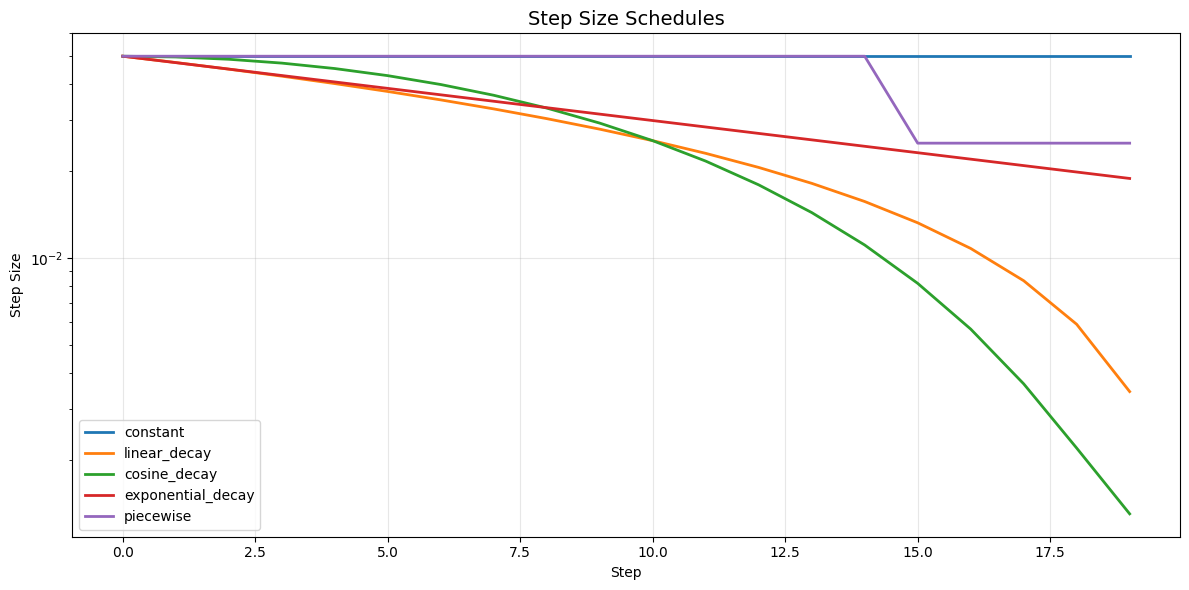


Generating scheduler comparison...
Generating trajectories for scheduler comparison...


Sampling with piecewise_constant: 100%|██████████| 20/20 [00:01<00:00, 16.89it/s]


Saved scheduler comparison animation: ./eqm_mnist_results/scheduler_comparison.gif

Generating final comparison grid...


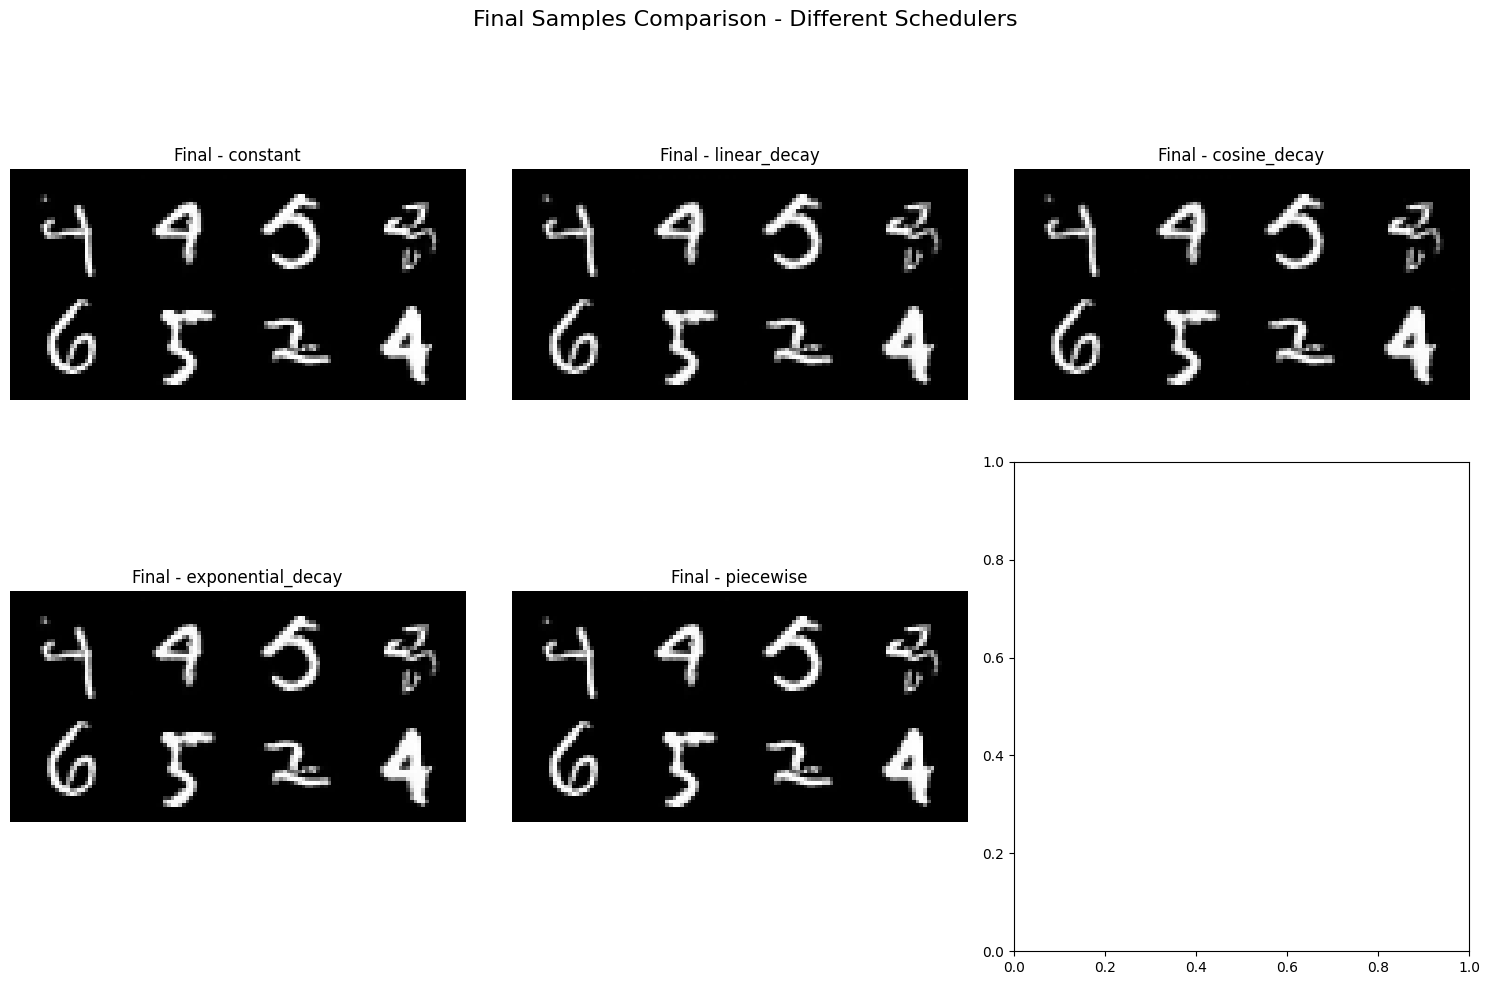


Scheduler comparison complete! Files saved to: ./eqm_mnist_results


In [ ]:
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.enabled=False
torch.backends.cudnn.deterministic=True

# ==================== Scheduler Comparison for Sampling ====================

class NoiseScheduler:

    @staticmethod
    def linear_decay(step, total_steps, initial_step_size, final_step_size=0.001):
        return initial_step_size + (final_step_size - initial_step_size) * (step / total_steps)

    @staticmethod
    def cosine_decay(step, total_steps, initial_step_size, final_step_size=0.001):
        angle = step / total_steps * np.pi
        return final_step_size + 0.5 * (initial_step_size - final_step_size) * (1 + np.cos(angle))

    @staticmethod
    def exponential_decay(step, total_steps, initial_step_size, decay_factor=0.95):
        return initial_step_size * (decay_factor ** step)

    @staticmethod
    def constant(step, total_steps, initial_step_size, **_):
        return initial_step_size

    @staticmethod
    def piecewise_constant(step, total_steps, initial_step_size, milestones=None, values=None):
        if milestones is None:
            milestones = [total_steps // 2, 3 * total_steps // 4]
            values = [1.0, 0.5, 0.2]

        current_scale = values[-1]
        for i, milestone in enumerate(milestones):
            if step < milestone:
                current_scale = values[i]
                break
        return initial_step_size * current_scale

def sample_with_scheduler(model, init_samples, scheduler_name="constant",
                         steps=50, initial_step_size=0.01, return_trajectory=True, **scheduler_kwargs):
    sampler = EqMSampler(model, config)

    x = init_samples.clone()
    trajectory = [x.cpu()] if return_trajectory else None

    scheduler = getattr(NoiseScheduler, scheduler_name)

    model.eval()
    with torch.no_grad():
        for step in tqdm.tqdm(range(steps), desc=f"Sampling with {scheduler_name}"):
            step_size = scheduler(step, steps, initial_step_size, **scheduler_kwargs)
            grad = model(x)
            x = x - step_size * grad

            if return_trajectory:
                trajectory.append(x.cpu())

    if return_trajectory:
        return x, trajectory
    return x

def compare_schedulers_animation(model, init_samples, steps=50, initial_step_size=0.01):
    # Define schedulers to compare
    scheduler_configs = {
        "constant": {"scheduler_name": "constant"},
        "linear_decay": {"scheduler_name": "linear_decay", "final_step_size": 0.001},
        "cosine_decay": {"scheduler_name": "cosine_decay", "final_step_size": 0.001},
        "exponential_decay": {"scheduler_name": "exponential_decay", "decay_factor": 0.95},
        "piecewise": {"scheduler_name": "piecewise_constant", "milestones": [15, 35], "values": [1.0, 0.5, 0.2]}
    }

    print("Generating trajectories for scheduler comparison...")
    trajectories = {}
    final_samples = {}

    for name, cfg in scheduler_configs.items():
        samples, traj = sample_with_scheduler(
            model,
            init_samples.clone(),
            initial_step_size=initial_step_size,
            steps=steps,
            return_trajectory=True,
            **cfg
        )
        trajectories[name] = traj
        final_samples[name] = samples

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    n_samples_show = 16

    plt.close(fig)

    def update(frame):
        for idx, (name, ax) in enumerate(zip(scheduler_configs.keys(), axes)):
            ax.clear()

            samples = trajectories[name][frame][:n_samples_show]
            samples = (samples + 1) / 2
            samples = samples.clamp(0, 1)

            grid = torchvision.utils.make_grid(samples, nrow=4, normalize=False)
            ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')

            scheduler = getattr(NoiseScheduler, scheduler_configs[name]["scheduler_name"])
            step_size = scheduler(frame, steps, initial_step_size, **{k:v for k,v in scheduler_configs[name].items() if k != "scheduler_name"})

            ax.set_title(f"{name}\nStep {frame} | step_size={step_size:.4f}", fontsize=11)
            ax.axis('off')

        if len(scheduler_configs) < len(axes):
            axes[-1].set_visible(False)

        fig.suptitle(f"Scheduler Comparison - Sampling Progress\n{frame}/{steps-1} steps",
                    fontsize=16, fontweight='bold')
        return axes

    anim = animation.FuncAnimation(fig, update, frames=steps, interval=200, blit=False)

    try:
        anim.save(f"{config.save_dir}/scheduler_comparison.gif", writer='pillow', fps=10)
        print(f"Saved scheduler comparison animation: {config.save_dir}/scheduler_comparison.gif")
    except Exception as e:
        print(f"Warning: Could not save scheduler animation: {e}")
        for name, samples in final_samples.items():
            visualize_samples(samples, f"Final samples - {name}", f"final_samples_{name}.png", nrow=8)

    plt.close()

    return final_samples

def plot_scheduler_step_sizes(steps=50, initial_step_size=0.01):
    """Plot step size schedules for visual reference"""
    scheduler_configs = {
        "constant": {"scheduler_name": "constant"},
        "linear_decay": {"scheduler_name": "linear_decay", "final_step_size": 0.001},
        "cosine_decay": {"scheduler_name": "cosine_decay", "final_step_size": 0.001},
        "exponential_decay": {"scheduler_name": "exponential_decay", "decay_factor": 0.95},
        "piecewise": {"scheduler_name": "piecewise_constant", "milestones": [15, 35], "values": [1.0, 0.5, 0.2]}
    }

    plt.figure(figsize=(12, 6))

    for name, cfg in scheduler_configs.items():
        scheduler = getattr(NoiseScheduler, cfg["scheduler_name"])
        step_sizes = [scheduler(step, steps, initial_step_size,
                               **{k:v for k,v in cfg.items() if k != "scheduler_name"})
                     for step in range(steps)]
        plt.plot(step_sizes, label=name, linewidth=2)

    plt.title("Step Size Schedules", fontsize=14)
    plt.xlabel("Step")
    plt.ylabel("Step Size")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/scheduler_step_sizes.png", dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


n_compare_samples = 36
init_samples_for_schedulers = torch.randn(n_compare_samples, 1, 28, 28).to(config.device)

plot_scheduler_step_sizes(STEPS, INITIAL_STEP_SIZE)

print("\nGenerating scheduler comparison...")
final_samples_per_scheduler = compare_schedulers_animation(
    model,
    init_samples_for_schedulers,
    steps=STEPS,
    initial_step_size=INITIAL_STEP_SIZE
)

print("\nGenerating final comparison grid...")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (scheduler_name, samples) in enumerate(final_samples_per_scheduler.items()):
    if idx < len(axes):
        samples_vis = (samples[:8] + 1) / 2
        samples_vis = samples_vis.clamp(0, 1)
        grid = torchvision.utils.make_grid(samples_vis, nrow=4, normalize=False)
        axes[idx].imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
        axes[idx].set_title(f"Final - {scheduler_name}")
        axes[idx].axis('off')

plt.suptitle("Final Samples Comparison - Different Schedulers", fontsize=16)
plt.tight_layout()
plt.savefig(f"{config.save_dir}/final_samples_scheduler_grid.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print(f"\nScheduler comparison complete! Files saved to: {config.save_dir}")

# Second Order

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import tqdm
import os
from typing import Callable, Optional, Tuple

# ==================== Configuration ====================

class Config:
    batch_size = 32
    num_workers = 1

    model_type = "unet"
    hidden_dim = 128

    epochs = 6
    lr = 1e-4
    grad_clip = 1.0

    c_type = "truncated"
    c_a = 0.8
    c_b = 2.0
    grad_multiplier = 4.0

    # ---------------------
    second_order_lambda = 0.01
    # ---------------------

    sample_steps = 50
    step_size = 0.01
    nesterov_mu = 0.35
    adaptive_threshold = 0.1

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    log_interval = 5
    vis_interval = 100
    save_dir = "./eqm_mnist_results"

config = Config()
os.makedirs(config.save_dir, exist_ok=True)

# ==================== Model Architectures ====================

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=1, hidden_dim=64):
        super().__init__()

        self.enc1 = self._block(in_channels, hidden_dim)  # 28x28
        self.enc2 = self._block(hidden_dim, hidden_dim * 2)  # 14x14
        self.enc3 = self._block(hidden_dim * 2, hidden_dim * 4)  # 7x7

        self.bottleneck = self._block(hidden_dim * 4, hidden_dim * 4)  # 7x7

        self.upconv3 = nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2,
                                         kernel_size=2, stride=2)  # 7x7 → 14x14
        self.dec3 = self._block(hidden_dim * 4, hidden_dim * 2)  # 14x14

        self.upconv2 = nn.ConvTranspose2d(hidden_dim * 2, hidden_dim,
                                         kernel_size=2, stride=2)  # 14x14 → 28x28
        self.dec2 = self._block(hidden_dim * 2, hidden_dim)  # 28x28

        self.dec1 = nn.Conv2d(hidden_dim, in_channels, 3, padding=1)  # 28x28

    def _block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU()
        )

    def forward(self, x):
        e1 = self.enc1(x)  # 28x28

        e2 = self.enc2(F.max_pool2d(e1, 2))  # 14x14

        e3 = self.enc3(F.max_pool2d(e2, 2))  # 7x7

        b = self.bottleneck(e3)  # 7x7

        up3 = self.upconv3(b)  # 14x14
        if up3.size() != e2.size():
            up3 = F.interpolate(up3, size=e2.shape[2:], mode='nearest')
        d3 = torch.cat([up3, e2], dim=1)
        d3 = self.dec3(d3)

        up2 = self.upconv2(d3)  # 28x28
        if up2.size() != e1.size():
            up2 = F.interpolate(up2, size=e1.shape[2:], mode='nearest')
        d2 = torch.cat([up2, e1], dim=1)
        d2 = self.dec2(d2)

        return self.dec1(d2)

class MLPGradientNet(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        grad_flat = self.net(x_flat)
        return grad_flat.view_as(x)

# ==================== Gradient Magnitude Function ====================

def get_c_function(c_type: str, a: float = 0.8, b: float = 2.0) -> Callable:
    if c_type == "linear":
        def c(gamma):
            return 1 - gamma

    elif c_type == "truncated":
        def c(gamma):
            return torch.where(gamma <= a,
                             torch.ones_like(gamma),
                             (1 - gamma) / (1 - a))

    elif c_type == "piecewise":
        def c(gamma):
            return torch.where(gamma <= a,
                             b - (b - 1) / a * gamma,
                             (1 - gamma) / (1 - a))

    else:
        raise ValueError(f"Unknown c_type: {c_type}")

    return c

# ==================== Training ====================

class EqMTrainer:
    def __init__(self, config):
        self.config = config

        self.train_loader, self.test_loader = self._get_data()

        if config.model_type == "unet":
            self.model = SimpleUNet(hidden_dim=config.hidden_dim).to(config.device)
        else:
            self.model = MLPGradientNet(hidden_dim=config.hidden_dim).to(config.device)

        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=config.lr)

        self.c_func = get_c_function(config.c_type, config.c_a, config.c_b)

        self.train_losses = []

    def _get_data(self):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

        train_dataset = torchvision.datasets.MNIST(
            root='./data', train=True, download=True, transform=transform
        )
        test_dataset = torchvision.datasets.MNIST(
            root='./data', train=False, download=True, transform=transform
        )

        train_loader = DataLoader(train_dataset, batch_size=config.batch_size,
                                shuffle=True, num_workers=config.num_workers, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=config.batch_size,
                               shuffle=False, num_workers=config.num_workers, pin_memory=True)

        return train_loader, test_loader

    def train_epoch(self, epoch):
        self.model.train()
        total_loss_avg = 0

        # We can track individual loss components for debugging
        loss_1st_avg = 0
        loss_2nd_avg = 0

        pbar = tqdm.tqdm(self.train_loader, desc=f"Epoch {epoch}")
        for batch_idx, (data, _) in enumerate(pbar):
            data = data.to(config.device)
            batch_size = data.size(0)

            noise = torch.randn_like(data)
            gamma = torch.rand(batch_size, device=config.device)

            gamma_view = gamma.view(-1, 1, 1, 1)
            x_gamma = (gamma_view * data + (1 - gamma_view) * noise).detach()
            x_gamma.requires_grad_(True)

            c_val = self.c_func(gamma).view(-1, 1, 1, 1) * config.grad_multiplier
            target_grad = (noise - data) * c_val

            pred_gradient = self.model(x_gamma)

            loss_1st = F.mse_loss(pred_gradient, target_grad)

            if config.second_order_lambda > 0:
                v = torch.randn_like(x_gamma)

                model_jvp = torch.autograd.grad(
                    outputs=pred_gradient,
                    inputs=x_gamma,
                    grad_outputs=v,
                    create_graph=True,
                    retain_graph=True,
                    only_inputs=True
                )[0]

                target_jvp = -c_val * v

                loss_2nd = F.mse_loss(model_jvp, target_jvp)
            else:
                loss_2nd = torch.tensor(0.0, device=config.device)

            total_loss = loss_1st + (config.second_order_lambda * loss_2nd)

            self.optimizer.zero_grad()
            total_loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), config.grad_clip)
            self.optimizer.step()

            total_loss_avg += total_loss.item()
            loss_1st_avg += loss_1st.item()
            loss_2nd_avg += loss_2nd.item()

            if batch_idx % config.log_interval == 0:
                pbar.set_postfix({
                    'L_total': f"{total_loss.item():.4f}",
                    'L_1st': f"{loss_1st.item():.4f}",
                    'L_2nd': f"{loss_2nd.item():.4f}"
                })

        n_batches = len(self.train_loader)
        avg_loss = total_loss_avg / n_batches
        self.train_losses.append(avg_loss)

        return avg_loss

    def validate(self):
        self.model.eval()
        total_grad_norm = 0

        with torch.no_grad():
            for data, _ in self.test_loader:
                data = data.to(config.device)
                grad = self.model(data)
                grad_norm = grad.norm(dim=1).mean().item()
                total_grad_norm += grad_norm
                break

        avg_grad_norm = total_grad_norm / len(self.test_loader) if len(self.test_loader) > 0 else 0
        return avg_grad_norm

# ==================== Sampling Methods ====================

class EqMSampler:
    def __init__(self, model, config):
        self.model = model
        self.config = config

    def sample_gd(self, init_samples: torch.Tensor, steps: int = None,
                  step_size: float = None, return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size

        x = init_samples.clone()
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="GD Sampling"):
                grad = self.model(x)
                x = x - step_size * grad

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x

    def sample_nag(self, init_samples: torch.Tensor, steps: int = None,
                   step_size: float = None, mu: float = None,
                   return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size
        if mu is None:
            mu = config.nesterov_mu

        x = init_samples.clone()
        x_last = x.clone()
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="NAG-GD Sampling"):
                look_ahead = x + mu * (x - x_last)

                grad = self.model(look_ahead)

                x_last = x
                x = x - step_size * grad

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x

    def sample_muon(self, init_samples: torch.Tensor, steps: int = None,
                step_size: float = None, momentum: float = 0.95,
                return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size

        x = init_samples.clone()
        momentum_buffer = torch.zeros_like(x)
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="Muon Sampling"):
                grad = self.model(x)

                if i > 0 and momentum_buffer.norm() > 1e-8:
                    projection = (grad * momentum_buffer).sum() / (momentum_buffer.norm()**2)
                    grad = grad - projection * momentum_buffer

                momentum_buffer = momentum * momentum_buffer + grad

                x = x - step_size * momentum_buffer

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x


    def sample_adaptive(self, init_samples: torch.Tensor, step_size: float = None,
                       threshold: float = None, max_steps: int = 1000) -> Tuple[torch.Tensor, int]:
        if step_size is None:
            step_size = config.step_size
        if threshold is None:
            threshold = config.adaptive_threshold

        x = init_samples.clone()
        self.model.eval()

        with torch.no_grad():
            for i in range(max_steps):
                grad = self.model(x)
                grad_norm = grad.norm(dim=1).mean().item()

                if grad_norm < threshold:
                    break

                x = x - step_size * grad

        return x, i + 1

# ==================== Visualization ====================

def plot_training_curve(trainer):
    plt.figure(figsize=(10, 5))
    plt.plot(trainer.train_losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.yscale('log')
    plt.grid(True)
    plt.savefig(f"{config.save_dir}/training_loss.png", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_samples(samples, title, filename, nrow=8):
    samples = (samples + 1) / 2  # Denormalize
    samples = samples.clamp(0, 1)

    grid = torchvision.utils.make_grid(samples, nrow=nrow, normalize=False)

    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.savefig(f"{config.save_dir}/{filename}", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_sampling_trajectory_animation(trajectory, filename, n_frames=50):

    fig, ax = plt.subplots(figsize=(6, 6))
    plt.close(fig)

    total_steps = len(trajectory)
    step_indices = np.linspace(0, total_steps-1, min(n_frames, total_steps), dtype=int)

    def update(frame_idx):
        ax.clear()
        step = step_indices[frame_idx]
        samples = trajectory[step][:25]
        samples = (samples + 1) / 2  # Denormalize
        samples = samples.clamp(0, 1)

        grid = torchvision.utils.make_grid(samples, nrow=5, normalize=False)
        ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
        ax.set_title(f"Step {step}/{total_steps-1}")
        ax.axis('off')

    anim = animation.FuncAnimation(fig, update, frames=len(step_indices),
                                   interval=200, blit=False)

    try:
        anim.save(f"{config.save_dir}/{filename}", writer='pillow', fps=5)
        print(f"Saved animation: {filename}")
    except Exception as e:
        print(f"Warning: Could not save animation {filename}: {e}")
        visualize_samples(trajectory[0][:25], "Sampling Start", "sampling_start.png", nrow=5)
        visualize_samples(trajectory[-1][:25], "Sampling End", "sampling_end.png", nrow=5)
    plt.close()

def compare_step_sizes_animation(model, config, init_samples):

    step_sizes = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
    sampler = EqMSampler(model, config)
    steps = 50

    print("Generating trajectories for different step sizes...")
    trajectories = []
    for step_size in step_sizes:
        print(f"  step_size={step_size}")
        _, trajectory = sampler.sample_gd(init_samples.clone(), steps=steps,
                                         step_size=step_size, return_trajectory=True)
        trajectories.append(trajectory)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    plt.close(fig)

    def update(frame):
        for idx, (ax, step_size, trajectory) in enumerate(zip(axes, step_sizes, trajectories)):
            ax.clear()
            samples = trajectory[frame][:9]  # 3x3 grid
            samples = (samples + 1) / 2
            samples = samples.clamp(0, 1)
            grid = torchvision.utils.make_grid(samples, nrow=3, normalize=False)
            ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
            ax.set_title(f"Step Size: {step_size}", fontsize=10)
            ax.axis('off')

        fig.suptitle(f"Generation Step {frame}", fontsize=16)
        return axes

    anim = animation.FuncAnimation(fig, update, frames=steps, interval=200, blit=False)
    try:
        anim.save(f"{config.save_dir}/step_size_comparison.gif", writer='pillow', fps=5)
        print("Saved step size comparison animation")
    except Exception as e:
        print(f"Warning: Could not save step size animation: {e}")
        compare_step_sizes(model, init_samples)
    plt.close()

def compare_sampling_algorithms_animation(model, config, init_samples):
    sampler = EqMSampler(model, config)
    steps = 50

    print("Generating trajectories for GD vs NAG vs Muon comparison...")
    _, trajectory_gd = sampler.sample_gd(init_samples.clone(), steps=steps, return_trajectory=True)
    _, trajectory_nag = sampler.sample_nag(init_samples.clone(), steps=steps, return_trajectory=True)
    _, trajectory_muon = sampler.sample_muon(init_samples.clone(), steps=steps, return_trajectory=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    ax_gd, ax_nag, ax_muon = axes
    plt.close(fig)

    def update(frame):
        # GD
        ax_gd.clear()
        samples_gd = trajectory_gd[frame][:16]
        samples_gd = (samples_gd + 1) / 2
        samples_gd = samples_gd.clamp(0, 1)
        grid_gd = torchvision.utils.make_grid(samples_gd, nrow=4, normalize=False)
        ax_gd.imshow(grid_gd.permute(1, 2, 0).numpy(), cmap='gray')
        ax_gd.set_title(f"Vanilla GD\nStep {frame}", fontsize=11)
        ax_gd.axis('off')

        # NAG
        ax_nag.clear()
        samples_nag = trajectory_nag[frame][:16]
        samples_nag = (samples_nag + 1) / 2
        samples_nag = samples_nag.clamp(0, 1)
        grid_nag = torchvision.utils.make_grid(samples_nag, nrow=4, normalize=False)
        ax_nag.imshow(grid_nag.permute(1, 2, 0).numpy(), cmap='gray')
        ax_nag.set_title(f"NAG-GD\nStep {frame}", fontsize=11)
        ax_nag.axis('off')

        # Muon
        ax_muon.clear()
        samples_muon = trajectory_muon[frame][:16]
        samples_muon = (samples_muon + 1) / 2
        samples_muon = samples_muon.clamp(0, 1)
        grid_muon = torchvision.utils.make_grid(samples_muon, nrow=4, normalize=False)
        ax_muon.imshow(grid_muon.permute(1, 2, 0).numpy(), cmap='gray')
        ax_muon.set_title(f"Muon\nStep {frame}", fontsize=11)
        ax_muon.axis('off')

        fig.suptitle(f"EqM Sampling Algorithm Comparison\n{frame}/{steps-1} steps",
                    fontsize=14, fontweight='bold')
        return axes

    anim = animation.FuncAnimation(fig, update, frames=steps, interval=200, blit=False)
    try:
        anim.save(f"{config.save_dir}/sampling_comparison.gif", writer='pillow', fps=5)
        print("Saved GD vs NAG vs Muon comparison animation")
    except Exception as e:
        print(f"Warning: Could not save sampling comparison animation: {e}")
    plt.close()

def compare_step_sizes(model, init_samples):
    step_sizes = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    sampler = EqMSampler(model, config)

    for idx, step_size in enumerate(step_sizes):
        print(f"Sampling with step_size={step_size}")
        samples = sampler.sample_gd(init_samples[:25],
                                   step_size=step_size,
                                   steps=50)

        vis_samples = (samples + 1) / 2
        vis_samples = vis_samples.clamp(0, 1)

        grid = torchvision.utils.make_grid(vis_samples, nrow=5, normalize=False)
        axes[idx].imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
        axes[idx].set_title(f"Step Size: {step_size}")
        axes[idx].axis('off')

    plt.suptitle("Effect of Different Step Sizes on Generation")
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/step_size_comparison.png", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_gradient_field(model, epoch):
    model.eval()

    x_range = np.linspace(-3, 3, 20)
    y_range = np.linspace(-3, 3, 20)
    X, Y = np.meshgrid(x_range, y_range)

    device = next(model.parameters()).device
    grid_points = []
    for i in range(len(x_range)):
        for j in range(len(y_range)):
            sample = torch.randn(1, 1, 28, 28).to(device)
            sample_flat = sample.view(1, -1)
            sample_flat[0, 0] = X[i, j]
            sample_flat[0, 1] = Y[i, j]
            grid_points.append(sample_flat.view(1, 1, 28, 28))

    with torch.no_grad():
        grads = []
        for point in grid_points:
            grad = model(point)
            grad_flat = grad.view(-1)
            grads.append([grad_flat[0].item(), grad_flat[1].item()])
        grads = np.array(grads).reshape(20, 20, 2)

    plt.figure(figsize=(10, 10))
    plt.quiver(X, Y, grads[:, :, 0], grads[:, :, 1], scale=50)
    plt.title(f"Gradient Field Visualization (Epoch {epoch})")
    plt.xlabel("Latent Dim 1")
    plt.ylabel("Latent Dim 2")
    plt.grid(True)
    plt.savefig(f"{config.save_dir}/gradient_field_epoch_{epoch}.png", dpi=150, bbox_inches='tight')
    plt.close()

def test_partial_denoising(model, config):
    model.eval()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                        download=True, transform=transform)
    real_images = torch.stack([dataset[i][0] for i in range(25)]).to(config.device)

    noise = torch.randn_like(real_images)
    gamma = 0.5
    partial_noised = gamma * real_images + (1 - gamma) * noise

    with torch.no_grad():
        current = partial_noised.clone()
        trajectory = []
        step_labels = []
        target_steps = [0, 1, 5, 10, 20, 45]

        for i in range(50):
            if i in target_steps:
                trajectory.append(current.cpu())
                step_labels.append(i)

            grad = model(current)
            current = current - 0.01 * grad

        if len(trajectory) < 5:
            trajectory.append(current.cpu())
            step_labels.append(49)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes_flat = axes.flatten()

    images_and_titles = [
        (real_images, "Original"),
        (partial_noised, f"Partial Noise (γ={gamma})")
    ] + [(trajectory[i], f"Step {step_labels[i]}") for i in range(len(trajectory))]

    for idx, (ax, (img, title)) in enumerate(zip(axes_flat, images_and_titles)):
        if idx >= len(axes_flat):
            break

        img_denorm = (img + 1) / 2  # From [-1,1] to [0,1]
        img_denorm = img_denorm.clamp(0, 1)

        grid_img = torchvision.utils.make_grid(img_denorm, nrow=5, normalize=False)
        ax.imshow(grid_img.permute(1, 2, 0).cpu().numpy(), cmap='gray')
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    for idx in range(len(images_and_titles), len(axes_flat)):
        fig.delaxes(axes_flat[idx])

    plt.suptitle("Partial Denoising with EqM", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/partial_denoising.png", dpi=150, bbox_inches='tight')
    plt.close()



In [ ]:
# ==================== Main Training & Testing ====================

def main():
    print(f"Using device: {config.device}")
    print(f"Configuration: {vars(config)}")

    trainer = EqMTrainer(config)

    grad_norms = []

    print("Starting training...")
    for epoch in range(config.epochs):
        avg_loss = trainer.train_epoch(epoch)

        if epoch % config.vis_interval == 0:
            avg_grad_norm = trainer.validate()
            grad_norms.append(avg_grad_norm)
            print(f"Epoch {epoch}: Loss={avg_loss:.6f}, Grad Norm at Real Data={avg_grad_norm:.6f}")

            visualize_gradient_field(trainer.model, epoch)

    torch.save(trainer.model.state_dict(), f"{config.save_dir}/eqm_mnist.pth")

    plot_training_curve(trainer)

    print("\nGenerating samples...")
    sampler = EqMSampler(trainer.model, config)

    n_samples = 64
    init_samples = torch.randn(n_samples, 1, 28, 28).to(config.device)

    print("\nSampling with Vanilla Gradient Descent...")
    samples_gd, trajectory_gd = sampler.sample_gd(
        init_samples.clone(), steps=50, return_trajectory=True
    )
    visualize_samples(samples_gd, "Samples - Vanilla GD", "samples_gd.png")

    print("\nCreating sampling trajectory animation...")
    visualize_sampling_trajectory_animation(trajectory_gd, "sampling_trajectory.gif")

    print("\nSampling with NAG-GD...")
    samples_nag, trajectory_nag = sampler.sample_nag(init_samples.clone(), steps=50, return_trajectory=True)
    visualize_samples(samples_nag, "Samples - NAG-GD", "samples_nag.png")

    print("\nCreating GD vs NAG comparison animation...")
    compare_sampling_algorithms_animation(trainer.model, config, init_samples.clone())

    print("\nSampling with Adaptive Compute...")
    samples_adaptive, steps_used = sampler.sample_adaptive(init_samples.clone())
    visualize_samples(samples_adaptive, f"Samples - Adaptive (avg {steps_used:.1f} steps)",
                     "samples_adaptive.png")
    print(f"Average steps used: {steps_used:.1f}")

    print("\nCreating step size comparison animation...")
    compare_step_sizes_animation(trainer.model, config, init_samples.clone())

    print("\nTesting partial denoising...")
    test_partial_denoising(trainer.model, config)

    print(f"\nAll results saved to: {config.save_dir}")

if __name__ == "__main__":
    main()

Using device: cuda
Configuration: {}
Starting training...


Epoch 0: 100%|██████████| 1875/1875 [05:08<00:00,  6.07it/s, L_total=3.9946, L_1st=2.6092, L_2nd=138.5478]


Epoch 0: Loss=4.751991, Grad Norm at Real Data=0.000587


Epoch 5: 100%|██████████| 1875/1875 [05:08<00:00,  6.08it/s, L_total=3.9008, L_1st=2.6848, L_2nd=121.6065]



Generating samples...

Sampling with Vanilla Gradient Descent...


...

  step_size=0.05


GD Sampling: 100%|██████████| 50/50 [00:01<00:00, 25.80it/s]


  step_size=0.1


GD Sampling: 100%|██████████| 50/50 [00:01<00:00, 25.69it/s]


Saved step size comparison animation

Testing partial denoising...

All results saved to: ./eqm_mnist_results


In [ ]:
!zip -r equilibrium_matching_results.zip ./eqm_mnist_results/
from google.colab import files
files.download('equilibrium_matching_results.zip')

updating: eqm_mnist_results/ (stored 0%)
updating: eqm_mnist_results/samples_adaptive.png (deflated 20%)
updating: eqm_mnist_results/samples_nag.png (deflated 18%)
updating: eqm_mnist_results/training_loss.png (deflated 16%)
updating: eqm_mnist_results/eqm_mnist.pth (deflated 8%)
updating: eqm_mnist_results/partial_denoising.png (deflated 6%)
updating: eqm_mnist_results/step_size_comparison.gif (deflated 0%)
updating: eqm_mnist_results/samples_gd.png (deflated 18%)
updating: eqm_mnist_results/sampling_trajectory.gif (deflated 0%)
updating: eqm_mnist_results/sampling_comparison.gif (deflated 0%)
updating: eqm_mnist_results/gradient_field_epoch_0.png (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Second Order Sampling

In [ ]:
import torch
import tqdm

def conjugate_gradient(H_func, b, x_init=None, max_iter=10, tol=1e-4):
    """
    Solves the linear system Ax = b using Conjugate Gradient.
    A is represented by H_func(v) which computes matrix-vector product Av.
    """
    if x_init is None:
        x = torch.zeros_like(b)
    else:
        x = x_init

    r = b - H_func(x)
    p = r.clone()
    rsold = torch.dot(r.flatten(), r.flatten())

    for i in range(max_iter):
        Ap = H_func(p)

        pAp = torch.dot(p.flatten(), Ap.flatten())

        if pAp <= 1e-8:
            break

        alpha = rsold / pAp

        x = x + alpha * p
        r = r - alpha * Ap

        rsnew = torch.dot(r.flatten(), r.flatten())

        if torch.sqrt(rsnew) < tol:
            break

        p = r + (rsnew / rsold) * p
        rsold = rsnew

    return x

# ==================== Updated Sampler ====================

class EqMSampler:
    def __init__(self, model, config):
        self.model = model
        self.config = config

    def sample_gd(self, init_samples: torch.Tensor, steps: int = None, step_size: float = None):
        steps = steps or self.config.sample_steps
        step_size = step_size or self.config.step_size
        x = init_samples.clone()

        self.model.eval()
        for _ in tqdm.tqdm(range(steps), desc="Vanilla GD"):
            x.requires_grad_(False)
            with torch.no_grad():
                grad = self.model(x)
                x = x - step_size * grad
        return x

    def sample_newton_cg(self, init_samples: torch.Tensor,
                         steps: int = 20,
                         step_size: float = 1.0,
                         cg_max_iter: int = 5):
        x = init_samples.clone()
        self.model.eval()

        pbar = tqdm.tqdm(range(steps), desc="Newton-CG Sampling")

        for k in pbar:
            x = x.detach().requires_grad_(True)

            f_x = self.model(x)

            grad_norm = f_x.norm().item()
            pbar.set_postfix({"grad_norm": f"{grad_norm:.4f}"})
            if grad_norm < 1e-4:
                break

            def H_func(v):
                hvp = torch.autograd.grad(
                    outputs=f_x,
                    inputs=x,
                    grad_outputs=v,
                    retain_graph=True,
                    create_graph=False
                )[0]
                return hvp + 1e-3 * v

            target_b = -f_x.detach()

            d_guess = target_b.clone()
            d = conjugate_gradient(H_func, target_b, x_init=d_guess, max_iter=cg_max_iter)

            with torch.no_grad():
                x = x + step_size * d

        return x.detach()

    def sample_lbfgs(self, init_samples: torch.Tensor, steps: int = 20, lr: float = 1.0):
        x = init_samples.clone().detach().requires_grad_(True)
        optimizer = torch.optim.LBFGS([x], lr=lr, history_size=10,
                                    max_iter=5, line_search_fn="strong_wolfe")

        pbar = tqdm.tqdm(range(steps), desc="L-BFGS Sampling")

        for _ in pbar:
            def closure():
                optimizer.zero_grad()

                pred_grad = self.model(x)

                loss = 0.5 * torch.sum(pred_grad ** 2)

                loss.backward()

                return loss

            loss_val = optimizer.step(closure)

            if loss_val < 1e-5:
                break

        return x.detach()

    def sample_levenberg_marquardt(self, init_samples: torch.Tensor, steps: int = 20):
        """
        Levenberg-Marquardt Algorithm.
        Solves (H + lambda*I) * delta = -f(x).
        Adjusts lambda adaptively to ensure stability.
        """
        x = init_samples.clone()
        lambda_damping = 1.0

        pbar = tqdm.tqdm(range(steps), desc="Levenberg-Marquardt")

        for k in pbar:
            x = x.detach().requires_grad_(True)
            f_x = self.model(x)

            current_norm = 0.5 * torch.sum(f_x**2).item()

            def H_damped_func(v):
                hvp = torch.autograd.grad(f_x, x, grad_outputs=v, retain_graph=True)[0]
                return hvp + lambda_damping * v

            target = -f_x.detach()
            delta = conjugate_gradient(H_damped_func, target, max_iter=10)

            with torch.no_grad():
                x_candidate = x + delta
                f_candidate = self.model(x_candidate)
                new_norm = 0.5 * torch.sum(f_candidate**2).item()

            if new_norm < current_norm:
                x = x_candidate
                lambda_damping = max(1e-4, lambda_damping / 5.0)
                if new_norm < 1e-5: break
            else:
                lambda_damping = min(100.0, lambda_damping * 5.0)

            pbar.set_postfix({"norm": f"{current_norm:.4f}", "lambda": f"{lambda_damping:.4f}"})

        return x.detach()

    def sample_chebyshev(self, init_samples: torch.Tensor, steps: int = 50,
                        lambda_min: float = 0.1, lambda_max: float = 4.0):
        x = init_samples.clone()
        alpha = 2.0 / (lambda_max + lambda_min) # Step size
        mu = (lambda_max - lambda_min) / (lambda_max + lambda_min) # Spectral radius

        omega = 2.0
        omega_prev = 0.0

        prev_x = x.clone()

        self.model.eval()
        with torch.no_grad():
            for k in tqdm.tqdm(range(steps), desc="Chebyshev Sampling"):
                grad = self.model(x)

                if k == 0:
                    omega = 2.0
                elif k == 1:
                    omega = 1.0 / (1.0 - 0.5 * mu**2)
                else:
                    omega = 1.0 / (1.0 - 0.25 * mu**2 * omega)

                term_gradient = x - alpha * grad
                new_x = omega * term_gradient + (1.0 - omega) * prev_x

                prev_x = x
                x = new_x

                if k % 10 == 0:
                    omega = 2.0
                    prev_x = x

        return x


In [ ]:
def main():
    model_path = "eqm_mnist.pth"

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found: {model_path}. Train it first!")

    print("\n[2/4] Loading model...")
    model = SimpleUNet(hidden_dim=config.hidden_dim).to(config.device)
    checkpoint = torch.load(model_path, map_location=config.device, weights_only=True)
    model.load_state_dict(checkpoint)
    model.eval()

    print("\n--- Sampling Comparison ---")
    sampler = EqMSampler(model, config)
    init_noise = torch.randn(64, 1, 28, 28).to(config.device)

    samples_gd = sampler.sample_gd(init_noise, steps=100, step_size=0.01)
    visualize_samples(samples_gd, "GD Sampling", "samples_gd.png")

    samples_newton = sampler.sample_newton_cg(init_noise, steps=2000, step_size=0.08)
    visualize_samples(samples_newton, "Newton-CG Sampling", "samples_newton.png")

    samples_lbfgs = sampler.sample_lbfgs(init_noise, steps=200, lr=0.1)
    visualize_samples(samples_lbfgs, "LBFGS Sampling", "samples_lbfgs.png")

    samples_levenberg_marquardt = sampler.sample_levenberg_marquardt(init_noise, steps=20)
    visualize_samples(samples_levenberg_marquardt, "Levenberg Marquardt", "samples_levenberg_marquardt.png")

    samples_chebyshev = sampler.sample_chebyshev(init_noise, steps=200)
    visualize_samples(samples_chebyshev, "Chebyshev", "samples_chebyshev.png")


if __name__ == "__main__":
    main()


[2/4] Loading model...

--- Sampling Comparison ---


Chebyshev Sampling: 100%|██████████| 200/200 [00:07<00:00, 25.43it/s]


# Latent EqM

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import tqdm
import os
from typing import Callable, Optional, Tuple

# ==================== Configuration ====================

class Config:
    batch_size = 32
    num_workers = 1

    vae_model = "stabilityai/sd-vae-ft-mse"
    latent_scale_factor = 0.18215
    compute_scale_factor = False

    model_type = "unet"  # "unet" or "mlp"
    hidden_dim = 128

    latent_channels = 4
    latent_size = 8

    epochs = 10
    lr = 1e-4
    grad_clip = 1.0

    c_type = "truncated"
    c_a = 0.8
    c_b = 2.0
    grad_multiplier = 4.0

    sample_steps = 1000
    step_size = 0.5
    nesterov_mu = 0.35
    adaptive_threshold = 0.1

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    force_latent_size = None

    log_interval = 5
    vis_interval = 100
    save_dir = "./leqm_mnist_results"

config = Config()
os.makedirs(config.save_dir, exist_ok=True)

# ==================== VAE Integration ====================

class VAEWrapper(nn.Module):
    """Frozen VAE for encoding/decoding between image and latent space"""
    def __init__(self, model_path: str, scale_factor: float, compute_scale: bool = False):
        super().__init__()

        try:
            from diffusers import AutoencoderKL
            self.vae = AutoencoderKL.from_pretrained(model_path)
            print(f"Loaded VAE from {model_path}")
        except ImportError:
            print("Warning: diffusers not found. Creating dummy VAE for MNIST.")
            print("For Stable Diffusion VAE: pip install diffusers transformers")
            self.vae = self._create_dummy_vae()
        except Exception as e:
            print(f"Could not load VAE: {e}. Creating dummy VAE.")
            self.vae = self._create_dummy_vae()

        self.vae.eval()
        self.vae.to(config.device)

        for param in self.vae.parameters():
            param.requires_grad = False

        self.scale_factor = scale_factor
        self.is_dummy = not hasattr(self.vae, 'encoder')

    def _create_dummy_vae(self):
        class DummyVAE(nn.Module):
            def __init__(self):
                super().__init__()
                self.encoder = nn.Sequential(
                    nn.Conv2d(1, 16, 4, stride=2, padding=1),  # 14x14
                    nn.SiLU(),
                    nn.Conv2d(16, 32, 4, stride=2, padding=1),  # 7x7
                    nn.SiLU(),
                    nn.Conv2d(32, 4, 1)  # 4x7x7
                )
                self.decoder = nn.Sequential(
                    nn.Conv2d(4, 32, 3, padding=1),
                    nn.SiLU(),
                    nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),  # 14x14
                    nn.SiLU(),
                    nn.ConvTranspose2d(16, 1, 4, stride=2, padding=1),   # 28x28
                )

            def encode(self, x):
                h = self.encoder(x)
                return {'latent_dist': type('obj', (object,), {'sample': lambda: h})()}

            def decode(self, z):
                return self.decoder(z)

        return DummyVAE()

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            if x.shape[2] < 64 or x.shape[3] < 64:
                x = F.interpolate(x, size=(64, 64), mode='bilinear', align_corners=False)

            if self.is_dummy:
                z = self.vae.encoder(x)
            else:
                latents = self.vae.encode(x).latent_dist.sample()
                z = latents * self.scale_factor
        return z

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            if self.is_dummy:
                x_hat = self.vae.decode(z)
            else:
                z_unscaled = z / self.scale_factor
                x_hat = self.vae.decode(z_unscaled).sample
        return x_hat

    def compute_scale_factor(self, dataloader: DataLoader, n_batches: int = 10) -> float:
        print("Computing latent scale factor...")
        latent_norms = []
        self.eval()

        with torch.no_grad():
            for i, (data, _) in enumerate(dataloader):
                if i >= n_batches: break
                data = data.to(config.device)
                z = self.encode(data)
                latent_norms.append(z.norm().item())

        scale_factor = 1.0 / np.mean(latent_norms)
        print(f"Computed scale factor: {scale_factor:.4f}")
        return scale_factor

# ==================== Model Architectures ====================

class LatentUNet(nn.Module):
    def __init__(self, in_channels: int = 4, hidden_dim: int = 64, latent_size: int = 4):
        super().__init__()

        self.latent_size = latent_size

        if latent_size >= 8:
            n_pools = 2
            self.enc1 = self._block(in_channels, hidden_dim)  # 8x8
            self.enc2 = self._block(hidden_dim, hidden_dim * 2)  # 4x4

            self.bottleneck = self._block(hidden_dim * 2, hidden_dim * 4)  # 2x2

            self.upconv2 = nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2, kernel_size=2, stride=2)
            self.dec2 = self._block(hidden_dim * 4, hidden_dim * 2)  # 4x4

            self.upconv1 = nn.ConvTranspose2d(hidden_dim * 2, hidden_dim, kernel_size=2, stride=2)
            self.dec1 = self._block(hidden_dim * 2, hidden_dim)  # 8x8

        else:
            n_pools = 1
            self.enc1 = self._block(in_channels, hidden_dim)  # 4x4

            self.bottleneck = self._block(hidden_dim, hidden_dim * 2)  # 2x2

            self.upconv1 = nn.ConvTranspose2d(hidden_dim * 2, hidden_dim, kernel_size=2, stride=2)
            self.dec1 = self._block(hidden_dim * 2, hidden_dim)  # 4x4

        self.final = nn.Conv2d(hidden_dim, in_channels, 3, padding=1)
        nn.init.zeros_(self.final.weight)
        nn.init.zeros_(self.final.bias)

    def _block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU()
        )

    def forward(self, x):
        if self.latent_size >= 8:
            e1 = self.enc1(x)
            e2 = self.enc2(F.avg_pool2d(e1, 2))

            b = self.bottleneck(F.avg_pool2d(e2, 2))

            up2 = self.upconv2(b)
            up2 = F.interpolate(up2, size=e2.shape[2:], mode='nearest')
            d2 = torch.cat([up2, e2], dim=1)
            d2 = self.dec2(d2)

            up1 = self.upconv1(d2)
            up1 = F.interpolate(up1, size=e1.shape[2:], mode='nearest')
            d1 = torch.cat([up1, e1], dim=1)
            d1 = self.dec1(d1)

        else:
            e1 = self.enc1(x)
            b = self.bottleneck(F.avg_pool2d(e1, 2))

            up1 = self.upconv1(b)
            up1 = F.interpolate(up1, size=e1.shape[2:], mode='nearest')
            d1 = torch.cat([up1, e1], dim=1)
            d1 = self.dec1(d1)

        return self.final(d1)

class LatentMLPGradientNet(nn.Module):
    def __init__(self, input_shape: Tuple[int, int, int] = (4, 7, 7), hidden_dim: int = 512):
        super().__init__()
        self.input_shape = input_shape
        input_dim = np.prod(input_shape)

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim)
        )

        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        grad_flat = self.net(x_flat)
        return grad_flat.view(batch_size, *self.input_shape)

# ==================== Gradient Magnitude Function ====================

def get_c_function(c_type: str, a: float = 0.8, b: float = 2.0) -> Callable:
    if c_type == "linear":
        def c(gamma):
            return 1 - gamma
    elif c_type == "truncated":
        def c(gamma):
            return torch.where(gamma <= a,
                             torch.ones_like(gamma),
                             (1 - gamma) / (1 - a))
    elif c_type == "piecewise":
        def c(gamma):
            return torch.where(gamma <= a,
                             b - (b - 1) / a * gamma,
                             (1 - gamma) / (1 - a))
    else:
        raise ValueError(f"Unknown c_type: {c_type}")
    return c

# ==================== Training ====================

class LatentEqMTrainer:
    def __init__(self, config):
        self.config = config

        self.vae = VAEWrapper(config.vae_model, config.latent_scale_factor,
                             config.compute_scale_factor)

        self.train_loader, self.test_loader = self._get_data()

        dummy_input = next(iter(self.train_loader))[0][:1].to(config.device)
        if dummy_input.shape[1] == 1:
            dummy_input = dummy_input.repeat(1, 3, 1, 1)
        dummy_latent = self.vae.encode(dummy_input)
        latent_channels, latent_h, latent_w = dummy_latent.shape[1:]

        print(f"Detected latent shape: {latent_channels}×{latent_h}×{latent_w}")

        if config.model_type == "unet":
            self.model = LatentUNet(
                in_channels=latent_channels,
                hidden_dim=config.hidden_dim,
                latent_size=latent_h
            ).to(config.device)
        else:
            self.model = LatentMLPGradientNet(
                input_shape=(latent_channels, latent_h, latent_w),
                hidden_dim=config.hidden_dim
            ).to(config.device)

        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=config.lr)
        self.c_func = get_c_function(config.c_type, config.c_a, config.c_b)
        self.train_losses = []

    def _get_data(self):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

        train_dataset = torchvision.datasets.MNIST(
            root='./data', train=True, download=True, transform=transform
        )
        test_dataset = torchvision.datasets.MNIST(
            root='./data', train=False, download=True, transform=transform
        )

        train_loader = DataLoader(train_dataset, batch_size=config.batch_size,
                                shuffle=True, num_workers=config.num_workers, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=config.batch_size,
                               shuffle=False, num_workers=config.num_workers, pin_memory=True)

        return train_loader, test_loader

    def train_epoch(self, epoch):
        self.model.train()
        total_loss = 0

        pbar = tqdm.tqdm(self.train_loader, desc=f"Epoch {epoch}")
        for batch_idx, (data, _) in enumerate(pbar):
            data = data.to(config.device)

            if data.shape[1] == 1:
                data = data.repeat(1, 3, 1, 1)  # Shape: [B, 1, H, W] -> [B, 3, H, W]

            batch_size = data.size(0)

            z_0 = self.vae.encode(data)  # Ground truth latent

            noise = torch.randn_like(z_0)

            gamma = torch.rand(batch_size, device=config.device)

            gamma_view = gamma.view(-1, 1, 1, 1)
            z_gamma = gamma_view * z_0 + (1 - gamma_view) * noise

            c_gamma = self.c_func(gamma) * config.grad_multiplier
            c_gamma_view = c_gamma.view(-1, 1, 1, 1)
            target = (noise - z_0) * c_gamma_view

            pred_gradient = self.model(z_gamma)

            loss = F.mse_loss(pred_gradient, target)

            self.optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), config.grad_clip)
            self.optimizer.step()

            total_loss += loss.item()

            if batch_idx % config.log_interval == 0:
                pbar.set_postfix({'loss': loss.item()})

        avg_loss = total_loss / len(self.train_loader)
        self.train_losses.append(avg_loss)
        return avg_loss

    def validate(self):
        self.model.eval()
        total_grad_norm = 0

        with torch.no_grad():
            for data, _ in self.test_loader:
                data = data.to(config.device)

                if data.shape[1] == 1:
                    data = data.repeat(1, 3, 1, 1)

                z_0 = self.vae.encode(data)

                grad = self.model(z_0)
                grad_norm = grad.norm().item()
                total_grad_norm += grad_norm

                break

        avg_grad_norm = total_grad_norm / len(self.test_loader)
        return avg_grad_norm

# ==================== Sampling ====================

class LatentEqMSampler:
    def __init__(self, model, vae, config):
        self.model = model
        self.vae = vae
        self.config = config

    def sample_gd(self, init_latents: torch.Tensor, steps: int = None,
                step_size: float = None, return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size

        z = init_latents.clone()
        trajectory = [z.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="GD Sampling (Latent)"):
                grad = self.model(z)
                z = z - step_size * grad

                if return_trajectory:
                    trajectory.append(z.cpu())

        images = self.vae.decode(z)

        if return_trajectory:
            decoded_trajectory = [self.vae.decode(latents.to(config.device)).cpu()
                                for latents in trajectory]
            return images, decoded_trajectory

        return images

    def sample_nag(self, init_latents: torch.Tensor, steps: int = None,
                step_size: float = None, mu: float = None,
                return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size
        if mu is None:
            mu = config.nesterov_mu

        z = init_latents.clone()
        z_last = z.clone()
        trajectory = [z.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="NAG-GD Sampling (Latent)"):
                look_ahead = z + mu * (z - z_last)
                grad = self.model(look_ahead)

                z_last = z
                z = z - step_size * grad

                if return_trajectory:
                    trajectory.append(z.cpu())

        images = self.vae.decode(z)

        if return_trajectory:
            decoded_trajectory = [self.vae.decode(latents.to(config.device)).cpu()
                                for latents in trajectory]
            return images, decoded_trajectory

        return images

    def sample_nag(self, init_latents: torch.Tensor, steps: int = None,
                   step_size: float = None, mu: float = None,
                   return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size
        if mu is None:
            mu = config.nesterov_mu

        z = init_latents.clone()
        z_last = z.clone()
        trajectory = [z.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="NAG-GD Sampling (Latent)"):
                look_ahead = z + mu * (z - z_last)
                grad = self.model(look_ahead)

                z_last = z
                z = z - step_size * grad

                if return_trajectory:
                    trajectory.append(z.cpu())

        images = self.vae.decode(z)

        if return_trajectory:
            decoded_trajectory = [self.vae.decode(latents).cpu() for latents in trajectory]
            return images, decoded_trajectory

        return images

    def sample_adaptive(self, init_latents: torch.Tensor, step_size: float = None,
                       threshold: float = None, max_steps: int = 1000) -> Tuple[torch.Tensor, int]:
        if step_size is None:
            step_size = config.step_size
        if threshold is None:
            threshold = config.adaptive_threshold

        z = init_latents.clone()
        self.model.eval()

        with torch.no_grad():
            for i in range(max_steps):
                grad = self.model(z)
                grad_norm = grad.norm().item()

                if grad_norm < threshold:
                    break

                z = z - step_size * grad

        images = self.vae.decode(z)
        return images, i + 1

# ==================== Visualization ====================

def plot_training_curve(trainer):
    plt.figure(figsize=(10, 5))
    plt.plot(trainer.train_losses)
    plt.title("Training Loss (Latent Space)")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.yscale('log')
    plt.grid(True)
    plt.savefig(f"{config.save_dir}/training_loss.png", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_samples(samples, title, filename, nrow=8):
    """Visualize decoded image samples"""
    samples = (samples + 1) / 2
    samples = samples.clamp(0, 1)

    grid = torchvision.utils.make_grid(samples, nrow=nrow, normalize=False)

    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.savefig(f"{config.save_dir}/{filename}", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_sampling_trajectory_animation(trajectory, filename, n_frames=50):
    """Traject should be list of decoded images"""
    if not trajectory or len(trajectory) < 2:
        print("Insufficient trajectory data for animation")
        return

    fig, ax = plt.subplots(figsize=(6, 6))
    plt.close(fig)

    total_steps = len(trajectory)
    step_indices = np.linspace(0, total_steps-1, min(n_frames, total_steps), dtype=int)

    def update(frame_idx):
        ax.clear()
        step = step_indices[frame_idx]
        samples = trajectory[step][:25]
        samples = (samples + 1) / 2
        samples = samples.clamp(0, 1)

        grid = torchvision.utils.make_grid(samples, nrow=5, normalize=False)
        ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
        ax.set_title(f"Step {step}/{total_steps-1}")
        ax.axis('off')

    anim = animation.FuncAnimation(fig, update, frames=len(step_indices),
                                   interval=200, blit=False)

    try:
        anim.save(f"{config.save_dir}/{filename}", writer='pillow', fps=5)
        print(f"Saved animation: {filename}")
    except Exception as e:
        print(f"Warning: Could not save animation {filename}: {e}")
        visualize_samples(trajectory[0][:25], "Sampling Start", "sampling_start.png", nrow=5)
        visualize_samples(trajectory[-1][:25], "Sampling End", "sampling_end.png", nrow=5)
    plt.close()

In [ ]:
# ==================== Main Training & Testing ====================

def main():
    print(f"Using device: {config.device}")
    print(f"Configuration: {vars(config)}")

    trainer = LatentEqMTrainer(config)

    grad_norms = []

    print("Starting training...")
    for epoch in range(config.epochs):
        avg_loss = trainer.train_epoch(epoch)

        if epoch % config.vis_interval == 0:
            avg_grad_norm = trainer.validate()
            grad_norms.append(avg_grad_norm)
            print(f"Epoch {epoch}: Loss={avg_loss:.6f}, Grad Norm at Real Data={avg_grad_norm:.6f}")

    torch.save(trainer.model.state_dict(), f"{config.save_dir}/leqm_mnist.pth")
    plot_training_curve(trainer)

    print("\nGenerating samples...")
    sampler = LatentEqMSampler(trainer.model, trainer.vae, config)

    n_samples = 64

    dummy_img = torch.randn(1, 3, 64, 64).to(config.device)

    dummy_latent = trainer.vae.encode(dummy_img)
    latent_shape = dummy_latent.shape[1:]

    init_latents = torch.randn(n_samples, *latent_shape).to(config.device)

    print(f"\nGenerating {n_samples} samples...")
    print(f"Latent shape: {latent_shape}")

    print("\nSampling with Vanilla Gradient Descent...")
    samples_gd, trajectory_gd = sampler.sample_gd(
        init_latents.clone(), steps=config.sample_steps, return_trajectory=True
    )
    visualize_samples(samples_gd, "Samples - Vanilla GD", "samples_gd.png")

    print("\nCreating sampling trajectory animation...")
    visualize_sampling_trajectory_animation(trajectory_gd, "sampling_trajectory.gif")

    print("\nSampling with NAG-GD...")
    samples_nag, _ = sampler.sample_nag(init_latents.clone(), steps=config.sample_steps)
    visualize_samples(samples_nag, "Samples - NAG-GD", "samples_nag.png")

    print("\nSampling with Adaptive Compute...")
    samples_adaptive, steps_used = sampler.sample_adaptive(init_latents.clone())
    visualize_samples(samples_adaptive, f"Samples - Adaptive ({steps_used} steps)",
                     "samples_adaptive.png")

    print(f"\nAll results saved to: {config.save_dir}")

if __name__ == "__main__":
    main()

Using device: cuda
Configuration: {}
Loaded VAE from stabilityai/sd-vae-ft-mse
Detected latent shape: 4×8×8
Starting training...


Epoch 0: 100%|██████████| 1875/1875 [03:04<00:00, 10.14it/s, loss=6.12]


Epoch 0: Loss=11.576986, Grad Norm at Real Data=0.152226


Epoch 9: 100%|██████████| 1875/1875 [03:04<00:00, 10.15it/s, loss=5.02]



Generating samples...

Generating 64 samples...
Latent shape: torch.Size([4, 8, 8])

Sampling with Vanilla Gradient Descent...


GD Sampling (Latent): 100%|██████████| 1000/1000 [00:06<00:00, 159.43it/s]



Creating sampling trajectory animation...
Saved animation: sampling_trajectory.gif

Sampling with Adaptive Compute...

All results saved to: ./leqm_mnist_results


In [ ]:
!zip -r leqm_mnist_results.zip ./leqm_mnist_results

  adding: leqm_mnist_results/ (stored 0%)
  adding: leqm_mnist_results/sampling_trajectory.gif (deflated 1%)
  adding: leqm_mnist_results/leqm_mnist.pth (deflated 8%)
  adding: leqm_mnist_results/samples_adaptive.png (deflated 0%)
  adding: leqm_mnist_results/training_loss.png (deflated 16%)
  adding: leqm_mnist_results/samples_gd.png (deflated 0%)


In [ ]:
from google.colab import files
files.download('leqm_mnist_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Generation from Mixture of EqM Models

In [ ]:
import os
from torch.utils.data import Subset
import torch.nn as nn
import torch.nn.functional as F

def get_mnist_loader(label_filter=None, batch_size=128, num_workers=1):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_dataset = torchvision.datasets.MNIST(
        root='./data', train=True, download=True, transform=transform
    )

    if label_filter is not None:
        if isinstance(label_filter, int):
            label_filter = [label_filter]
        indices = []
        for label in label_filter:
            indices.extend((train_dataset.targets == label).nonzero().squeeze().tolist())
        train_dataset = Subset(train_dataset, indices)
        print(f"Filtered to {len(train_dataset)} samples (label(s): {label_filter})")

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                             shuffle=True, num_workers=num_workers, pin_memory=True)
    return train_loader

def train_eqm_model(label_filter=None, model_name="eqm_model",
                   epochs=20, force_retrain=False):

    save_path = f"{config.save_dir}/{model_name}.pth"

    if os.path.exists(save_path) and not force_retrain:
        print(f"\n  Model '{model_name}' already exists at {save_path}")
        print("  Set force_retrain=True to retrain.")
        return None

    print(f"Training: {model_name}")
    print(f"Label filter: {label_filter}")
    print(f"Epochs: {epochs}")
    print(f"Device: {config.device}")

    train_loader = get_mnist_loader(
        label_filter=label_filter,
        batch_size=config.batch_size,
        num_workers=config.num_workers
    )

    if config.model_type == "unet":
        model = SimpleUNet(hidden_dim=config.hidden_dim).to(config.device)
    else:
        model = MLPGradientNet(hidden_dim=config.hidden_dim).to(config.device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr)
    c_func = get_c_function(config.c_type, config.c_a, config.c_b)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        pbar = tqdm.tqdm(train_loader, desc=f"Epoch {epoch}/{epochs-1}")

        for batch_idx, (data, _) in enumerate(pbar):
            data = data.to(config.device)
            batch_size = data.size(0)

            noise = torch.randn_like(data)
            gamma = torch.rand(batch_size, device=config.device)

            x_gamma = gamma.view(-1, 1, 1, 1) * data + (1 - gamma.view(-1, 1, 1, 1)) * noise

            c_gamma = c_func(gamma) * config.grad_multiplier
            target = (noise - data) * c_gamma.view(-1, 1, 1, 1)

            pred_gradient = model(x_gamma)

            loss = F.mse_loss(pred_gradient, target)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
            optimizer.step()

            total_loss += loss.item()

            if batch_idx % config.log_interval == 0:
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_loss = total_loss / len(train_loader)
        print(f"   Avg Loss: {avg_loss:.6f}")

    torch.save(model.state_dict(), save_path)
    print(f"\n Model saved to {save_path}")

    model_size = os.path.getsize(save_path) / 1024 / 1024
    print(f"  Model size: {model_size:.2f} MB")

    return model

if __name__ == "__main__":
    model_all = train_eqm_model(
        label_filter=None,
        model_name="eqm_mnist_all",
        epochs=config.epochs,
        force_retrain=True

    model_zeros = train_eqm_model(
        label_filter=0,
        model_name="eqm_mnist_zeros",
        epochs=config.epochs,
        force_retrain=True
    )

    print(f"Models saved in: {config.save_dir}")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, Image

if config.device.type == 'cuda':
    print(f"GPU Memory before loading models: {torch.cuda.memory_allocated()/1e9:.2f} GB")

all_model_path = f"{config.save_dir}/eqm_mnist_all.pth"
zeros_model_path = f"{config.save_dir}/eqm_mnist_zeros.pth"

if not os.path.exists(all_model_path) or not os.path.exists(zeros_model_path):
    print("ERROR: Model files not found!")
else:
    model_all = SimpleUNet(hidden_dim=config.hidden_dim).to(config.device)
    model_all.load_state_dict(torch.load(all_model_path, map_location=config.device))
    model_all.eval()

    if config.device.type == 'cuda':
        print(f"GPU Memory after loading first model: {torch.cuda.memory_allocated()/1e9:.2f} GB")

    model_zeros = SimpleUNet(hidden_dim=config.hidden_dim).to(config.device)
    model_zeros.load_state_dict(torch.load(zeros_model_path, map_location=config.device))
    model_zeros.eval()

    print("Both models loaded and set to eval mode")

    if config.device.type == 'cuda':
        print(f"GPU Memory after loading both models: {torch.cuda.memory_allocated()/1e9:.2f} GB")

    class CompositeEqM(nn.Module):
        def __init__(self, model_all, model_zeros, zero_weight=0.5):
            super().__init__()
            self.model_all = model_all
            self.model_zeros = model_zeros
            self.zero_weight = zero_weight

        def forward(self, x):
            grad_all = self.model_all(x)
            grad_zeros = self.model_zeros(x)
            composite_grad = (1 - self.zero_weight) * grad_all + self.zero_weight * grad_zeros
            return composite_grad

        def set_weight(self, weight):
            self.zero_weight = weight

    n_samples = 16
    init_samples = torch.randn(n_samples, 1, 28, 28).to(config.device)
    print(f"\nInitialized {n_samples} random samples for generation")

    print("\nSampling from individual models...")
    sampler_all = EqMSampler(model_all, config)
    sampler_zeros = EqMSampler(model_zeros, config)

    samples_all = sampler_all.sample_nag(init_samples.clone(), steps=50)
    samples_zeros = sampler_zeros.sample_nag(init_samples.clone(), steps=50)

    visualize_samples(samples_all, "Model: All Classes", "samples_all.png", nrow=4)
    visualize_samples(samples_zeros, "Model: Zeros Only", "samples_zeros.png", nrow=4)
    print("Individual model samples saved")

    print("\nSampling from composite models...")
    weight_values = [0.0, 0.25, 0.5, 0.75, 1.0]
    composite_samples = {}

    for weight in weight_values:
        print(f"  → Zero weight = {weight:.2f}")
        composite_model = CompositeEqM(model_all, model_zeros, zero_weight=weight)
        sampler_composite = EqMSampler(composite_model, config)
        samples = sampler_composite.sample_nag(init_samples.clone(), steps=50)
        composite_samples[weight] = samples

    fig, axes = plt.subplots(1, len(weight_values), figsize=(20, 4))
    for idx, (weight, samples) in enumerate(composite_samples.items()):
        samples_vis = (samples + 1) / 2
        samples_vis = samples_vis.clamp(0, 1)
        grid = torchvision.utils.make_grid(samples_vis, nrow=4, normalize=False)
        axes[idx].imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
        if weight == 0.0:
            axes[idx].set_title(f'Weight: {weight:.1f}\n(All Classes)', fontsize=10)
        elif weight == 1.0:
            axes[idx].set_title(f'Weight: {weight:.1f}\n(Zeros Only)', fontsize=10)
        else:
            axes[idx].set_title(f'Weight: {weight:.1f}', fontsize=10)
        axes[idx].axis('off')

    plt.suptitle('Composite Model: Effect of Weighting', fontsize=16, y=1.05)
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/composite_samples.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("\nCreating interpolation animation (this may take a moment)...")
    fig, ax = plt.subplots(figsize=(6, 6))

    def update(frame):
        ax.clear()
        weight = weight_values[frame]
        samples = composite_samples[weight]
        samples_vis = (samples + 1) / 2
        samples_vis = samples_vis.clamp(0, 1)
        grid = torchvision.utils.make_grid(samples_vis, nrow=4, normalize=False)
        ax.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
        ax.set_title(f'Composite Model\nZero Weight: {weight:.2f}', fontsize=12)
        ax.axis('off')
        return ax,

    anim = animation.FuncAnimation(fig, update, frames=len(weight_values),
                                  interval=600, blit=False)

    try:
        anim_path = f"{config.save_dir}/composite_interpolation.gif"
        anim.save(anim_path, writer='pillow', fps=1.5)
        print("Animation saved")

        display(Image(filename=anim_path))
    except Exception as e:
        print(f"  Warning: Could not save animation: {e}")
        print("  Showing static frames instead...")
        plt.figure(figsize=(15, 3))
        for idx, (weight, samples) in enumerate(composite_samples.items()):
            plt.subplot(1, len(weight_values), idx+1)
            samples_vis = (samples + 1) / 2
            samples_vis = samples_vis.clamp(0, 1)
            grid = torchvision.utils.make_grid(samples_vis, nrow=4, normalize=False)
            plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
            plt.title(f'Weight: {weight:.1f}')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

    print("\nAnalyzing single sample evolution...")
    single_init = init_samples[0:1].clone()

    _, traj_all = sampler_all.sample_nag(single_init.clone(), steps=30, return_trajectory=True)
    _, traj_zeros = sampler_zeros.sample_nag(single_init.clone(), steps=30, return_trajectory=True)

    composite_mid = CompositeEqM(model_all, model_zeros, zero_weight=0.5)
    sampler_mid = EqMSampler(composite_mid, config)
    _, traj_composite = sampler_mid.sample_nag(single_init.clone(), steps=30, return_trajectory=True)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    titles = ['All Classes\nModel', 'Zeros Only\nModel', 'Composite\n(Weight 0.5)']
    final_samples = [traj_all[-1], traj_zeros[-1], traj_composite[-1]]

    for ax, title, sample in zip(axes, titles, final_samples):
        sample_vis = (sample + 1) / 2
        sample_vis = sample_vis.clamp(0, 1)
        ax.imshow(sample_vis[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        ax.set_title(title, fontsize=11)
        ax.axis('off')

    plt.suptitle('Single Sample: Final Generation Result', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/single_sample_final.png", dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Results saved in: {config.save_dir}")

# 2D Visualization

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import umap
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os
import gc
from scipy.spatial import cKDTree


def denormalize_and_clamp(tensor: torch.Tensor) -> torch.Tensor:
    return ((tensor + 1) / 2).clamp(0, 1)

def load_full_mnist_dataset() -> tuple:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    dataloader = DataLoader(dataset, batch_size=10000, shuffle=False)
    all_data, all_labels = next(iter(dataloader))

    return all_data.view(all_data.size(0), -1).cpu().numpy(), all_labels.cpu().numpy()

def collect_single_trajectory(model, config, n_samples: int = None, steps: int = None) -> np.ndarray:
    if n_samples is None:
        n_samples = config.batch_size
    if steps is None:
        steps = config.sample_steps

    print(f"\n  Collecting GD trajectory ({n_samples} samples, {steps} steps)...")

    sampler = EqMSampler(model, config)

    torch.manual_seed(42)
    init_samples = torch.randn(n_samples, 1, 28, 28).to(config.device)

    _, trajectory = sampler.sample_nag(init_samples, steps=steps, return_trajectory=True)

    trajectory_np = torch.stack(trajectory).numpy().reshape(steps + 1, n_samples, -1)

    del init_samples, trajectory
    torch.cuda.empty_cache()
    gc.collect()

    print(f"     Trajectory shape: {trajectory_np.shape}")

    first_step = trajectory_np[0]
    last_step = trajectory_np[-1]
    evolution_strength = np.abs(first_step - last_step).mean()
    final_variance = last_step.var(axis=0).mean()

    print(f"   Evolution strength: {evolution_strength:.4f}")
    print(f"   Final variance: {final_variance:.6f}")

    return trajectory_np

def create_umap_embedding(mnist_data: np.ndarray, trajectory_data: np.ndarray) -> tuple:
    print("   Fitting UMAP on MNIST data...")

    reducer = umap.UMAP(
        n_neighbors=10,
        min_dist=0.3,
        random_state=42,
        n_jobs=1,
        verbose=False
    )

    mnist_embedding = reducer.fit_transform(mnist_data)
    print(f"     MNIST embedding shape: {mnist_embedding.shape}")

    batch_size = 1000
    trajectory_embeddings = []

    print("   Transforming trajectory data...")
    n_batches = (len(trajectory_data) + batch_size - 1) // batch_size
    for i in range(0, len(trajectory_data), batch_size):
        batch = trajectory_data[i:i+batch_size]
        batch_embedding = reducer.transform(batch)
        trajectory_embeddings.append(batch_embedding)
        if i % 2000 == 0:
            print(f"     Processed batch {i//batch_size + 1}/{n_batches}")

    trajectory_embedding = np.vstack(trajectory_embeddings)
    print(f"     Trajectory embedding shape: {trajectory_embedding.shape}")

    return mnist_embedding, trajectory_embedding

def create_single_trajectory_animation(
    mnist_embedding: np.ndarray,
    mnist_labels: np.ndarray,
    mnist_data: np.ndarray,
    trajectory_embedding: np.ndarray,
    trajectory: np.ndarray,
    save_path: str,
    n_frames: int = 30,
    selected_sample_indices: list = None
):
    print(f"\n  Creating animation ({n_frames} frames)...")

    if selected_sample_indices is None:
        n_samples_total = trajectory.shape[1]
        selected_sample_indices = [0, n_samples_total//3, 2*n_samples_total//3, n_samples_total-1]

    selected_set = set(selected_sample_indices)

    n_samples_selected = len(selected_sample_indices)
    selected_images = trajectory[:, selected_sample_indices, :].reshape(
        trajectory.shape[0], n_samples_selected, 28, 28
    )

    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 2, width_ratios=[2, 1.5], wspace=0.3)

    ax_umap = fig.add_subplot(gs[0])

    gs_images = gs[1].subgridspec(4, 3, wspace=0.1, hspace=0.15)
    ax_images = []
    for i in range(4):
        for j in range(3):
            ax = fig.add_subplot(gs_images[i, j])
            ax_images.append(ax)

    class_cmap = plt.cm.tab10

    scatter_mnist = ax_umap.scatter(mnist_embedding[:, 0], mnist_embedding[:, 1],
                                   c=mnist_labels, cmap=class_cmap, s=8, alpha=0.3, rasterized=True)

    trajectory_lines = []
    trajectory_scatters = []
    n_umap_samples = min(trajectory.shape[1], 100)

    traj_cmap = plt.cm.Reds
    traj_colors = traj_cmap(np.linspace(0.3, 0.9, n_umap_samples))

    for i in range(n_umap_samples):
        line, = ax_umap.plot([np.nan], [np.nan], '-', color=traj_colors[i], alpha=0.3, linewidth=1)
        if i in selected_set:
            scatter_color = 'black'
            scatter_alpha = 0.9
            scatter_size = 40
        else:
            scatter_color = traj_colors[i]
            scatter_alpha = 0.4
            scatter_size = 30
        scatter = ax_umap.scatter([], [], s=scatter_size, color=scatter_color,
                                alpha=scatter_alpha, edgecolors='black', linewidth=0.5)
        trajectory_lines.append(line)
        trajectory_scatters.append(scatter)

    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=class_cmap(i),
                                 markersize=8, label=f'Class {i}') for i in range(10)]
    legend_elements.append(plt.Line2D([0], [0], color='red', linewidth=3, label='Trajectory Mean'))
    ax_umap.legend(handles=legend_elements, fontsize=8, loc='upper right', bbox_to_anchor=(1.0, 1.0))


    print("   Precomputing pixel-space nearest neighbors...")
    n_steps = len(selected_images)
    closest_images = np.zeros((n_steps, n_samples_selected, 28, 28), dtype=np.float32)
    closest_labels = np.zeros((n_steps, n_samples_selected), dtype=int)

    mnist_data_flat = mnist_data.reshape(-1, 784)
    mnist_data_norm_sq = np.sum(mnist_data_flat**2, axis=1)

    for step in range(n_steps):
        for samp_idx in range(n_samples_selected):
            current_sample = selected_images[step, samp_idx].reshape(784)
            sample_norm_sq = np.sum(current_sample**2)
            dot_products = mnist_data_flat @ current_sample
            distances = mnist_data_norm_sq + sample_norm_sq - 2 * dot_products
            nearest_idx = np.argmin(distances)
            closest_images[step, samp_idx] = mnist_data_flat[nearest_idx].reshape(28, 28)
            closest_labels[step, samp_idx] = mnist_labels[nearest_idx]

    print("   Precomputing UMAP-space nearest neighbors...")
    tree = cKDTree(mnist_embedding)
    umap_neighbor_indices = np.zeros((n_steps, n_samples_selected, 4), dtype=int)

    for step in range(n_steps):
        if step % 10 == 0:
            print(f"     Step {step}/{n_steps}")

        for samp_idx in range(n_samples_selected):
            current_umap_point = trajectory_embedding[step, selected_sample_indices[samp_idx]]
            distances, indices = tree.query(current_umap_point, k=4)
            umap_neighbor_indices[step, samp_idx] = indices

    print("     All nearest neighbors precomputed")

    image_displays = []
    for idx, ax in enumerate(ax_images):
        row = idx // 3
        col = idx % 3

        if col == 0:
            title_text = f"Sample {selected_sample_indices[row]+1}\n(Generated)"
        elif col == 1:
            title_text = f"Sample {selected_sample_indices[row]+1}\n(Closest Pixel)"
            title_text = f"Sample {selected_sample_indices[row]+1}\n(Closest UMAP)"

        ax.set_title(title_text, fontsize=8)
        im = ax.imshow(np.zeros((28, 28)), cmap='gray', vmin=0, vmax=1)
        image_displays.append(im)
        ax.axis('off')

    ax_umap.set_xlabel("UMAP Dimension 1", fontsize=12)
    ax_umap.set_ylabel("UMAP Dimension 2", fontsize=12)
    ax_umap.set_title("GD Sampling Trajectory Evolution", fontsize=16, fontweight='bold')
    ax_umap.grid(True, alpha=0.3)

    x_min, x_max = mnist_embedding[:, 0].min(), mnist_embedding[:, 0].max()
    y_min, y_max = mnist_embedding[:, 1].min(), mnist_embedding[:, 1].max()
    ax_umap.set_xlim(x_min, x_max)
    ax_umap.set_ylim(y_min, y_max)

    progress_text = ax_umap.text(0.02, 0.98, "", transform=ax_umap.transAxes,
                                fontsize=11, verticalalignment='top',
                                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    def update(frame):
        step = frame

        for i in range(n_umap_samples):
            start_trail = max(0, step - 3)
            trail_steps = trajectory_embedding[start_trail:step + 1, i]

            if len(trail_steps) > 1:
                trajectory_lines[i].set_data(trail_steps[:, 0], trail_steps[:, 1])

            if step < trajectory_embedding.shape[0]:
                current_pos = trajectory_embedding[step, i]
                trajectory_scatters[i].set_offsets(current_pos.reshape(1, -1))

        for idx, im in enumerate(image_displays):
            row = idx // 3
            col = idx % 3

            if col == 0:
                img_data = selected_images[step, row]
                img_data_denorm = denormalize_and_clamp(torch.from_numpy(img_data)).numpy()
                im.set_data(img_data_denorm.reshape(28, 28))
            elif col == 1:
                closest_mnist = closest_images[step, row]
                closest_mnist_denorm = ((closest_mnist + 1) / 2).clip(0, 1)
                im.set_data(closest_mnist_denorm)

                closest_label = closest_labels[step, row]
                ax_images[idx].set_title(f"Sample {selected_sample_indices[row]+1}\n(Closest Pixel - C{closest_label})", fontsize=8)
            else:
                neighbor_indices = umap_neighbor_indices[step, row]
                neighbor_images = []
                for ni in neighbor_indices:
                    neighbor_img = mnist_data[ni].reshape(28, 28)
                    neighbor_img_denorm = ((neighbor_img + 1) / 2).clip(0, 1)
                    neighbor_images.append(neighbor_img_denorm)

                mosaic = np.zeros((56, 56))
                mosaic[0:28, 0:28] = neighbor_images[0]
                mosaic[0:28, 28:56] = neighbor_images[1]
                mosaic[28:56, 0:28] = neighbor_images[2]
                mosaic[28:56, 28:56] = neighbor_images[3]

                im.set_data(mosaic)

                neighbor_classes = [mnist_labels[int(ni)] for ni in neighbor_indices]
                ax_images[idx].set_title(f"Sample {selected_sample_indices[row]+1}\n(UMAP: {','.join(map(str, neighbor_classes))})", fontsize=8)

        progress_text.set_text(f"Step {step}/{trajectory_embedding.shape[0] - 1}")

        return trajectory_lines + trajectory_scatters + image_displays + [progress_text]

    anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=200, blit=False)

    try:
        anim.save(save_path, writer='pillow', fps=4, dpi=100)
        print(f"     Animation saved: {save_path}")
    except Exception as e:
        print(f"     Animation save failed: {e}")
        update(n_frames - 1)
        plt.savefig(save_path.replace('.gif', '.png'), dpi=100, bbox_inches='tight')

    plt.close(fig)

    del anim
    gc.collect()

def main():
    try:
        print("\n Loading MNIST...")
        mnist_data_flat, mnist_labels = load_full_mnist_dataset()
        mnist_data = mnist_data_flat.reshape(-1, 28, 28)
        print(f"     Loaded {mnist_data.shape[0]} samples")

        model_path = "eqm_mnist.pth"
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"Model not found: {model_path}. Train it first!")

        print("\n Loading model...")
        model = SimpleUNet(hidden_dim=config.hidden_dim).to(config.device)
        checkpoint = torch.load(model_path, map_location=config.device, weights_only=True)
        model.load_state_dict(checkpoint)
        model.eval()

        torch.cuda.empty_cache()
        print("     Model loaded")

        print("\n Sampling trajectory...")
        trajectory = collect_single_trajectory(model, config)

        print("\n Creating UMAP visualization...")

        step_interval = 1
        step_indices = list(range(0, trajectory.shape[0], step_interval))
        if step_indices[-1] != trajectory.shape[0] - 1:
            step_indices.append(trajectory.shape[0] - 1)

        trajectory_sampled = trajectory[step_indices]
        trajectory_2d = trajectory_sampled.reshape(-1, trajectory.shape[-1])

        print(f"   Trajectory data shape: {trajectory_2d.shape}")

        del trajectory_sampled
        torch.cuda.empty_cache()
        gc.collect()

        mnist_embedding, trajectory_embedding = create_umap_embedding(mnist_data_flat, trajectory_2d)

        trajectory_embedding = trajectory_embedding.reshape(len(step_indices), trajectory.shape[1], 2)
        print(f"   Final trajectory embedding shape: {trajectory_embedding.shape}")

        fig, ax = plt.subplots(figsize=(14, 10))
        ax.set_facecolor('white')

        scatter_mnist = ax.scatter(mnist_embedding[:, 0], mnist_embedding[:, 1],
                                  c=mnist_labels, cmap=plt.cm.tab10, s=8, alpha=0.5, rasterized=True)

        mean_trajectory = trajectory_embedding.mean(axis=1)
        ax.plot(mean_trajectory[:, 0], mean_trajectory[:, 1],
               'r-', linewidth=4, alpha=0.9, label='Trajectory Mean', marker='o', markersize=6)

        final_points = trajectory_embedding[-1]
        ax.scatter(final_points[:, 0], final_points[:, 1],
                  c='red', s=50, alpha=0.9, edgecolors='black', linewidth=1, label='Final Samples')

        ax.legend(fontsize=12, loc='best')

        cbar = plt.colorbar(scatter_mnist, ax=ax, ticks=range(10), label='MNIST Class')
        cbar.ax.set_yticklabels([f'{i}' for i in range(10)])

        ax.set_xlabel("UMAP Dimension 1", fontsize=12)
        ax.set_ylabel("UMAP Dimension 2", fontsize=12)
        ax.set_title("GD Sampling Trajectory on MNIST Manifold (Colored by Class)", fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3)

        static_path = f"{config.save_dir}/umap_single_trajectory_colored.png"
        plt.savefig(static_path, dpi=200, bbox_inches='tight')
        plt.close()
        print(f"     Static plot saved: {static_path}")

        anim_path = f"{config.save_dir}/umap_trajectory_animation_colored.gif"
        create_single_trajectory_animation(
            mnist_embedding,
            mnist_labels,
            mnist_data,
            trajectory_embedding,
            trajectory,
            save_path=anim_path,
            n_frames=50
        )

        del model, trajectory, mnist_data, mnist_data_flat
        torch.cuda.empty_cache()
        gc.collect()

        print(f"  Results saved to: {config.save_dir}/")
        print(f"    umap_single_trajectory_colored.png")
        print(f"    umap_trajectory_animation_colored.gif")

    except torch.cuda.OutOfMemoryError:
        raise

if __name__ == "__main__":
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    main()

# Class-Conditional Generation

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os
from typing import Callable, Optional, Tuple


class AdaGN(nn.Module):
    """Adaptive Group Normalization for conditional generation"""
    def __init__(self, num_channels: int, num_groups: int, embed_dim: int):
        super().__init__()
        self.group_norm = nn.GroupNorm(num_groups, num_channels)
        self.scale_mlp = nn.Linear(embed_dim, num_channels)
        self.shift_mlp = nn.Linear(embed_dim, num_channels)

    def forward(self, x: torch.Tensor, class_emb: torch.Tensor) -> torch.Tensor:
        x_norm = self.group_norm(x)

        scale = self.scale_mlp(class_emb).unsqueeze(-1).unsqueeze(-1)  # (B, C, 1, 1)
        shift = self.shift_mlp(class_emb).unsqueeze(-1).unsqueeze(-1)  # (B, C, 1, 1)

        return x_norm * (1.0 + scale) + shift

class ConditionalBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, embed_dim: int):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.adagn1 = AdaGN(out_ch, 8, embed_dim)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.adagn2 = AdaGN(out_ch, 8, embed_dim)
        self.activation = nn.SiLU()

    def forward(self, x: torch.Tensor, class_emb: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.adagn1(x, class_emb)
        x = self.activation(x)
        x = self.conv2(x)
        x = self.adagn2(x, class_emb)
        x = self.activation(x)
        return x

class ConditionalUNet(nn.Module):
    def __init__(self, in_channels: int = 1, hidden_dim: int = 64,
                 num_classes: int = 10, embed_dim: int = 128):
        super().__init__()
        self.num_classes = num_classes
        self.embed_dim = embed_dim

        self.class_embedding = nn.Embedding(num_classes, embed_dim)

        self.enc1 = ConditionalBlock(in_channels, hidden_dim, embed_dim)
        self.enc2 = ConditionalBlock(hidden_dim, hidden_dim * 2, embed_dim)
        self.enc3 = ConditionalBlock(hidden_dim * 2, hidden_dim * 4, embed_dim)

        self.bottleneck = ConditionalBlock(hidden_dim * 4, hidden_dim * 4, embed_dim)

        self.upconv3 = nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2, 2, 2)
        self.dec3 = ConditionalBlock(hidden_dim * 4, hidden_dim * 2, embed_dim)

        self.upconv2 = nn.ConvTranspose2d(hidden_dim * 2, hidden_dim, 2, 2)
        self.dec2 = ConditionalBlock(hidden_dim * 2, hidden_dim, embed_dim)

        self.dec1 = nn.Conv2d(hidden_dim, in_channels, 3, padding=1)

    def forward(self, x, class_labels=None):
        B = x.size(0)
        if class_labels is None:
            class_labels = torch.zeros(B, dtype=torch.long, device=x.device)

        class_emb = self.class_embedding(class_labels)

        e1 = self.enc1(x, class_emb)                 # 28x28, 64ch
        e2 = self.enc2(F.max_pool2d(e1, 2), class_emb) # 14x14, 128ch
        e3 = self.enc3(F.max_pool2d(e2, 2), class_emb) # 7x7, 256ch

        b = self.bottleneck(F.max_pool2d(e3, 2), class_emb)  # 3x3, 256ch

        up3 = self.upconv3(b)                        # 6x6 -> 14x14, 128ch
        up3 = F.interpolate(up3, size=e2.shape[2:], mode='nearest')
        d3 = torch.cat([up3, e2], dim=1)             # 128+128 = 256ch -> 128ch
        d3 = self.dec3(d3, class_emb)

        up2 = self.upconv2(d3)                       # 28x28, 64ch
        up2 = F.interpolate(up2, size=e1.shape[2:], mode='nearest')
        d2 = torch.cat([up2, e1], dim=1)             # 64+64 = 128ch -> 64ch
        d2 = self.dec2(d2, class_emb)

        return self.dec1(d2)                         # 1ch

# ==================== Configuration ====================
class Config:
    batch_size = 32
    num_workers = 1

    model_type = "unet"  # "unet" or "mlp"
    hidden_dim = 128

    epochs = 20
    lr = 1e-4
    grad_clip = 1.0

    c_type = "truncated"  # "linear", "truncated", "piecewise"
    c_a = 0.8
    c_b = 2.0
    grad_multiplier = 4.0

    sample_steps = 50
    step_size = 0.01
    nesterov_mu = 0.35
    adaptive_threshold = 0.1

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    log_interval = 5
    vis_interval = 100
    save_dir = "./eqm_mnist_results"
    # --------------
    num_classes = 10
    embed_dim = 128
    # --------------
    conditional = True
    gen_classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # Which classes to generate

config = Config()
os.makedirs(config.save_dir, exist_ok=True)

def get_c_function(c_type: str, a: float = 0.8, b: float = 2.0) -> Callable:
    if c_type == "linear":
        def c(gamma):
            return 1 - gamma

    elif c_type == "truncated":
        def c(gamma):
            return torch.where(gamma <= a,
                             torch.ones_like(gamma),
                             (1 - gamma) / (1 - a))

    elif c_type == "piecewise":
        def c(gamma):
            return torch.where(gamma <= a,
                             b - (b - 1) / a * gamma,
                             (1 - gamma) / (1 - a))

    else:
        raise ValueError(f"Unknown c_type: {c_type}")

    return c
# ====================  Trainer ====================

class EqMTrainer:
    def __init__(self, config):
        self.config = config

        self.train_loader, self.test_loader = self._get_data()

        self.model = ConditionalUNet(
            in_channels=1,
            hidden_dim=config.hidden_dim,
            num_classes=config.num_classes,
            embed_dim=config.embed_dim
        ).to(config.device)

        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=config.lr)
        self.c_func = get_c_function(config.c_type, config.c_a, config.c_b)
        self.train_losses = []

    def _get_data(self):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

        train_dataset = torchvision.datasets.MNIST(
            root='./data', train=True, download=True, transform=transform
        )
        test_dataset = torchvision.datasets.MNIST(
            root='./data', train=False, download=True, transform=transform
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=self.config.batch_size,
            shuffle=True,
            num_workers=self.config.num_workers,
            pin_memory=True
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=self.config.num_workers,
            pin_memory=True
        )

        return train_loader, test_loader

    def train_epoch(self, epoch):
        self.model.train()
        total_loss = 0

        pbar = tqdm(self.train_loader, desc=f"Epoch {epoch}")
        for batch_idx, (data, labels) in enumerate(pbar):
            data = data.to(self.config.device)
            labels = labels.to(self.config.device)
            batch_size = data.size(0)

            noise = torch.randn_like(data)

            gamma = torch.rand(batch_size, device=self.config.device)

            x_gamma = gamma.view(-1, 1, 1, 1) * data + (1 - gamma.view(-1, 1, 1, 1)) * noise

            c_gamma = self.c_func(gamma) * self.config.grad_multiplier
            target = (noise - data) * c_gamma.view(-1, 1, 1, 1)

            pred_gradient = self.model(x_gamma, labels)

            loss = F.mse_loss(pred_gradient, target)
            self.optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.config.grad_clip)
            self.optimizer.step()

            total_loss += loss.item()

            if batch_idx % self.config.log_interval == 0:
                pbar.set_postfix({'loss': loss.item()})

        avg_loss = total_loss / len(self.train_loader)
        self.train_losses.append(avg_loss)
        return avg_loss

    def validate(self):
        self.model.eval()
        total_grad_norm = 0

        with torch.no_grad():
            for data, labels in self.test_loader:
                data = data.to(self.config.device)
                labels = labels.to(self.config.device)

                grad = self.model(data, labels)
                grad_norm = grad.norm(dim=1).mean().item()
                total_grad_norm += grad_norm
                break  # Just check first batch

        avg_grad_norm = total_grad_norm / len(self.test_loader)
        return avg_grad_norm

# ==================== Sampler ====================

class EqMSampler:
    def __init__(self, model, config):
        self.model = model
        self.config = config

    def sample_gd(self, init_samples: torch.Tensor,
                  class_labels: Optional[torch.Tensor] = None,
                  steps: int = None, step_size: float = None,
                  return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size

        if class_labels is None:
            class_labels = torch.zeros(init_samples.size(0), dtype=torch.long,
                                     device=init_samples.device)

        x = init_samples.clone()
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm(range(steps), desc="Conditional GD Sampling"):
                grad = self.model(x, class_labels)
                x = x - step_size * grad

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, torch.stack(trajectory)
        return x

# ==================== Visualization ====================

def visualize_conditional_samples(model, config, sampler, epoch=None):
    model.eval()

    n_samples_per_class = 8
    total_samples = config.num_classes * n_samples_per_class

    noise = torch.randn(total_samples, 1, 28, 28).to(config.device)
    class_labels = torch.arange(config.num_classes).repeat(n_samples_per_class).to(config.device)

    samples = sampler.sample_gd(noise, class_labels, steps=config.sample_steps)

    samples_grid = torch.zeros(config.num_classes * n_samples_per_class, 1, 28, 28)
    for i in range(config.num_classes):
        class_mask = (class_labels == i)
        samples_grid[i*n_samples_per_class:(i+1)*n_samples_per_class] = samples[class_mask]

    samples_grid = (samples_grid + 1) / 2
    samples_grid = samples_grid.clamp(0, 1)

    fig, axes = plt.subplots(config.num_classes, n_samples_per_class,
                            figsize=(16, 20), squeeze=False)

    for i in range(config.num_classes):
        for j in range(n_samples_per_class):
            idx = i * n_samples_per_class + j
            axes[i, j].imshow(samples_grid[idx].squeeze().cpu().numpy(), cmap='gray')
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_ylabel(f'Class {i}', rotation=0, labelpad=40)

    plt.suptitle(f'Conditional Generation - Epoch {epoch if epoch else "Final"}',
                 fontsize=16, y=0.995)
    plt.tight_layout()

    filename = f"conditional_samples_epoch_{epoch}.png" if epoch else "conditional_samples.png"
    plt.savefig(f"{config.save_dir}/{filename}", dpi=150, bbox_inches='tight')
    plt.close()

    return samples


def main():
    print(f"Using device: {config.device}")
    print(f"Conditional Generation: {config.conditional}")
    print(f"Number of classes: {config.num_classes}")

    trainer = EqMTrainer(config)

    for epoch in range(config.epochs):
        avg_loss = trainer.train_epoch(epoch)
        avg_grad_norm = trainer.validate()
        print(f"Epoch {epoch}: Loss={avg_loss:.6f}, Grad Norm={avg_grad_norm:.6f}")

        sampler = EqMSampler(trainer.model, config)
        visualize_conditional_samples(trainer.model, config, sampler, epoch)

    torch.save({
        'model_state_dict': trainer.model.state_dict(),
        'config': config,
    }, f"{config.save_dir}/eqm_conditional_mnist.pth")

    sampler = EqMSampler(trainer.model, config)
    visualize_conditional_samples(trainer.model, config, sampler, epoch='final')

    compare_step_sizes_conditional(trainer.model, config, sampler)

    print(f"\nAll results saved to: {config.save_dir}")

def compare_step_sizes_conditional(model, config, sampler):
    step_sizes = [0.005, 0.01, 0.02, 0.05]

    fig, axes = plt.subplots(4, 10, figsize=(24, 10), squeeze=False)

    for idx, step_size in enumerate(step_sizes):
        noise = torch.randn(config.num_classes, 1, 28, 28).to(config.device)
        class_labels = torch.arange(config.num_classes).to(config.device)

        samples = sampler.sample_gd(noise, class_labels,
                                   step_size=step_size, steps=50)

        samples = (samples + 1) / 2
        samples = samples.clamp(0, 1)

        for cls in range(config.num_classes):
            axes[idx, cls].imshow(samples[cls].squeeze().cpu().numpy(), cmap='gray')
            axes[idx, cls].axis('off')
            if idx == 0:
                axes[idx, cls].set_title(f'Class {cls}')

        axes[idx, 0].set_ylabel(f'Step Size: {step_size}', rotation=0, labelpad=40)

    plt.suptitle('Conditional Generation: Step Size Robustness')
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/conditional_step_size_comparison.png",
                dpi=150, bbox_inches='tight')
    plt.close()

if __name__ == "__main__":
    config.conditional = True
    main()

Using device: cuda
Conditional Generation: True
Number of classes: 10


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.8MB/s]
Epoch 0: 100%|██████████| 1875/1875 [01:41<00:00, 18.41it/s, loss=2.27]


Epoch 0: Loss=3.255873, Grad Norm=0.001286


Epoch 1: 100%|██████████| 1875/1875 [01:42<00:00, 18.35it/s, loss=2.35]


Epoch 1: Loss=2.422061, Grad Norm=0.000779


...

Epoch 18: Loss=2.153373, Grad Norm=0.000241


Epoch 19: 100%|██████████| 1875/1875 [01:44<00:00, 18.03it/s, loss=2.19]


Epoch 19: Loss=2.147473, Grad Norm=0.000377


Conditional GD Sampling: 100%|██████████| 50/50 [00:00<00:00, 135.10it/s]



All results saved to: ./eqm_mnist_results


In [ ]:
# !zip -r equilibrium_matching_results.zip ./eqm_mnist_results/

  adding: eqm_mnist_results/ (stored 0%)
  adding: eqm_mnist_results/conditional_samples_epoch_11.png (deflated 35%)
  adding: eqm_mnist_results/conditional_samples.png (deflated 40%)
  adding: eqm_mnist_results/conditional_samples_epoch_3.png (deflated 40%)
  adding: eqm_mnist_results/conditional_samples_epoch_16.png (deflated 36%)
  adding: eqm_mnist_results/conditional_samples_epoch_17.png (deflated 39%)
  adding: eqm_mnist_results/conditional_samples_epoch_9.png (deflated 39%)
  adding: eqm_mnist_results/conditional_samples_epoch_15.png (deflated 39%)
  adding: eqm_mnist_results/conditional_samples_epoch_6.png (deflated 33%)
  adding: eqm_mnist_results/conditional_samples_epoch_7.png (deflated 40%)
  adding: eqm_mnist_results/conditional_step_size_comparison.png (deflated 35%)
  adding: eqm_mnist_results/conditional_samples_epoch_5.png (deflated 40%)
  adding: eqm_mnist_results/conditional_samples_epoch_13.png (deflated 34%)
  adding: eqm_mnist_results/conditional_samples_epoch_12.

In [ ]:
# from google.colab import files
# files.download('equilibrium_matching_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# $c(\gamma)$ Smooth Approximations

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import tqdm
import os
from typing import Callable, Optional, Tuple

# ==================== Configuration ====================

class Config:
    batch_size = 32
    num_workers = 1

    model_type = "unet"  # "unet" or "mlp"
    hidden_dim = 128

    epochs = 20
    lr = 1e-4
    grad_clip = 1.0

    c_type = "smooth"  # "linear", "truncated", "piecewise", "smooth"
    c_a = 0.95
    c_b = 2.0
    grad_multiplier = 4.0

    sample_steps = 50
    step_size = 0.01
    nesterov_mu = 0.35
    adaptive_threshold = 0.1

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    log_interval = 5
    vis_interval = 100
    save_dir = "./eqm_mnist_results"

config = Config()
os.makedirs(config.save_dir, exist_ok=True)

# ==================== Model Architectures ====================

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=1, hidden_dim=64):
        super().__init__()

        self.enc1 = self._block(in_channels, hidden_dim)  # 28x28
        self.enc2 = self._block(hidden_dim, hidden_dim * 2)  # 14x14
        self.enc3 = self._block(hidden_dim * 2, hidden_dim * 4)  # 7x7

        self.bottleneck = self._block(hidden_dim * 4, hidden_dim * 4)  # 7x7

        self.upconv3 = nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2,
                                         kernel_size=2, stride=2)  # 7x7 → 14x14
        self.dec3 = self._block(hidden_dim * 4, hidden_dim * 2)  # 14x14

        self.upconv2 = nn.ConvTranspose2d(hidden_dim * 2, hidden_dim,
                                         kernel_size=2, stride=2)  # 14x14 → 28x28
        self.dec2 = self._block(hidden_dim * 2, hidden_dim)  # 28x28

        self.dec1 = nn.Conv2d(hidden_dim, in_channels, 3, padding=1)  # 28x28

    def _block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU()
        )

    def forward(self, x):
        e1 = self.enc1(x)  # 28x28

        e2 = self.enc2(F.max_pool2d(e1, 2))  # 14x14

        e3 = self.enc3(F.max_pool2d(e2, 2))  # 7x7

        b = self.bottleneck(e3)  # 7x7

        up3 = self.upconv3(b)  # 14x14
        if up3.size() != e2.size():
            up3 = F.interpolate(up3, size=e2.shape[2:], mode='nearest')
        d3 = torch.cat([up3, e2], dim=1)
        d3 = self.dec3(d3)

        up2 = self.upconv2(d3)  # 28x28
        if up2.size() != e1.size():
            up2 = F.interpolate(up2, size=e1.shape[2:], mode='nearest')
        d2 = torch.cat([up2, e1], dim=1)
        d2 = self.dec2(d2)

        return self.dec1(d2)

class MLPGradientNet(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        grad_flat = self.net(x_flat)
        return grad_flat.view_as(x)

# ==================== Gradient Magnitude Function ====================

def get_c_function(c_type: str, a: float = 0.8, b: float = 2.0) -> Callable:
    if c_type == "linear":
        def c(gamma):
            return 1 - gamma

    elif c_type == "truncated":
        def c(gamma):
            return torch.where(gamma <= a,
                             torch.ones_like(gamma),
                             (1 - gamma) / (1 - a))

    elif c_type == "piecewise":
        def c(gamma):
            return torch.where(gamma <= a,
                             b - (b - 1) / a * gamma,
                             (1 - gamma) / (1 - a))
    elif c_type == "smooth":
        def c(gamma):
            ratio = (1 - gamma) / (1 - a)
            ratio_0 = (1 - torch.zeros_like(gamma)) / (1 - a)
            full_ratio = ratio / torch.sqrt(1 + ratio**2)
            full_ratio_0 = ratio_0 / torch.sqrt(1 + ratio_0**2)
            return full_ratio / full_ratio_0
    else:
        raise ValueError(f"Unknown c_type: {c_type}")

    return c

# ==================== Training ====================

class EqMTrainer:
    def __init__(self, config):
        self.config = config

        self.train_loader, self.test_loader = self._get_data()

        if config.model_type == "unet":
            self.model = SimpleUNet(hidden_dim=config.hidden_dim).to(config.device)
        else:
            self.model = MLPGradientNet(hidden_dim=config.hidden_dim).to(config.device)

        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=config.lr)

        self.c_func = get_c_function(config.c_type, config.c_a, config.c_b)

        self.train_losses = []

    def _get_data(self):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

        train_dataset = torchvision.datasets.MNIST(
            root='./data', train=True, download=True, transform=transform
        )
        test_dataset = torchvision.datasets.MNIST(
            root='./data', train=False, download=True, transform=transform
        )

        train_loader = DataLoader(train_dataset, batch_size=config.batch_size,
                                shuffle=True, num_workers=config.num_workers, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=config.batch_size,
                               shuffle=False, num_workers=config.num_workers, pin_memory=True)

        return train_loader, test_loader

    def train_epoch(self, epoch):
        self.model.train()
        total_loss = 0

        pbar = tqdm.tqdm(self.train_loader, desc=f"Epoch {epoch}")
        for batch_idx, (data, _) in enumerate(pbar):
            data = data.to(config.device)
            batch_size = data.size(0)

            noise = torch.randn_like(data)

            gamma = torch.rand(batch_size, device=config.device)

            x_gamma = gamma.view(-1, 1, 1, 1) * data + (1 - gamma.view(-1, 1, 1, 1)) * noise

            c_gamma = self.c_func(gamma) * config.grad_multiplier
            target = (noise - data) * c_gamma.view(-1, 1, 1, 1)

            pred_gradient = self.model(x_gamma)

            loss = F.mse_loss(pred_gradient, target)

            self.optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), config.grad_clip)
            self.optimizer.step()

            total_loss += loss.item()

            if batch_idx % config.log_interval == 0:
                pbar.set_postfix({'loss': loss.item()})

        avg_loss = total_loss / len(self.train_loader)
        self.train_losses.append(avg_loss)
        return avg_loss

    def validate(self):
        self.model.eval()
        total_grad_norm = 0

        with torch.no_grad():
            for data, _ in self.test_loader:
                data = data.to(config.device)

                grad = self.model(data)
                grad_norm = grad.norm(dim=1).mean().item()
                total_grad_norm += grad_norm

                break

        avg_grad_norm = total_grad_norm / len(self.test_loader)
        return avg_grad_norm

# ==================== Sampling Methods ====================

class EqMSampler:
    def __init__(self, model, config):
        self.model = model
        self.config = config

    def sample_gd(self, init_samples: torch.Tensor, steps: int = None,
                  step_size: float = None, return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size

        x = init_samples.clone()
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="GD Sampling"):
                grad = self.model(x)
                x = x - step_size * grad

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x

    def sample_nag(self, init_samples: torch.Tensor, steps: int = None,
                   step_size: float = None, mu: float = None,
                   return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size
        if mu is None:
            mu = config.nesterov_mu

        x = init_samples.clone()
        x_last = x.clone()
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="NAG-GD Sampling"):
                look_ahead = x + mu * (x - x_last)

                grad = self.model(look_ahead)

                x_last = x
                x = x - step_size * grad

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x

    def sample_muon(self, init_samples: torch.Tensor, steps: int = None,
                step_size: float = None, momentum: float = 0.95,
                return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size

        x = init_samples.clone()
        momentum_buffer = torch.zeros_like(x)
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="Muon Sampling"):
                grad = self.model(x)

                if i > 0 and momentum_buffer.norm() > 1e-8:
                    projection = (grad * momentum_buffer).sum() / (momentum_buffer.norm()**2)
                    grad = grad - projection * momentum_buffer

                momentum_buffer = momentum * momentum_buffer + grad

                x = x - step_size * momentum_buffer

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x


    def sample_adaptive(self, init_samples: torch.Tensor, step_size: float = None,
                       threshold: float = None, max_steps: int = 1000) -> Tuple[torch.Tensor, int]:
        if step_size is None:
            step_size = config.step_size
        if threshold is None:
            threshold = config.adaptive_threshold

        x = init_samples.clone()
        self.model.eval()

        with torch.no_grad():
            for i in range(max_steps):
                grad = self.model(x)
                grad_norm = grad.norm(dim=1).mean().item()

                if grad_norm < threshold:
                    break

                x = x - step_size * grad

        return x, i + 1

# ==================== Visualization ====================

def plot_training_curve(trainer):
    plt.figure(figsize=(10, 5))
    plt.plot(trainer.train_losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.yscale('log')
    plt.grid(True)
    plt.savefig(f"{config.save_dir}/training_loss.png", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_samples(samples, title, filename, nrow=8):
    samples = (samples + 1) / 2
    samples = samples.clamp(0, 1)

    grid = torchvision.utils.make_grid(samples, nrow=nrow, normalize=False)

    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.savefig(f"{config.save_dir}/{filename}", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_sampling_trajectory_animation(trajectory, filename, n_frames=50):

    fig, ax = plt.subplots(figsize=(6, 6))
    plt.close(fig)

    total_steps = len(trajectory)
    step_indices = np.linspace(0, total_steps-1, min(n_frames, total_steps), dtype=int)

    def update(frame_idx):
        ax.clear()
        step = step_indices[frame_idx]
        samples = trajectory[step][:25]
        samples = (samples + 1) / 2
        samples = samples.clamp(0, 1)

        grid = torchvision.utils.make_grid(samples, nrow=5, normalize=False)
        ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
        ax.set_title(f"Step {step}/{total_steps-1}")
        ax.axis('off')

    anim = animation.FuncAnimation(fig, update, frames=len(step_indices),
                                   interval=200, blit=False)

    try:
        anim.save(f"{config.save_dir}/{filename}", writer='pillow', fps=5)
        print(f"Saved animation: {filename}")
    except Exception as e:
        print(f"Warning: Could not save animation {filename}: {e}")
        visualize_samples(trajectory[0][:25], "Sampling Start", "sampling_start.png", nrow=5)
        visualize_samples(trajectory[-1][:25], "Sampling End", "sampling_end.png", nrow=5)
    plt.close()

def compare_step_sizes_animation(model, config, init_samples):

    step_sizes = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
    sampler = EqMSampler(model, config)
    steps = 50

    print("Generating trajectories for different step sizes...")
    trajectories = []
    for step_size in step_sizes:
        print(f"  step_size={step_size}")
        _, trajectory = sampler.sample_gd(init_samples.clone(), steps=steps,
                                         step_size=step_size, return_trajectory=True)
        trajectories.append(trajectory)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    plt.close(fig)

    def update(frame):
        for idx, (ax, step_size, trajectory) in enumerate(zip(axes, step_sizes, trajectories)):
            ax.clear()
            samples = trajectory[frame][:9]  # 3x3 grid
            samples = (samples + 1) / 2
            samples = samples.clamp(0, 1)
            grid = torchvision.utils.make_grid(samples, nrow=3, normalize=False)
            ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
            ax.set_title(f"Step Size: {step_size}", fontsize=10)
            ax.axis('off')

        fig.suptitle(f"Generation Step {frame}", fontsize=16)
        return axes

    anim = animation.FuncAnimation(fig, update, frames=steps, interval=200, blit=False)
    try:
        anim.save(f"{config.save_dir}/step_size_comparison.gif", writer='pillow', fps=5)
        print("Saved step size comparison animation")
    except Exception as e:
        print(f"Warning: Could not save step size animation: {e}")
        compare_step_sizes(model, init_samples)
    plt.close()

def compare_sampling_algorithms_animation(model, config, init_samples):
    sampler = EqMSampler(model, config)
    steps = 50

    print("Generating trajectories for GD vs NAG vs Muon comparison...")
    _, trajectory_gd = sampler.sample_gd(init_samples.clone(), steps=steps, return_trajectory=True)
    _, trajectory_nag = sampler.sample_nag(init_samples.clone(), steps=steps, return_trajectory=True)
    _, trajectory_muon = sampler.sample_muon(init_samples.clone(), steps=steps, return_trajectory=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    ax_gd, ax_nag, ax_muon = axes
    plt.close(fig)

    def update(frame):
        # GD
        ax_gd.clear()
        samples_gd = trajectory_gd[frame][:16]
        samples_gd = (samples_gd + 1) / 2
        samples_gd = samples_gd.clamp(0, 1)
        grid_gd = torchvision.utils.make_grid(samples_gd, nrow=4, normalize=False)
        ax_gd.imshow(grid_gd.permute(1, 2, 0).numpy(), cmap='gray')
        ax_gd.set_title(f"Vanilla GD\nStep {frame}", fontsize=11)
        ax_gd.axis('off')

        # NAG
        ax_nag.clear()
        samples_nag = trajectory_nag[frame][:16]
        samples_nag = (samples_nag + 1) / 2
        samples_nag = samples_nag.clamp(0, 1)
        grid_nag = torchvision.utils.make_grid(samples_nag, nrow=4, normalize=False)
        ax_nag.imshow(grid_nag.permute(1, 2, 0).numpy(), cmap='gray')
        ax_nag.set_title(f"NAG-GD\nStep {frame}", fontsize=11)
        ax_nag.axis('off')

        # Muon
        ax_muon.clear()
        samples_muon = trajectory_muon[frame][:16]
        samples_muon = (samples_muon + 1) / 2
        samples_muon = samples_muon.clamp(0, 1)
        grid_muon = torchvision.utils.make_grid(samples_muon, nrow=4, normalize=False)
        ax_muon.imshow(grid_muon.permute(1, 2, 0).numpy(), cmap='gray')
        ax_muon.set_title(f"Muon\nStep {frame}", fontsize=11)
        ax_muon.axis('off')

        fig.suptitle(f"EqM Sampling Algorithm Comparison\n{frame}/{steps-1} steps",
                    fontsize=14, fontweight='bold')
        return axes

    anim = animation.FuncAnimation(fig, update, frames=steps, interval=200, blit=False)
    try:
        anim.save(f"{config.save_dir}/sampling_comparison.gif", writer='pillow', fps=5)
        print("Saved GD vs NAG vs Muon comparison animation")
    except Exception as e:
        print(f"Warning: Could not save sampling comparison animation: {e}")
    plt.close()

def compare_step_sizes(model, init_samples):
    step_sizes = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    sampler = EqMSampler(model, config)

    for idx, step_size in enumerate(step_sizes):
        print(f"Sampling with step_size={step_size}")
        samples = sampler.sample_gd(init_samples[:25],
                                   step_size=step_size,
                                   steps=50)

        vis_samples = (samples + 1) / 2
        vis_samples = vis_samples.clamp(0, 1)

        grid = torchvision.utils.make_grid(vis_samples, nrow=5, normalize=False)
        axes[idx].imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
        axes[idx].set_title(f"Step Size: {step_size}")
        axes[idx].axis('off')

    plt.suptitle("Effect of Different Step Sizes on Generation")
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/step_size_comparison.png", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_gradient_field(model, epoch):
    model.eval()

    x_range = np.linspace(-3, 3, 20)
    y_range = np.linspace(-3, 3, 20)
    X, Y = np.meshgrid(x_range, y_range)

    device = next(model.parameters()).device
    grid_points = []
    for i in range(len(x_range)):
        for j in range(len(y_range)):
            sample = torch.randn(1, 1, 28, 28).to(device)
            sample_flat = sample.view(1, -1)
            sample_flat[0, 0] = X[i, j]
            sample_flat[0, 1] = Y[i, j]
            grid_points.append(sample_flat.view(1, 1, 28, 28))

    with torch.no_grad():
        grads = []
        for point in grid_points:
            grad = model(point)
            grad_flat = grad.view(-1)
            grads.append([grad_flat[0].item(), grad_flat[1].item()])
        grads = np.array(grads).reshape(20, 20, 2)

    plt.figure(figsize=(10, 10))
    plt.quiver(X, Y, grads[:, :, 0], grads[:, :, 1], scale=50)
    plt.title(f"Gradient Field Visualization (Epoch {epoch})")
    plt.xlabel("Latent Dim 1")
    plt.ylabel("Latent Dim 2")
    plt.grid(True)
    plt.savefig(f"{config.save_dir}/gradient_field_epoch_{epoch}.png", dpi=150, bbox_inches='tight')
    plt.close()

def test_partial_denoising(model, config):
    model.eval()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                        download=True, transform=transform)
    real_images = torch.stack([dataset[i][0] for i in range(25)]).to(config.device)

    noise = torch.randn_like(real_images)
    gamma = 0.5
    partial_noised = gamma * real_images + (1 - gamma) * noise

    with torch.no_grad():
        current = partial_noised.clone()
        trajectory = []
        step_labels = []
        target_steps = [0, 1, 5, 10, 20, 45]

        for i in range(50):
            if i in target_steps:
                trajectory.append(current.cpu())
                step_labels.append(i)

            grad = model(current)
            current = current - 0.01 * grad

        if len(trajectory) < 5:
            trajectory.append(current.cpu())
            step_labels.append(49)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes_flat = axes.flatten()

    images_and_titles = [
        (real_images, "Original"),
        (partial_noised, f"Partial Noise (γ={gamma})")
    ] + [(trajectory[i], f"Step {step_labels[i]}") for i in range(len(trajectory))]

    for idx, (ax, (img, title)) in enumerate(zip(axes_flat, images_and_titles)):
        if idx >= len(axes_flat):
            break

        img_denorm = (img + 1) / 2  # From [-1,1] to [0,1]
        img_denorm = img_denorm.clamp(0, 1)

        grid_img = torchvision.utils.make_grid(img_denorm, nrow=5, normalize=False)
        ax.imshow(grid_img.permute(1, 2, 0).cpu().numpy(), cmap='gray')
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    for idx in range(len(images_and_titles), len(axes_flat)):
        fig.delaxes(axes_flat[idx])

    plt.suptitle("Partial Denoising with EqM", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/partial_denoising.png", dpi=150, bbox_inches='tight')
    plt.close()



In [ ]:
# ==================== Main Training & Testing ====================

def main():
    print(f"Using device: {config.device}")
    print(f"Configuration: {vars(config)}")

    trainer = EqMTrainer(config)

    grad_norms = []

    print("Starting training...")
    for epoch in range(config.epochs):
        avg_loss = trainer.train_epoch(epoch)

        if epoch % config.vis_interval == 0:
            avg_grad_norm = trainer.validate()
            grad_norms.append(avg_grad_norm)
            print(f"Epoch {epoch}: Loss={avg_loss:.6f}, Grad Norm at Real Data={avg_grad_norm:.6f}")

            visualize_gradient_field(trainer.model, epoch)

    torch.save(trainer.model.state_dict(), f"{config.save_dir}/eqm_mnist.pth")

    plot_training_curve(trainer)

    print("\nGenerating samples...")
    sampler = EqMSampler(trainer.model, config)

    n_samples = 64
    init_samples = torch.randn(n_samples, 1, 28, 28).to(config.device)

    print("\nSampling with Vanilla Gradient Descent...")
    samples_gd, trajectory_gd = sampler.sample_gd(
        init_samples.clone(), steps=50, return_trajectory=True
    )
    visualize_samples(samples_gd, "Samples - Vanilla GD", "samples_gd.png")

    print("\nCreating sampling trajectory animation...")
    visualize_sampling_trajectory_animation(trajectory_gd, "sampling_trajectory.gif")

    print("\nSampling with NAG-GD...")
    samples_nag, trajectory_nag = sampler.sample_nag(init_samples.clone(), steps=50, return_trajectory=True)
    visualize_samples(samples_nag, "Samples - NAG-GD", "samples_nag.png")

    print("\nCreating GD vs NAG comparison animation...")
    compare_sampling_algorithms_animation(trainer.model, config, init_samples.clone())

    print("\nSampling with Adaptive Compute...")
    samples_adaptive, steps_used = sampler.sample_adaptive(init_samples.clone())
    visualize_samples(samples_adaptive, f"Samples - Adaptive (avg {steps_used:.1f} steps)",
                     "samples_adaptive.png")
    print(f"Average steps used: {steps_used:.1f}")

    print("\nCreating step size comparison animation...")
    compare_step_sizes_animation(trainer.model, config, init_samples.clone())

    print("\nTesting partial denoising...")
    test_partial_denoising(trainer.model, config)

    print(f"\nAll results saved to: {config.save_dir}")

if __name__ == "__main__":
    main()

Using device: cuda
Configuration: {}
Starting training...


Epoch 0: 100%|██████████| 1875/1875 [01:42<00:00, 18.29it/s, loss=2.29]


Epoch 0: Loss=3.566661, Grad Norm at Real Data=0.001763


Epoch 19: 100%|██████████| 1875/1875 [01:41<00:00, 18.48it/s, loss=2.63]



Generating samples...

Sampling with Vanilla Gradient Descent...


...

  step_size=0.05


GD Sampling: 100%|██████████| 50/50 [00:01<00:00, 27.45it/s]


  step_size=0.1


GD Sampling: 100%|██████████| 50/50 [00:01<00:00, 27.19it/s]


Saved step size comparison animation

Testing partial denoising...

All results saved to: ./eqm_mnist_results


In [ ]:
!zip -r equilibrium_matching_results.zip ./eqm_mnist_results/

updating: eqm_mnist_results/ (stored 0%)
updating: eqm_mnist_results/sampling_comparison.gif (deflated 0%)
updating: eqm_mnist_results/samples_nag.png (deflated 27%)
updating: eqm_mnist_results/training_loss.png (deflated 16%)
updating: eqm_mnist_results/samples_gd.png (deflated 27%)
updating: eqm_mnist_results/samples_adaptive.png (deflated 25%)
updating: eqm_mnist_results/gradient_field_epoch_0.png (deflated 7%)
updating: eqm_mnist_results/partial_denoising.png (deflated 6%)
updating: eqm_mnist_results/sampling_trajectory.gif (deflated 1%)
updating: eqm_mnist_results/step_size_comparison.gif (deflated 0%)
updating: eqm_mnist_results/eqm_mnist.pth (deflated 7%)


In [ ]:
from google.colab import files
files.download('equilibrium_matching_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# CIFAR10

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import tqdm
import os
from typing import Callable, Optional, Tuple

# ==================== Configuration ====================

class Config:
    batch_size = 32
    num_workers = 1

    model_type = "unet"  # "unet" or "mlp"
    hidden_dim = 128

    epochs = 20
    lr = 1e-4
    grad_clip = 1.0

    c_type = "smooth"  # "linear", "truncated", "piecewise", "smooth"
    c_a = 0.9
    c_b = 2.0
    grad_multiplier = 4.0

    sample_steps = 50
    step_size = 0.01
    nesterov_mu = 0.35
    adaptive_threshold = 0.1

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    log_interval = 5
    vis_interval = 100
    save_dir = "./eqm_cifar10_results"

config = Config()
os.makedirs(config.save_dir, exist_ok=True)

# ==================== Model Architectures ====================

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, hidden_dim=64):  # Default to 3 channels
        super().__init__()

        self.enc1 = self._block(in_channels, hidden_dim)  # 32x32
        self.enc2 = self._block(hidden_dim, hidden_dim * 2)  # 16x16
        self.enc3 = self._block(hidden_dim * 2, hidden_dim * 4)  # 8x8

        self.bottleneck = self._block(hidden_dim * 4, hidden_dim * 4)  # 8x8

        self.upconv3 = nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2,
                                         kernel_size=2, stride=2)  # 8x8 → 16x16
        self.dec3 = self._block(hidden_dim * 4, hidden_dim * 2)  # 16x16

        self.upconv2 = nn.ConvTranspose2d(hidden_dim * 2, hidden_dim,
                                         kernel_size=2, stride=2)  # 16x16 → 32x32
        self.dec2 = self._block(hidden_dim * 2, hidden_dim)  # 32x32

        self.dec1 = nn.Conv2d(hidden_dim, in_channels, 3, padding=1)  # 32x32

    def _block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU()
        )

    def forward(self, x):
        e1 = self.enc1(x)  # 32x32

        e2 = self.enc2(F.max_pool2d(e1, 2))  # 16x16

        e3 = self.enc3(F.max_pool2d(e2, 2))  # 8x8

        b = self.bottleneck(e3)  # 8x8

        up3 = self.upconv3(b)  # 16x16
        if up3.size() != e2.size():
            up3 = F.interpolate(up3, size=e2.shape[2:], mode='nearest')
        d3 = torch.cat([up3, e2], dim=1)
        d3 = self.dec3(d3)

        up2 = self.upconv2(d3)  # 32x32
        if up2.size() != e1.size():
            up2 = F.interpolate(up2, size=e1.shape[2:], mode='nearest')
        d2 = torch.cat([up2, e1], dim=1)
        d2 = self.dec2(d2)

        return self.dec1(d2)

class MLPGradientNet(nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=512):  # 32*32*3 = 3072
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        grad_flat = self.net(x_flat)
        return grad_flat.view_as(x)

# ==================== Gradient Magnitude Function ====================

def get_c_function(c_type: str, a: float = 0.8, b: float = 2.0) -> Callable:
    if c_type == "linear":
        def c(gamma):
            return 1 - gamma

    elif c_type == "truncated":
        def c(gamma):
            return torch.where(gamma <= a,
                             torch.ones_like(gamma),
                             (1 - gamma) / (1 - a))

    elif c_type == "piecewise":
        def c(gamma):
            return torch.where(gamma <= a,
                             b - (b - 1) / a * gamma,
                             (1 - gamma) / (1 - a))
    elif c_type == "smooth":
        def c(gamma):
            ratio = (1 - gamma) / (1 - a)
            return ratio / torch.sqrt(1 + ratio**2)
    else:
        raise ValueError(f"Unknown c_type: {c_type}")

    return c

# ==================== Training ====================

class EqMTrainer:
    def __init__(self, config):
        self.config = config

        self.train_loader, self.test_loader = self._get_data()

        if config.model_type == "unet":
            self.model = SimpleUNet(in_channels=3, hidden_dim=config.hidden_dim).to(config.device)
        else:
            self.model = MLPGradientNet(input_dim=3072, hidden_dim=config.hidden_dim).to(config.device)

        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=config.lr)

        self.c_func = get_c_function(config.c_type, config.c_a, config.c_b)

        self.train_losses = []

    def _get_data(self):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # CIFAR-10 normalization
        ])

        train_dataset = torchvision.datasets.CIFAR10(
            root='./data', train=True, download=True, transform=transform
        )
        test_dataset = torchvision.datasets.CIFAR10(
            root='./data', train=False, download=True, transform=transform
        )

        train_loader = DataLoader(train_dataset, batch_size=config.batch_size,
                                shuffle=True, num_workers=config.num_workers, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=config.batch_size,
                               shuffle=False, num_workers=config.num_workers, pin_memory=True)

        return train_loader, test_loader

    def train_epoch(self, epoch):
        self.model.train()
        total_loss = 0

        pbar = tqdm.tqdm(self.train_loader, desc=f"Epoch {epoch}")
        for batch_idx, (data, _) in enumerate(pbar):
            data = data.to(config.device)
            batch_size = data.size(0)

            noise = torch.randn_like(data)

            gamma = torch.rand(batch_size, device=config.device)

            x_gamma = gamma.view(-1, 1, 1, 1) * data + (1 - gamma.view(-1, 1, 1, 1)) * noise

            c_gamma = self.c_func(gamma) * config.grad_multiplier
            target = (noise - data) * c_gamma.view(-1, 1, 1, 1)

            pred_gradient = self.model(x_gamma)

            loss = F.mse_loss(pred_gradient, target)

            self.optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), config.grad_clip)
            self.optimizer.step()

            total_loss += loss.item()

            if batch_idx % config.log_interval == 0:
                pbar.set_postfix({'loss': loss.item()})

        avg_loss = total_loss / len(self.train_loader)
        self.train_losses.append(avg_loss)
        return avg_loss

    def validate(self):
        self.model.eval()
        total_grad_norm = 0

        with torch.no_grad():
            for data, _ in self.test_loader:
                data = data.to(config.device)

                grad = self.model(data)
                grad_norm = grad.norm(dim=1).mean().item()
                total_grad_norm += grad_norm

                break

        avg_grad_norm = total_grad_norm / len(self.test_loader)
        return avg_grad_norm

# ==================== Sampling Methods ====================

class EqMSampler:
    def __init__(self, model, config):
        self.model = model
        self.config = config

    def sample_gd(self, init_samples: torch.Tensor, steps: int = None,
                  step_size: float = None, return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size

        x = init_samples.clone()
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="GD Sampling"):
                grad = self.model(x)
                x = x - step_size * grad

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x

    def sample_nag(self, init_samples: torch.Tensor, steps: int = None,
                   step_size: float = None, mu: float = None,
                   return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size
        if mu is None:
            mu = config.nesterov_mu

        x = init_samples.clone()
        x_last = x.clone()
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="NAG-GD Sampling"):
                look_ahead = x + mu * (x - x_last)

                grad = self.model(look_ahead)

                x_last = x
                x = x - step_size * grad

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x

    def sample_muon(self, init_samples: torch.Tensor, steps: int = None,
                step_size: float = None, momentum: float = 0.95,
                return_trajectory: bool = False) -> torch.Tensor:
        if steps is None:
            steps = config.sample_steps
        if step_size is None:
            step_size = config.step_size

        x = init_samples.clone()
        momentum_buffer = torch.zeros_like(x)
        trajectory = [x.cpu()] if return_trajectory else None

        self.model.eval()
        with torch.no_grad():
            for i in tqdm.tqdm(range(steps), desc="Muon Sampling"):
                grad = self.model(x)

                if i > 0 and momentum_buffer.norm() > 1e-8:
                    projection = (grad * momentum_buffer).sum() / (momentum_buffer.norm()**2)
                    grad = grad - projection * momentum_buffer

                momentum_buffer = momentum * momentum_buffer + grad

                x = x - step_size * momentum_buffer

                if return_trajectory:
                    trajectory.append(x.cpu())

        if return_trajectory:
            return x, trajectory
        return x


    def sample_adaptive(self, init_samples: torch.Tensor, step_size: float = None,
                       threshold: float = None, max_steps: int = 1000) -> Tuple[torch.Tensor, int]:
        if step_size is None:
            step_size = config.step_size
        if threshold is None:
            threshold = config.adaptive_threshold

        x = init_samples.clone()
        self.model.eval()

        with torch.no_grad():
            for i in range(max_steps):
                grad = self.model(x)
                grad_norm = grad.norm(dim=1).mean().item()

                if grad_norm < threshold:
                    break

                x = x - step_size * grad

        return x, i + 1

# ==================== Visualization ====================

def plot_training_curve(trainer):
    plt.figure(figsize=(10, 5))
    plt.plot(trainer.train_losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.yscale('log')
    plt.grid(True)
    plt.savefig(f"{config.save_dir}/training_loss.png", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_samples(samples, title, filename, nrow=8):
    samples = (samples + 1) / 2  # Denormalize
    samples = samples.clamp(0, 1)

    grid = torchvision.utils.make_grid(samples, nrow=nrow, normalize=False)

    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title(title)
    plt.axis('off')
    plt.savefig(f"{config.save_dir}/{filename}", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_sampling_trajectory_animation(trajectory, filename, n_frames=50):

    fig, ax = plt.subplots(figsize=(6, 6))
    plt.close(fig)

    total_steps = len(trajectory)
    step_indices = np.linspace(0, total_steps-1, min(n_frames, total_steps), dtype=int)

    def update(frame_idx):
        ax.clear()
        step = step_indices[frame_idx]
        samples = trajectory[step][:25]
        samples = (samples + 1) / 2  # Denormalize
        samples = samples.clamp(0, 1)

        grid = torchvision.utils.make_grid(samples, nrow=5, normalize=False)
        ax.imshow(grid.permute(1, 2, 0).numpy())
        ax.set_title(f"Step {step}/{total_steps-1}")
        ax.axis('off')

    anim = animation.FuncAnimation(fig, update, frames=len(step_indices),
                                   interval=200, blit=False)

    try:
        anim.save(f"{config.save_dir}/{filename}", writer='pillow', fps=5)
        print(f"Saved animation: {filename}")
    except Exception as e:
        print(f"Warning: Could not save animation {filename}: {e}")
        visualize_samples(trajectory[0][:25], "Sampling Start", "sampling_start.png", nrow=5)
        visualize_samples(trajectory[-1][:25], "Sampling End", "sampling_end.png", nrow=5)
    plt.close()

def compare_step_sizes_animation(model, config, init_samples):

    step_sizes = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
    sampler = EqMSampler(model, config)
    steps = 50

    print("Generating trajectories for different step sizes...")
    trajectories = []
    for step_size in step_sizes:
        print(f"  step_size={step_size}")
        _, trajectory = sampler.sample_gd(init_samples.clone(), steps=steps,
                                         step_size=step_size, return_trajectory=True)
        trajectories.append(trajectory)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    plt.close(fig)

    def update(frame):
        for idx, (ax, step_size, trajectory) in enumerate(zip(axes, step_sizes, trajectories)):
            ax.clear()
            samples = trajectory[frame][:9]  # 3x3 grid
            samples = (samples + 1) / 2
            samples = samples.clamp(0, 1)
            grid = torchvision.utils.make_grid(samples, nrow=3, normalize=False)
            ax.imshow(grid.permute(1, 2, 0).numpy())  # Removed cmap='gray'
            ax.set_title(f"Step Size: {step_size}", fontsize=10)
            ax.axis('off')

        fig.suptitle(f"Generation Step {frame}", fontsize=16)
        return axes

    anim = animation.FuncAnimation(fig, update, frames=steps, interval=200, blit=False)
    try:
        anim.save(f"{config.save_dir}/step_size_comparison.gif", writer='pillow', fps=5)
        print("Saved step size comparison animation")
    except Exception as e:
        print(f"Warning: Could not save step size animation: {e}")
        compare_step_sizes(model, init_samples)
    plt.close()

def compare_sampling_algorithms_animation(model, config, init_samples):
    sampler = EqMSampler(model, config)
    steps = 50

    print("Generating trajectories for GD vs NAG vs Muon comparison...")
    _, trajectory_gd = sampler.sample_gd(init_samples.clone(), steps=steps, return_trajectory=True)
    _, trajectory_nag = sampler.sample_nag(init_samples.clone(), steps=steps, return_trajectory=True)
    _, trajectory_muon = sampler.sample_muon(init_samples.clone(), steps=steps, return_trajectory=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    ax_gd, ax_nag, ax_muon = axes
    plt.close(fig)

    def update(frame):
        ax_gd.clear()
        samples_gd = trajectory_gd[frame][:16]
        samples_gd = (samples_gd + 1) / 2
        samples_gd = samples_gd.clamp(0, 1)
        grid_gd = torchvision.utils.make_grid(samples_gd, nrow=4, normalize=False)
        ax_gd.imshow(grid_gd.permute(1, 2, 0).numpy())
        ax_gd.set_title(f"Vanilla GD\nStep {frame}", fontsize=11)
        ax_gd.axis('off')

        ax_nag.clear()
        samples_nag = trajectory_nag[frame][:16]
        samples_nag = (samples_nag + 1) / 2
        samples_nag = samples_nag.clamp(0, 1)
        grid_nag = torchvision.utils.make_grid(samples_nag, nrow=4, normalize=False)
        ax_nag.imshow(grid_nag.permute(1, 2, 0).numpy())
        ax_nag.set_title(f"NAG-GD\nStep {frame}", fontsize=11)
        ax_nag.axis('off')

        ax_muon.clear()
        samples_muon = trajectory_muon[frame][:16]
        samples_muon = (samples_muon + 1) / 2
        samples_muon = samples_muon.clamp(0, 1)
        grid_muon = torchvision.utils.make_grid(samples_muon, nrow=4, normalize=False)
        ax_muon.imshow(grid_muon.permute(1, 2, 0).numpy())
        ax_muon.set_title(f"Muon\nStep {frame}", fontsize=11)
        ax_muon.axis('off')

        fig.suptitle(f"EqM Sampling Algorithm Comparison\n{frame}/{steps-1} steps",
                    fontsize=14, fontweight='bold')
        return axes

    anim = animation.FuncAnimation(fig, update, frames=steps, interval=200, blit=False)
    try:
        anim.save(f"{config.save_dir}/sampling_comparison.gif", writer='pillow', fps=5)
        print("Saved GD vs NAG vs Muon comparison animation")
    except Exception as e:
        print(f"Warning: Could not save sampling comparison animation: {e}")
    plt.close()

def compare_step_sizes(model, init_samples):
    step_sizes = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    sampler = EqMSampler(model, config)

    for idx, step_size in enumerate(step_sizes):
        print(f"Sampling with step_size={step_size}")
        samples = sampler.sample_gd(init_samples[:25],
                                   step_size=step_size,
                                   steps=50)

        vis_samples = (samples + 1) / 2
        vis_samples = vis_samples.clamp(0, 1)

        grid = torchvision.utils.make_grid(vis_samples, nrow=5, normalize=False)
        axes[idx].imshow(grid.permute(1, 2, 0).cpu().numpy())  # Removed cmap='gray'
        axes[idx].set_title(f"Step Size: {step_size}")
        axes[idx].axis('off')

    plt.suptitle("Effect of Different Step Sizes on Generation")
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/step_size_comparison.png", dpi=150, bbox_inches='tight')
    plt.close()

def visualize_gradient_field(model, epoch):
    pass

def test_partial_denoising(model, config):
    model.eval()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)
    real_images = torch.stack([dataset[i][0] for i in range(25)]).to(config.device)

    noise = torch.randn_like(real_images)
    gamma = 0.5
    partial_noised = gamma * real_images + (1 - gamma) * noise

    with torch.no_grad():
        current = partial_noised.clone()
        trajectory = []
        step_labels = []
        target_steps = [0, 1, 5, 10, 20, 45]

        for i in range(50):
            if i in target_steps:
                trajectory.append(current.cpu())
                step_labels.append(i)

            grad = model(current)
            current = current - 0.01 * grad

        if len(trajectory) < 5:
            trajectory.append(current.cpu())
            step_labels.append(49)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes_flat = axes.flatten()

    images_and_titles = [
        (real_images, "Original"),
        (partial_noised, f"Partial Noise (γ={gamma})")
    ] + [(trajectory[i], f"Step {step_labels[i]}") for i in range(len(trajectory))]

    for idx, (ax, (img, title)) in enumerate(zip(axes_flat, images_and_titles)):
        if idx >= len(axes_flat):
            break

        img_denorm = (img + 1) / 2  # From [-1,1] to [0,1]
        img_denorm = img_denorm.clamp(0, 1)

        grid_img = torchvision.utils.make_grid(img_denorm, nrow=5, normalize=False)
        ax.imshow(grid_img.permute(1, 2, 0).cpu().numpy())  # Removed cmap='gray'
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    for idx in range(len(images_and_titles), len(axes_flat)):
        fig.delaxes(axes_flat[idx])

    plt.suptitle("Partial Denoising with EqM", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{config.save_dir}/partial_denoising.png", dpi=150, bbox_inches='tight')
    plt.close()


In [ ]:
# ==================== Main Training & Testing ====================

def main():
    print(f"Using device: {config.device}")
    print(f"Configuration: {vars(config)}")

    trainer = EqMTrainer(config)

    grad_norms = []

    print("Starting training...")
    for epoch in range(config.epochs):
        avg_loss = trainer.train_epoch(epoch)

        if epoch % config.vis_interval == 0:
            avg_grad_norm = trainer.validate()
            grad_norms.append(avg_grad_norm)
            print(f"Epoch {epoch}: Loss={avg_loss:.6f}, Grad Norm at Real Data={avg_grad_norm:.6f}")

    torch.save(trainer.model.state_dict(), f"{config.save_dir}/eqm_cifar10.pth")

    plot_training_curve(trainer)

    print("\nGenerating samples...")
    sampler = EqMSampler(trainer.model, config)

    n_samples = 64
    init_samples = torch.randn(n_samples, 3, 32, 32).to(config.device)

    print("\nSampling with Vanilla Gradient Descent...")
    samples_gd, trajectory_gd = sampler.sample_gd(
        init_samples.clone(), steps=50, return_trajectory=True
    )
    visualize_samples(samples_gd, "Samples - Vanilla GD", "samples_gd.png")

    print("\nCreating sampling trajectory animation...")
    visualize_sampling_trajectory_animation(trajectory_gd, "sampling_trajectory.gif")

    print("\nSampling with NAG-GD...")
    samples_nag, trajectory_nag = sampler.sample_nag(init_samples.clone(), steps=50, return_trajectory=True)
    visualize_samples(samples_nag, "Samples - NAG-GD", "samples_nag.png")

    print("\nCreating GD vs NAG comparison animation...")
    compare_sampling_algorithms_animation(trainer.model, config, init_samples.clone())

    print("\nSampling with Adaptive Compute...")
    samples_adaptive, steps_used = sampler.sample_adaptive(init_samples.clone())
    visualize_samples(samples_adaptive, f"Samples - Adaptive (avg {steps_used:.1f} steps)",
                     "samples_adaptive.png")
    print(f"Average steps used: {steps_used:.1f}")

    print("\nCreating step size comparison animation...")
    compare_step_sizes_animation(trainer.model, config, init_samples.clone())

    print("\nTesting partial denoising...")
    test_partial_denoising(trainer.model, config)

    print(f"\nAll results saved to: {config.save_dir}")

if __name__ == "__main__":
    main()

Using device: cuda
Configuration: {}


100%|██████████| 170M/170M [00:05<00:00, 28.5MB/s]


Starting training...


Epoch 0: 100%|██████████| 1563/1563 [01:36<00:00, 16.22it/s, loss=2.89]


Epoch 0: Loss=3.460029, Grad Norm at Real Data=0.003767


...

  step_size=0.05


GD Sampling: 100%|██████████| 50/50 [00:02<00:00, 19.64it/s]


  step_size=0.1


GD Sampling: 100%|██████████| 50/50 [00:02<00:00, 19.65it/s]


Saved step size comparison animation

Testing partial denoising...

All results saved to: ./eqm_cifar10_results


In [ ]:
!zip -r eqm_cifar10_results.zip ./eqm_cifar10_results/

  adding: eqm_cifar10_results/ (stored 0%)
  adding: eqm_cifar10_results/sampling_comparison.gif (deflated 1%)
  adding: eqm_cifar10_results/samples_nag.png (deflated 7%)
  adding: eqm_cifar10_results/training_loss.png (deflated 16%)
  adding: eqm_cifar10_results/samples_gd.png (deflated 7%)
  adding: eqm_cifar10_results/eqm_cifar10.pth (deflated 8%)
  adding: eqm_cifar10_results/samples_adaptive.png (deflated 25%)
  adding: eqm_cifar10_results/partial_denoising.png (deflated 0%)
  adding: eqm_cifar10_results/sampling_trajectory.gif (deflated 2%)
  adding: eqm_cifar10_results/step_size_comparison.gif (deflated 0%)


In [ ]:
from google.colab import files
files.download('eqm_cifar10_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>